## Find interesting results in MPRAlm results
- significant positive negative numbers
- proportion of AF (variant_type) in significant positive and negative numbers
- proportion of cell-type variant (cardiac, neuro, cava or random) in significant positive and negative numbers
- proportion of enformer group in positive and negative numbers (high effect (significant), low effect (not-significant), random: more negative effects than positive effects?)

In [1]:
# !pip install pyarrow
# !python /data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/04_MPRAlm/workflow/scripts/feather_to_tsv.py --input-feather /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_MPRAlm/test_controls_concat/toptable_local_standard_with_variant_controlsNGN2.feather --output-tsv  /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_MPRAlm/test_controls_concat/toptable_standard_with_variant_controls_NGN2.tsv

### Prepare the MPRAlm results
- result from `run_mpralm_bc.r`

In [2]:
import pandas as pd
import os
from collections import defaultdict
import numpy as np
import yaml
import matplotlib.pyplot as plt

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/config/config.yaml"
# config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/06_variant_analysis/config/config.yaml"
config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/global80K_config.yaml"
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
# load config file
with open(config_path, "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf


# bcMPRAlm_table = pd.read_csv(config["files"]["toptable_standard_control_table"], sep="\t")
bcMPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm"], sep="\t")
bcMPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm_resequencing"], sep="\t")
bcMPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm_final_resequencing_umi"], sep="\t")
bcMPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm_final_resequencing"], sep="\t")
bcMPRAlm_table = pd.read_csv(config["files"]["creating"]["bc_MPRAlm_bbmap_standard_mapq35_noLength"], sep="\t")
# # mpralm
MPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_MPRAlm"], sep="\t")
# MPRAlm_table = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm"], sep="\t")
# # bcMPRAlm_table = pd.read_csv(config["files"]["toptable_standard_control_table"], sep="\t")
# bcMPRAlm_table_no_downsampling = pd.read_csv(config["files"]["creating"]["toptable_bcMPRAlm_no_downsampling"], sep="\t")
# # mpralm
# MPRAlm_table_no_downsampling = pd.read_csv(config["files"]["creating"]["toptable_MPRAlm_no_downsampling"], sep="\t")

print("%s analyzable variants"%(bcMPRAlm_table.shape[0])) # 41284 rows; low config: 42137 rows # with the 10 bc and without downsampling: 34683
# print("%s analyzable variants"%(MPRAlm_table.shape[0])) # 41284 rows; low config: 42137 rows # with the 10 bc and without downsampling: 34683
# print('without downsampling')
# print("%s analyzable variants"%(bcMPRAlm_table_no_downsampling.shape[0])) # 34683 rows
# print("%s analyzable variants"%(MPRAlm_table_no_downsampling.shape[0])) # 34683 rows
# remove lable from variant ID
#! TODO: ID is not unique investigate this problem
bcMPRAlm_table["ID"] = bcMPRAlm_table["variant_id"].str.split(":").str[1]
# MPRAlm_table["ID"] = MPRAlm_table["variant_id"].str.split(":").str[1]


38553 analyzable variants


In [3]:
print(f'Unique variants: {bcMPRAlm_table["variant_id"].nunique()}') # final resequencing: 36941 bbmap: 38553
bcMPRAlm_table.columns

Unique variants: 38553


Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'ID'],
      dtype='object')

In [4]:
# with all variant controls (filtering for 2 barcodes per ref and alt): 41474; filtering 10 bc 34683
bcMPRAlm_table["variant_id"].nunique()

38553

In [5]:
# investigate the ID column
# check number of pipes in ID column
# sum(bcMPRAlm_table.ID.str.count(r'\|') == 3) # with all variant controls 41043
# bcMPRAlm_table.shape[0]
# => some have not the same pipe number => check pipe number distribution
bcMPRAlm_table.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID
0,1.300216,1.360979,27.473683,4.094021e-137,1.578368e-132,299.709052,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...
1,1.107908,0.547182,19.499634,1.615564e-75,3.114242e-71,159.509387,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...
2,-0.940748,0.709515,-18.835984,1.059989e-71,1.362192e-67,151.339980,cardiac_neuro_cava_random:DISC1|ENSG0000016294...,DISC1|ENSG00000162946.23|EH38E2873486|1-231734...
3,1.176880,0.558489,18.419739,6.861579e-68,6.613361e-64,141.728117,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...
4,0.726254,0.583265,17.685306,7.712093e-65,5.946487e-61,136.372671,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...


In [6]:
# MPRAlm_table.head()

In [7]:
# labels = MPRAlm_table['variant_id'].str.split(':').str[0]
# labels.value_counts()

In [6]:
labels = bcMPRAlm_table['variant_id'].str.split(':').str[0]
labels.value_counts()


cardiac_neuro_cava_random    37996
GC_Kircher                     162
GC_Selvarajan                  161
GC_Mendelian_variants          153
C_positive_heart_CAD            41
GC_Atrial_fib                   21
GC_Mohlke                       13
GC_Liang                         6
Name: variant_id, dtype: int64

### Vulcano plot
- If I test only cardiac_neuro_cava_random: 398 significant results
- if I test with all variant_controls: 395 significant results

#### without downsampling
- Investigate the influence

In [ ]:
def plot_vulcano(MPRAlm_table, title, ylim_max=35, ylim_min=-0.025, xlim_min=-4, xlim_max=4, sig_dot_size=3):
    significants_niveau = 0.05
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] > 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] < 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

    significant_MPRAlm_table = MPRAlm_table[MPRAlm_table['adj.P.Val'] < significants_niveau]
    up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
    down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

    plt.figure(figsize=(15,10))
    # make background dark for the plot
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    ax = plt.gca()
    plt.style.use("ggplot")
    plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
    plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
    plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
    # scatter for controls
    # plt.scatter()


    # Keep x-axis between -4, 4
    # keep y-axis between 0, 4
    ax.set_xlim([xlim_min,xlim_max])
    ax.set_ylim([ylim_min,ylim_max])
    # increase font size
    plt.rcParams.update({'font.size': 15})
    # increase font size of labels and ticks
    plt.tick_params(axis='both', which='major', labelsize=15)
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    plt.style.use("ggplot")
    plt.xlabel("logFC")
    plt.ylabel("-logFDR")
    plt.axhline(1.3,color="grey",linestyle="--")
    plt.title(title)
    plt.legend()
    plt.show()

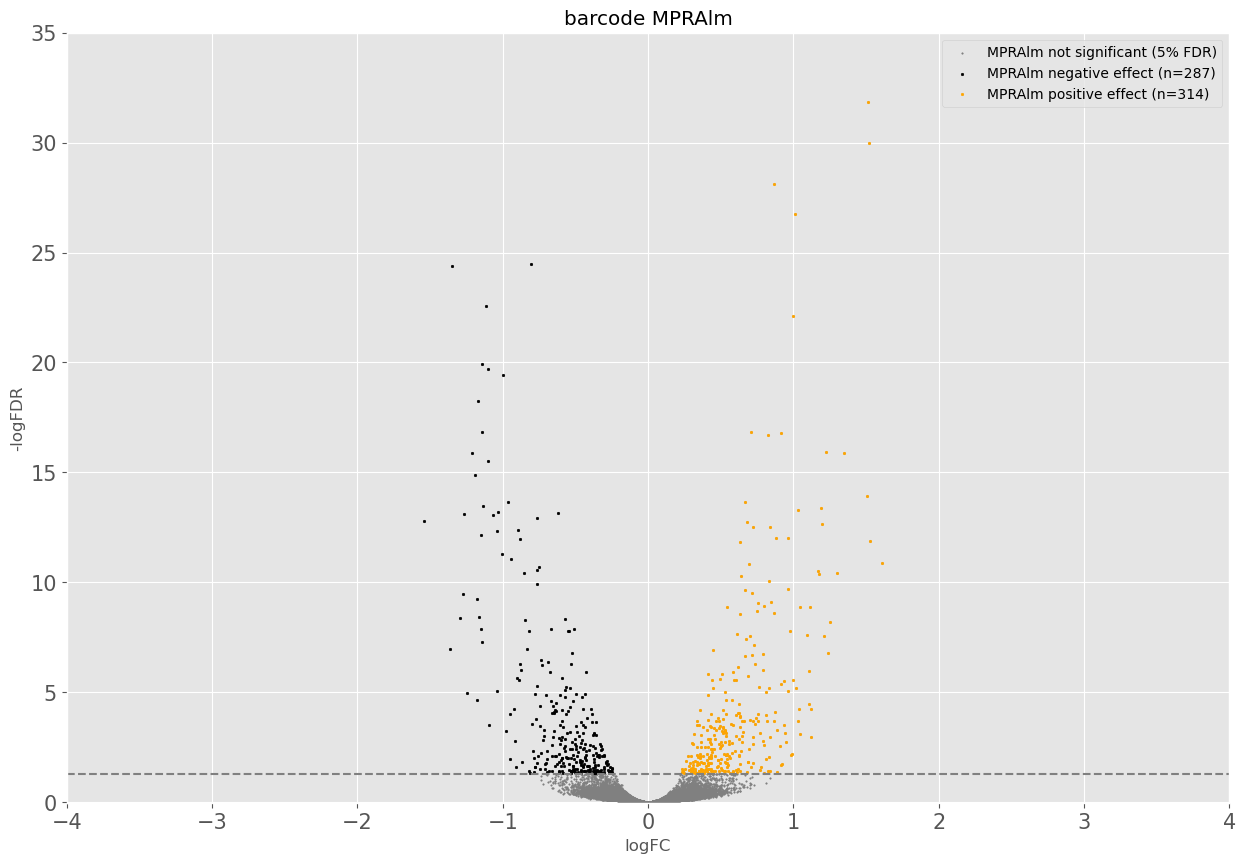

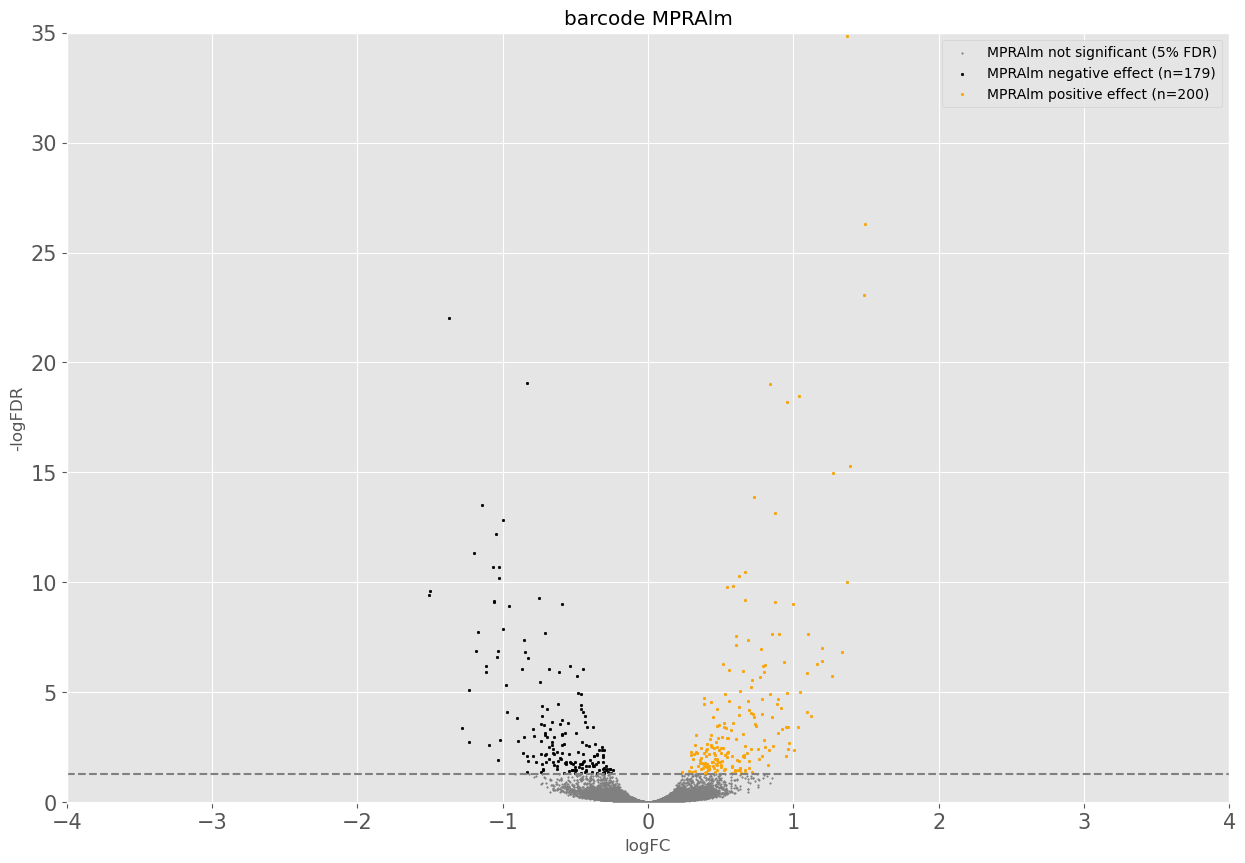

In [87]:
# plot_vulcano(bcMPRAlm_table_no_downsampling, title="barcode MPRAlm No downsampling")
plot_vulcano(bcMPRAlm_table, title="barcode MPRAlm")
# plot_vulcano(MPRAlm_table_no_downsampling, title="aggregated MPRAlm No downsampling")
plot_vulcano(MPRAlm_table, title="barcode MPRAlm")

### focus on cava genes

In [8]:
def get_gene_lookup_dict(gene_lists):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict

def get_gene_name_from_element(header):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if 'ALT_' in header:
        print(header)
        raise ValueError('This function is only for element sequences')

    if 'REF_' in header:
        return header.split(":REF_")[1].split('|')[0]

    return header.split(':')[1].split('|')[0]

In [9]:
# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = os.listdir(gene_list_dir)

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists)

In [10]:
bcMPRAlm_table['label'] = bcMPRAlm_table['variant_id'].apply(hf.get_label)
bcMPRAlm_table['is_positive'] = bcMPRAlm_table['logFC'] > 0
bcMPRAlm_table['is_negative'] = bcMPRAlm_table['logFC'] < 0
tested_bcMPRAlm_table = bcMPRAlm_table.loc[bcMPRAlm_table['label'] == "cardiac_neuro_cava_random"]

In [11]:
import re
def get_chrom_pos_ref_alt_pattern(header):
    """
    In the 80K MPRA design each variant has a chr-pos-ref-alt pattern in the header
    This function is able to match it and returns the result
    """
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"

tested_bcMPRAlm_table['chr_pos_ref_alt'] = tested_bcMPRAlm_table['ID'].apply(get_chrom_pos_ref_alt_pattern)

/tmp/ipykernel_201452/4182434128.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_table['chr_pos_ref_alt'] = tested_bcMPRAlm_table['ID'].apply(get_chrom_pos_ref_alt_pattern)


In [12]:
# # get gene name from variant id
tested_bcMPRAlm_table['gene_name'] = tested_bcMPRAlm_table['variant_id'].apply(get_gene_name_from_element)
# add gene_set annotation
tested_bcMPRAlm_table['gene_set'] = tested_bcMPRAlm_table['gene_name'].apply(lambda gene: gene_lookup_dict[gene])

/tmp/ipykernel_201452/2565674174.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_table['gene_name'] = tested_bcMPRAlm_table['variant_id'].apply(get_gene_name_from_element)
/tmp/ipykernel_201452/2565674174.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_table['gene_set'] = tested_bcMPRAlm_table['gene_name'].apply(lambda gene: gene_lookup_dict[gene])


#### Add the variant type
- singleton     54
- ultra-rare    43
- common        10
- rare           9

In [15]:
# tested_bcMPRAlm_table['gene_set'].value_counts()
# add gene info boolean columns
tested_bcMPRAlm_table['is_neuro'] = tested_bcMPRAlm_table['gene_set'].apply(lambda x: 'neuro' in x)
tested_bcMPRAlm_table['is_cardiac'] = tested_bcMPRAlm_table['gene_set'].apply(lambda x: 'cardiac' in x)
tested_bcMPRAlm_table['is_cava'] = tested_bcMPRAlm_table['gene_set'].apply(lambda x: 'cava' in x)
tested_bcMPRAlm_table['is_random'] = tested_bcMPRAlm_table['gene_set'].apply(lambda x: 'random' in x)


/tmp/ipykernel_201452/2266711493.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_table['is_neuro'] = tested_bcMPRAlm_table['gene_set'].apply(lambda x: 'neuro' in x)
/tmp/ipykernel_201452/2266711493.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_table['is_cardiac'] = tested_bcMPRAlm_table['gene_set'].apply(lambda x: 'cardiac' in x)
/tmp/ipykernel_201452/2266711493.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

/tmp/ipykernel_201452/433286506.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] > 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
/tmp/ipykernel_201452/433286506.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] < 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])


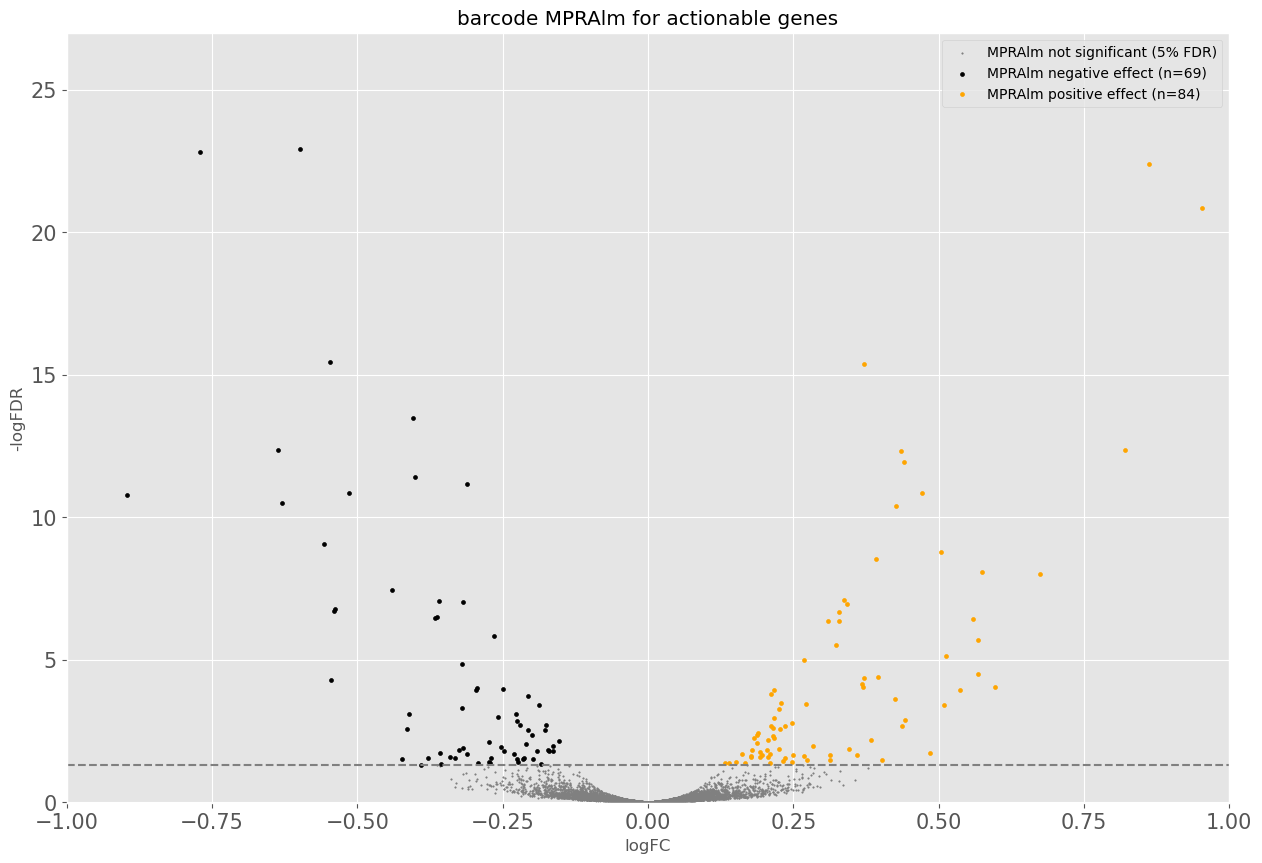

In [33]:
# vulcano plot for cava associated genes
plot_vulcano(tested_bcMPRAlm_table.loc[tested_bcMPRAlm_table['is_cava']], title="barcode MPRAlm for actionable genes", ylim_max=27, ylim_min=-0.025, xlim_min=-1, xlim_max=1, sig_dot_size=8)


In [92]:
# add variant information
merged_variant_file = '/data/cephfs-2/unmirrored/groups/kircher/users/kisa11_c/projects/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'
merged_variant_df = pd.read_csv(merged_variant_file, sep='\t')
merged_variant_df['chr_pos_ref_alt'] = merged_variant_df['ID'].apply(get_chrom_pos_ref_alt_pattern)
merged_variant_df

informative_columns = ['CHROM', 'POS', 'ID', 'REF', 'ALT', 'INFO',
       'gene_type', 'variant_type', 'chr_pos_ref_alt']

In [93]:
merged_variant_df.drop_duplicates(subset=['chr_pos_ref_alt'], inplace=True)

In [94]:
merged_variant_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,chr_pos_ref_alt
0,chr1,3030162,PRDM16|ENSG00000142611.17|EH38E1312284|1-30301...,T,A,1,PASS,AF=0.247769;AC=37649,cardiac,common,1-3030162-T-A
1,chr1,3030855,PRDM16|ENSG00000142611.17|EH38E2779521|1-30308...,G,A,1,PASS,AF=0.0757297;AC=11520,cardiac,common,1-3030855-G-A
2,chr1,3033425,PRDM16|ENSG00000142611.17|EH38E1312290|1-30334...,A,C,1,AS_VQSR,AF=0.0564555;AC=4921,cardiac,common,1-3033425-A-C
3,chr1,3033673,PRDM16|ENSG00000142611.17|EH38E2779527|1-30336...,G,A,1,PASS,AF=0.170986;AC=25994,cardiac,common,1-3033673-G-A
4,chr1,3033770,PRDM16|ENSG00000142611.17|EH38E2779527|1-30337...,G,A,1,PASS,AF=0.171221;AC=26042,cardiac,common,1-3033770-G-A
...,...,...,...,...,...,...,...,...,...,...,...
71405,chr6,26284345,H1-3|ENSG00000124575.7|EH38E3697740|6-26284345...,G,A,1,PASS,AF=6.57903e-06;AC=1,random,singleton,6-26284345-G-A
71406,chr2,210478202,CPS1|ENSG00000021826.18|EH38E3397495|2-2104782...,C,T,1,PASS,AF=6.5697e-06;AC=1,random,singleton,2-210478202-C-T
71407,chr2,210477975,CPS1|ENSG00000021826.18|EH38E3397495|2-2104779...,G,C,1,PASS,AF=6.57315e-06;AC=1,random,singleton,2-210477975-G-C
71408,chr2,210478142,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,T,A,1,PASS,AF=6.56858e-06;AC=1,random,singleton,2-210478142-T-A


In [96]:
# merge the dataframes
tested_bcMPRAlm_table_variant_info = tested_bcMPRAlm_table.merge(merged_variant_df[informative_columns], on='chr_pos_ref_alt', how='left')
tested_bcMPRAlm_table_variant_info # 37528 36414

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID_x,mpralm_true,label,...,gene_name,gene_set,CHROM,POS,ID_y,REF,ALT,INFO,gene_type,variant_type
0,1.490195,1.896905,19.466523,1.288060e-67,4.758221e-63,141.899179,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,cardiac_neuro_cava_random,...,TRIO,[neuro],chr5,14408059,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,A,G,AF=6.57117e-06;AC=1,neuro,singleton
1,1.514576,1.002377,13.939829,8.049105e-37,1.486710e-32,71.678281,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,cardiac_neuro_cava_random,...,TRIO,[neuro],chr5,14259916,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,C,T,AF=0.0168281;AC=2558,neuro,rare
2,1.518126,0.932093,13.543783,8.847412e-35,1.089441e-30,67.099942,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,cardiac_neuro_cava_random,...,ANKZF1,[random],chr2,219267001,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,T,C,AF=6.57566e-06;AC=1,random,singleton
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive,cardiac_neuro_cava_random,...,ATR,[cava],chr3,142578095,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,C,G,AF=4.60054e-05;AC=7,cava,ultra-rare
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive,cardiac_neuro_cava_random,...,CDH1,[cava],chr16,68784390,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,A,G,AF=6.57851e-06;AC=1,cava,singleton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36409,-0.000123,0.115534,-0.001769,9.985892e-01,9.999162e-01,-6.881197,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542425-A-G,neutral,cardiac_neuro_cava_random,...,FH,[cava],chr1,241542425,FH|ENSG00000091483.8|EH38E2877415|1-241542425-A-G,A,G,AF=0.00470341;AC=716,cava,ultra-rare
36410,-0.001286,0.205960,-0.019093,9.847711e-01,9.976613e-01,-6.881254,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358049|5-1415154...,neutral,cardiac_neuro_cava_random,...,TRIO,[neuro],chr5,14151545,TRIO|ENSG00000038382.23|EH38E2358049|5-1415154...,G,A,AF=0.070549;AC=10725,neuro,common
36411,0.000074,0.178124,0.001079,9.991395e-01,9.999303e-01,-6.881284,cardiac_neuro_cava_random:BRIP1|ENSG0000013649...,BRIP1|ENSG00000136492.10|EH38E1876459|17-61816...,neutral,cardiac_neuro_cava_random,...,BRIP1,[cava],chr17,61816619,BRIP1|ENSG00000136492.10|EH38E1876459|17-61816...,G,C,AF=6.57497e-06;AC=1,cava,singleton
36412,-0.000519,0.004146,-0.007229,9.942340e-01,9.993798e-01,-6.881296,cardiac_neuro_cava_random:DYRK1A|ENSG000001575...,DYRK1A|ENSG00000157540.22|EH38E2141038|21-3743...,neutral,cardiac_neuro_cava_random,...,DYRK1A,[neuro],chr21,37437798,DYRK1A|ENSG00000157540.22|EH38E2141038|21-3743...,A,G,AF=6.57004e-06;AC=1,neuro,singleton


In [109]:
tested_bcMPRAlm_table_variant_info['is_neuro'] = tested_bcMPRAlm_table_variant_info['gene_set'].apply(lambda x: 'neuro' in x)
tested_bcMPRAlm_table_variant_info['is_cardiac'] = tested_bcMPRAlm_table_variant_info['gene_set'].apply(lambda x: 'cardiac' in x)
tested_bcMPRAlm_table_variant_info['is_cava'] = tested_bcMPRAlm_table_variant_info['gene_set'].apply(lambda x: 'cava' in x)
tested_bcMPRAlm_table_variant_info['is_random'] = tested_bcMPRAlm_table_variant_info['gene_set'].apply(lambda x: 'random' in x)

tested_bcMPRAlm_table_variant_info['is_singleton'] = tested_bcMPRAlm_table_variant_info['variant_type'] == 'singleton'
tested_bcMPRAlm_table_variant_info['is_rare'] = tested_bcMPRAlm_table_variant_info['variant_type'] == 'rare'
tested_bcMPRAlm_table_variant_info['is_ultra-rare'] = tested_bcMPRAlm_table_variant_info['variant_type'] == 'ultra-rare'
tested_bcMPRAlm_table_variant_info['is_common'] = tested_bcMPRAlm_table_variant_info['variant_type'] == 'common'


cava_tested_bcMPRAlm_table = tested_bcMPRAlm_table_variant_info.loc[tested_bcMPRAlm_table_variant_info['is_cava']]
cava_tested_bcMPRAlm_table #6584 6584

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID_x,mpralm_true,label,...,gene_type,variant_type,is_neuro,is_cardiac,is_cava,is_random,is_singleton,is_rare,is_ultra-rare,is_common
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
6,-1.352079,0.893360,-12.055673,8.148715e-29,4.300310e-25,53.895821,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,negative,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
7,-1.118407,-0.188090,-11.288885,5.876629e-27,2.713607e-23,50.126383,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E3101219|14-6816...,negative,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False
14,-1.144693,-0.700292,-9.851376,5.472127e-21,1.443899e-17,36.721792,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,IRF4|ENSG00000137265.16|EH38E2438393|6-396321-C-T,negative,cardiac_neuro_cava_random,...,cava,common,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36395,-0.001380,0.164592,-0.019061,9.847965e-01,9.976613e-01,-6.880953,cardiac_neuro_cava_random:NBN|ENSG00000104320....,NBN|ENSG00000104320.15|EH38E2646226|8-89894581...,neutral,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False
36402,-0.000497,0.250528,-0.007089,9.943457e-01,9.993798e-01,-6.881047,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E1723089|14-6793...,neutral,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
36403,-0.000090,0.177319,-0.001304,9.989599e-01,9.999162e-01,-6.881063,cardiac_neuro_cava_random:BRIP1|ENSG0000013649...,BRIP1|ENSG00000136492.10|EH38E1876459|17-61816...,neutral,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
36409,-0.000123,0.115534,-0.001769,9.985892e-01,9.999162e-01,-6.881197,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542425-A-G,neutral,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False


In [112]:
cava_tested_bcMPRAlm_table.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'ID_x', 'mpralm_true', 'label', 'is_positive', 'is_negative',
       'chr_pos_ref_alt', 'gene_name', 'gene_set', 'CHROM', 'POS', 'ID_y',
       'REF', 'ALT', 'INFO', 'gene_type', 'variant_type', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random', 'is_singleton', 'is_rare',
       'is_ultra-rare', 'is_common'],
      dtype='object')

In [110]:
cava_tested_bcMPRAlm_table_significant['variant_type'].value_counts()

singleton     54
ultra-rare    43
common        10
rare           9
Name: variant_type, dtype: int64

common        70.500000
rare          55.888889
singleton     50.185185
ultra-rare    62.000000
dtype: float64

#### Number of significants within cava
- Number: 116 
- positive: 60 
- negative effects: 56


In [113]:
cava_tested_bcMPRAlm_table_significant = cava_tested_bcMPRAlm_table.loc[cava_tested_bcMPRAlm_table['adj.P.Val'] < 0.05]
cava_tested_bcMPRAlm_table_significant

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID_x,mpralm_true,label,...,gene_type,variant_type,is_neuro,is_cardiac,is_cava,is_random,is_singleton,is_rare,is_ultra-rare,is_common
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
6,-1.352079,0.893360,-12.055673,8.148715e-29,4.300310e-25,53.895821,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,negative,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
7,-1.118407,-0.188090,-11.288885,5.876629e-27,2.713607e-23,50.126383,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E3101219|14-6816...,negative,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False
14,-1.144693,-0.700292,-9.851376,5.472127e-21,1.443899e-17,36.721792,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,IRF4|ENSG00000137265.16|EH38E2438393|6-396321-C-T,negative,cardiac_neuro_cava_random,...,cava,common,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,0.353276,0.030845,3.471709,5.653807e-04,3.860578e-02,-0.667983,cardiac_neuro_cava_random:FANCM|ENSG0000018779...,FANCM|ENSG00000187790.12|EH38E3092948|14-45222...,positive,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
559,-0.403942,0.044640,-3.432066,6.596642e-04,4.245410e-02,-0.713581,cardiac_neuro_cava_random:ATM|ENSG00000149311....,ATM|ENSG00000149311.20|EH38E2982987|11-1082368...,negative,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False
573,0.326116,0.204868,3.449919,6.053027e-04,4.007256e-02,-0.789012,cardiac_neuro_cava_random:PALB2|ENSG0000008309...,PALB2|ENSG00000083093.11|EH38E1807963|16-23677...,positive,cardiac_neuro_cava_random,...,cava,singleton,False,False,True,False,True,False,False,False
625,0.324065,-0.518720,3.391425,7.373370e-04,4.624442e-02,-1.042206,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E1723766|14-6855...,positive,cardiac_neuro_cava_random,...,cava,ultra-rare,False,False,True,False,False,False,True,False


In [99]:
poitive_cava_tested_bcMPRAlm_table_significant = cava_tested_bcMPRAlm_table_significant.loc[cava_tested_bcMPRAlm_table_significant['is_positive']]
negative_cava_tested_bcMPRAlm_table_significant = cava_tested_bcMPRAlm_table_significant.loc[cava_tested_bcMPRAlm_table_significant['is_negative']]
n_cava_positive = poitive_cava_tested_bcMPRAlm_table_significant.shape[0]
n_cava_negative = negative_cava_tested_bcMPRAlm_table_significant.shape[0]


In [100]:
n_cava_positive

60

In [101]:
n_cava_negative

56

(array([8., 8., 5., 6., 2., 6., 2., 4., 7., 2., 4., 2., 1., 0., 0., 1., 1.,
        0., 0., 1.]),
 array([0.28094331, 0.34725247, 0.41356162, 0.47987077, 0.54617992,
        0.61248908, 0.67879823, 0.74510738, 0.81141653, 0.87772568,
        0.94403484, 1.01034399, 1.07665314, 1.14296229, 1.20927144,
        1.2755806 , 1.34188975, 1.4081989 , 1.47450805, 1.54081721,
        1.60712636]),
 <BarContainer object of 20 artists>)

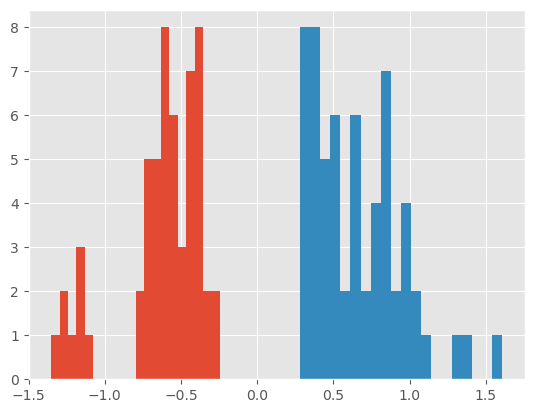

In [102]:
# check logFC distribution
plt.hist(negative_cava_tested_bcMPRAlm_table_significant['logFC'], bins=20)
plt.hist(poitive_cava_tested_bcMPRAlm_table_significant['logFC'], bins=20)

In [114]:
# make table of ratios of the variant types considering the set size of the variant type within the cava set
tested_bcMPRAlm_table_variant_info.loc[tested_bcMPRAlm_table_variant_info['is_cava']].groupby('variant_type').size() / cava_tested_bcMPRAlm_table_significant['variant_type'].value_counts()

common        70.500000
rare          55.888889
singleton     50.185185
ultra-rare    62.000000
dtype: float64

In [115]:
tested_bcMPRAlm_table_variant_info['is_common'].sum() # 9446
cava_tested_bcMPRAlm_table_significant['is_common'].sum() # 10 => 10 / 9446

10

In [116]:
10 / 9446

0.0010586491636671606

#### Check the mpralm results

In [10]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true
0,1.490195,1.896905,19.466523,1.288060e-67,4.758221e-63,141.899179,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive
1,1.514576,1.002377,13.939829,8.049105e-37,1.486710e-32,71.678281,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive
2,1.518126,0.932093,13.543783,8.847412e-35,1.089441e-30,67.099942,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive
...,...,...,...,...,...,...,...,...,...
36936,-0.000123,0.115534,-0.001769,9.985892e-01,9.999162e-01,-6.881197,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542425-A-G,neutral
36937,-0.001286,0.205960,-0.019093,9.847711e-01,9.976613e-01,-6.881254,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358049|5-1415154...,neutral
36938,0.000074,0.178124,0.001079,9.991395e-01,9.999303e-01,-6.881284,cardiac_neuro_cava_random:BRIP1|ENSG0000013649...,BRIP1|ENSG00000136492.10|EH38E1876459|17-61816...,neutral
36939,-0.000519,0.004146,-0.007229,9.942340e-01,9.993798e-01,-6.881296,cardiac_neuro_cava_random:DYRK1A|ENSG000001575...,DYRK1A|ENSG00000157540.22|EH38E2141038|21-3743...,neutral


In [11]:
MPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,mpralm_true
0,1.370678,1.860194,17.560799,4.101053e-40,1.436968e-35,79.906151,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,positive
1,1.490805,0.707015,14.392835,2.823725e-31,4.947024e-27,59.462699,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,positive
2,1.486767,0.997721,13.200114,7.044947e-28,8.228263e-24,51.766157,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,positive
3,-1.371246,0.665880,-12.782335,1.097852e-26,9.616906e-23,49.305826,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,negative
4,-0.831415,0.761397,-11.708742,1.259688e-23,8.827640e-20,43.029602,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,negative
...,...,...,...,...,...,...,...,...
35034,-0.006053,0.047492,-0.097930,9.221028e-01,9.883900e-01,-7.003960,cardiac_neuro_cava_random:TRAK1|ENSG0000018260...,neutral
35035,-0.012198,0.407752,-0.198848,8.426180e-01,9.771244e-01,-7.004137,cardiac_neuro_cava_random:SOS1|ENSG00000115904...,neutral
35036,0.000315,0.174039,0.005085,9.959485e-01,9.992342e-01,-7.008937,cardiac_neuro_cava_random:VCL|ENSG00000035403....,neutral
35037,-0.006273,0.105392,-0.102904,9.181599e-01,9.879948e-01,-7.021133,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,neutral


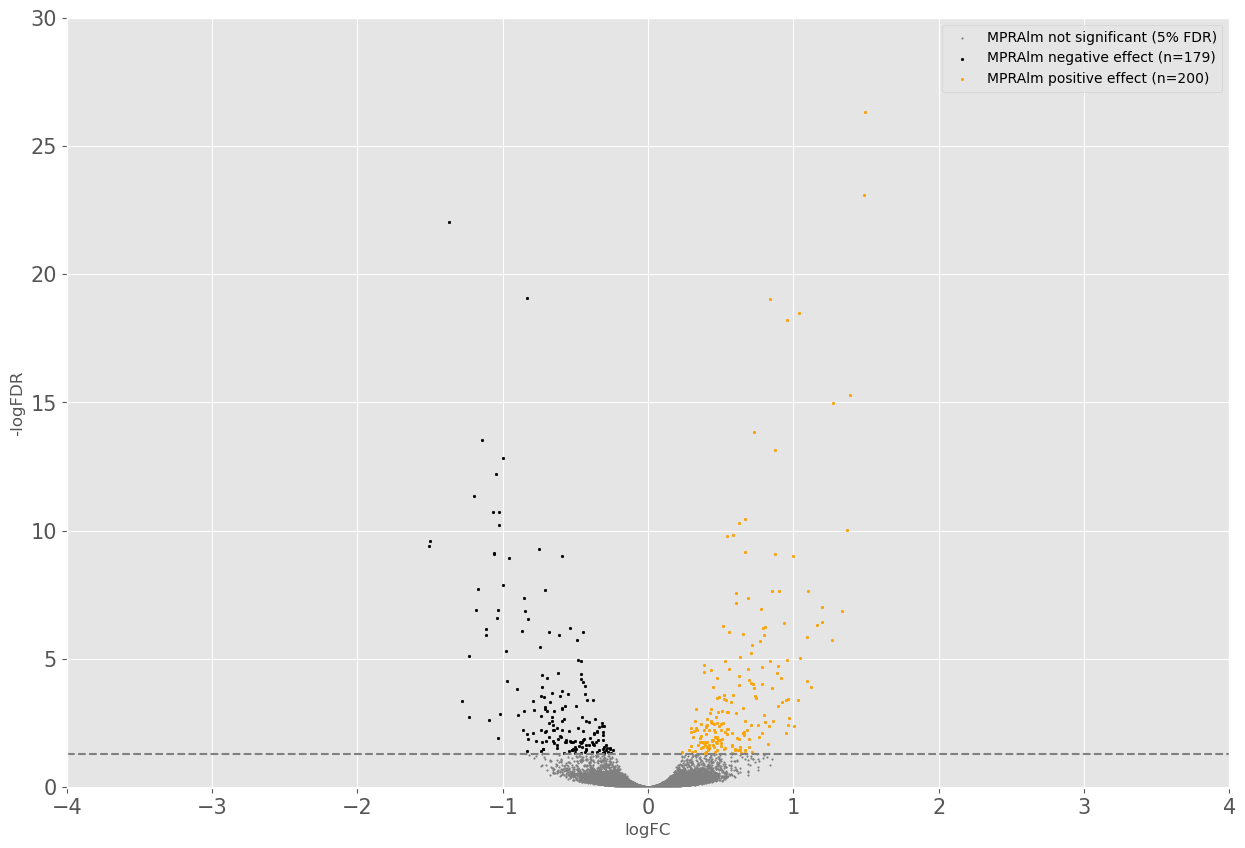

In [12]:
significants_niveau = 0.05
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] > 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] < 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

significant_MPRAlm_table = MPRAlm_table[MPRAlm_table['adj.P.Val'] < significants_niveau]
up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
ax = plt.gca()
plt.style.use("ggplot")
plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
ax.set_xlim([-4,4])
ax.set_ylim([-0.025,30])
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('mpralm_41k_results.png', transparent=True)

#### Loading functions for analysing the (bc) mpralm results

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# create new column with negative log10 p-value
bcMPRAlm_table["nlog10"] = -np.log10(bcMPRAlm_table["adj.P.Val"])
MPRAlm_table["nlog10"] = -np.log10(MPRAlm_table["adj.P.Val"])

In [14]:
def get_label(header):
    return header.split(":")[0]

def is_tested(header):
    return get_label(header) == 'cardiac_neuro_cava_random'

def is_control(header):
    return not is_tested(header)

def map_color_to_controls(row):
    if is_tested(row):
        return '#377eb8'
    else: return '#ff7f00'

def is_common(variant_type):
    return variant_type in ['common', 'rare']

def is_only_common(variant_type):
    return variant_type in ['common']

def is_rare(variant_type):
    return variant_type in ['rare']

def is_ultra_rare(variant_type):
    return variant_type in ['ultra-rare']

def is_singleton(variant_type):
    return variant_type in ['singleton']

# add class to plot for colors
def map_color_precise(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        if abs(log2fc) >= log2fc_threshold:
            return "interesting_high_log2fc"
        else:
            return "interesting_low_pvalue"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        if abs(log2fc) < log2fc_threshold:
            return "uninteresting_low_log2fc"
        else:
            return "uninteresting_high_pvalue"
    return "possibly_interesting"

def map_color(a):
    log2fc, variant_id, nlog10 = a
    log2fc_threshold = 1
    nlog10pvalue_threshold = 2
    if abs(log2fc) >= log2fc_threshold or nlog10 >= nlog10pvalue_threshold:
        return "interesting"
    elif abs(log2fc) < log2fc_threshold or nlog10 < nlog10pvalue_threshold:
        return "uninteresting"
    return "possibly_interesting"


def is_positive_control(header):
    """Checks if header is positive control"""
    label = get_label(header)
    if label in positive_control_groups:
        return True
    return False


def is_negative_control(header):
    """Checks if header is negative control"""
    label = get_label(header)
    if label in negative_control_groups:
        return True
    return False

def is_liang_control(header):
    """Checks if header is from Liang control  (08.04: 7 variants)"""
    label = get_label(header)
    if label.lower() == 'GC_Liang'.lower():
        return True
    return False

def is_selvarajan_control(header):
    """Checks if header is from GC_Selvarajan control (08.04: 112 variants)"""
    label = get_label(header)
    if label.lower() == 'GC_Selvarajan'.lower():
        return True
    return False

def is_positive_heart_CAD_control(header):
    """Checks if header is from positive_heart_CAD control (08.04: 43 variants)"""
    label = get_label(header)
    if label.lower() == 'C_positive_heart_CAD'.lower():
        return True
    return False

def is_arial_fib_control(header):
    """Checks if header is from GC_Atrial_fib (08.04: 17 variants) control"""
    label = get_label(header)
    if label.lower() == 'GC_Atrial_fib'.lower():
        return True
    return False

def is_mohlke_control(header):
    """Checks if header is from GC_Mohlke control (08.04: 11 variants)"""
    label = get_label(header)
    if label.lower() == 'GC_Mohlke'.lower():
        return True
    return False

def is_kircher_control(header):
    label = get_label(header)
    if label.lower() == 'GC_Kircher'.lower():
        return True
    return False

def is_mendelian_control(header):
    label = get_label(header)
    if label.lower() == 'GC_Mendelian_variants'.lower():
        return True
    return False

### Correlation between aggregated and bc mpralm results
- use r heatscatter 

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

/tmp/ipykernel_673798/2836392936.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lims, lims, 'k-', color=color, alpha=0.75, zorder=0)


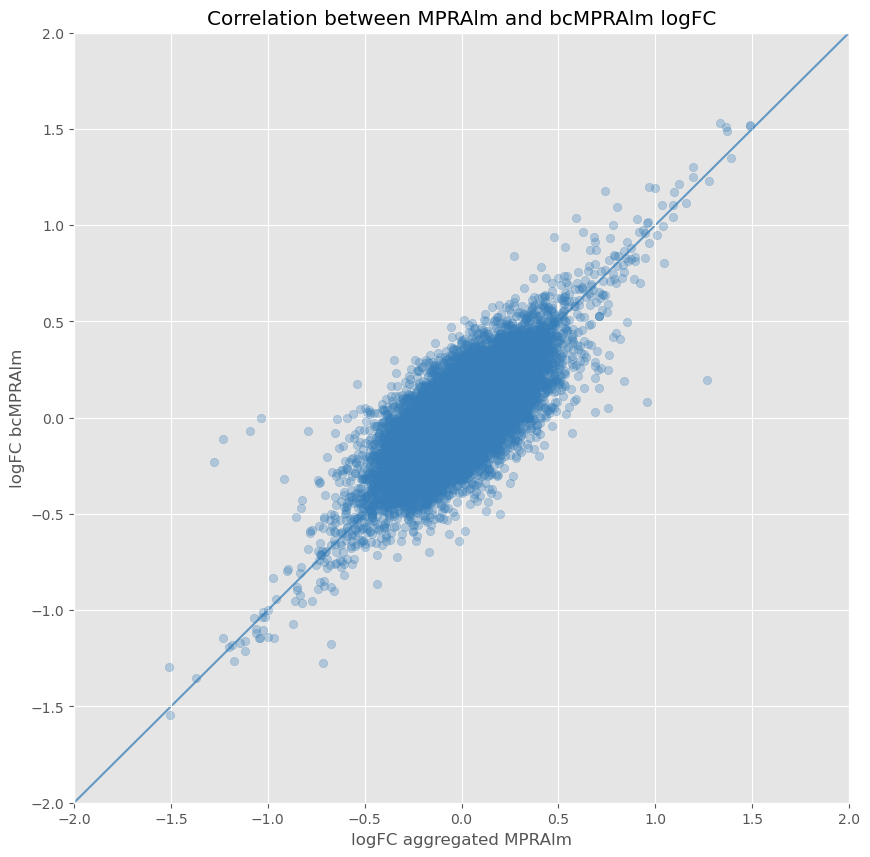

In [17]:
# plot correlation between MPRAlm_table [logFC] and bcMPRAlm_table [logFC]

# merge the two tables
merged_mpralm = pd.merge(MPRAlm_table, bcMPRAlm_table, on="variant_id", suffixes=('_MPRAlm', '_bcMPRAlm'))

# plot log2 correlation between mpralm and bcMPRAlm

fig, ax = plt.subplots(figsize=(10, 10))
# set xlim and ylim
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# set axis names
plt.xlabel("logFC aggregated MPRAlm")
plt.ylabel("logFC bcMPRAlm")
plt.title("Correlation between MPRAlm and bcMPRAlm logFC")

# set color to light blue
color = "#377eb8"

# plot scatter plot
ax.scatter(merged_mpralm["logFC_MPRAlm"], merged_mpralm["logFC_bcMPRAlm"], color=color, alpha=0.3)

# add diagonal line behind the scatter plot
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# plot the diagonal line
ax.plot(lims, lims, 'k-', color=color, alpha=0.75, zorder=0)

# plt.show()
# fig.savefig('../../../80K_analysis/07_quality_control/results/plots/correlation_logFC_MPRAlm_bcMPRAlm.svg', format='svg', dpi=1200)

# plt.savefig('../../../80K_analysis/07_quality_control/results/plots/correlation_logFC_MPRAlm_bcMPRAlm.eps', format='eps')



In [18]:
merged_mpralm.head()

,logFC_MPRAlm,AveExpr_MPRAlm,t_MPRAlm,P.Value_MPRAlm,adj.P.Val_MPRAlm,B_MPRAlm,variant_id,mpralm_true_MPRAlm,nlog10_MPRAlm,logFC_bcMPRAlm,AveExpr_bcMPRAlm,t_bcMPRAlm,P.Value_bcMPRAlm,adj.P.Val_bcMPRAlm,B_bcMPRAlm,ID,mpralm_true_bcMPRAlm,nlog10_bcMPRAlm
0,1.370678,1.860194,17.560799,4.101053e-40,1.436968e-35,79.906151,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,positive,34.842553,1.490195,1.896905,19.466523,1.288060e-67,4.758221e-63,141.899179,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,62.322555
1,1.490805,0.707015,14.392835,2.823725e-31,4.947024e-27,59.462699,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,positive,26.305656,1.514576,1.002377,13.939829,8.049105e-37,1.486710e-32,71.678281,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,31.827774
2,1.486767,0.997721,13.200114,7.044947e-28,8.228263e-24,51.766157,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,positive,23.084692,1.518126,0.932093,13.543783,8.847412e-35,1.089441e-30,67.099942,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,29.962796
3,-1.371246,0.665880,-12.782335,1.097852e-26,9.616906e-23,49.305826,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,negative,22.016965,-1.352079,0.893360,-12.055673,8.148715e-29,4.300310e-25,53.895821,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,negative,24.366500
4,-0.831415,0.761397,-11.708742,1.259688e-23,8.827640e-20,43.029602,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,negative,19.054155,-0.807255,0.766742,-11.619590,5.520148e-29,3.398663e-25,54.928338,TRIO|ENSG00000038382.23|EH38E2358394|5-1440808...,negative,24.468692


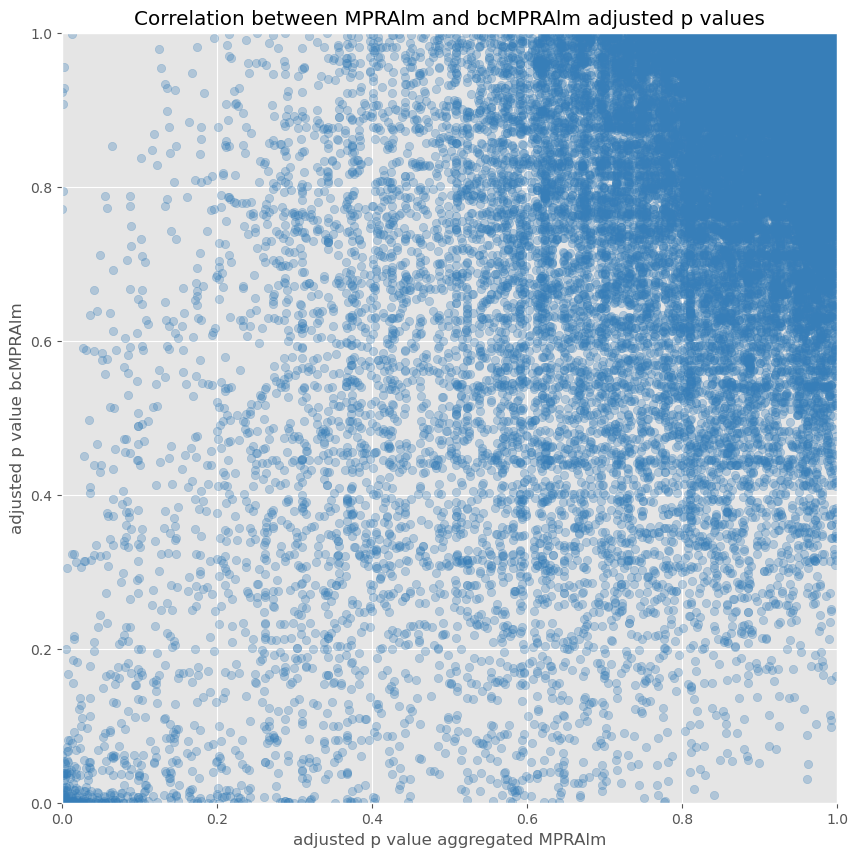

In [19]:
# plot p value correlation

fig, ax = plt.subplots(figsize=(10, 10))
# set xlim and ylim
ax.set_xlim(-0, 1)
ax.set_ylim(-0, 1)

# set axis names
plt.xlabel("adjusted p value aggregated MPRAlm")
plt.ylabel("adjusted p value bcMPRAlm")
plt.title("Correlation between MPRAlm and bcMPRAlm adjusted p values")

# set color to light blue
color = "#377eb8"

# plot scatter plot
ax.scatter(merged_mpralm["adj.P.Val_MPRAlm"], merged_mpralm["adj.P.Val_bcMPRAlm"], color=color, alpha=0.3)

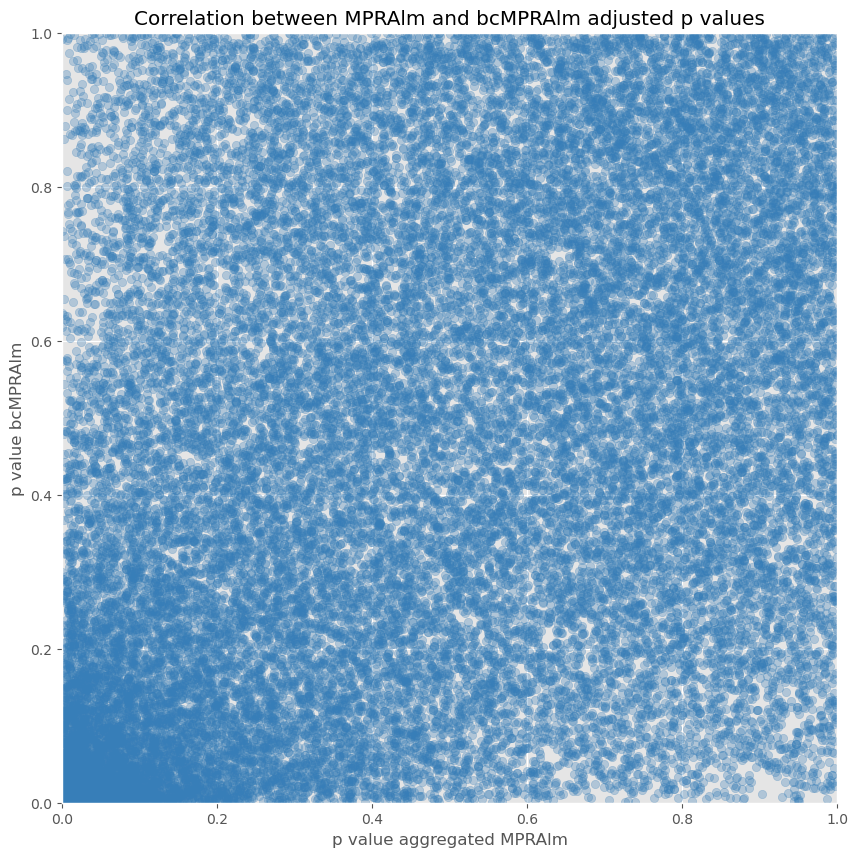

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))
# set xlim and ylim
ax.set_xlim(-0, 1)
ax.set_ylim(-0, 1)

# set axis names
plt.xlabel("p value aggregated MPRAlm")
plt.ylabel("p value bcMPRAlm")
plt.title("Correlation between MPRAlm and bcMPRAlm adjusted p values")

# set color to light blue
color = "#377eb8"

# plot scatter plot
ax.scatter(merged_mpralm["P.Value_MPRAlm"], merged_mpralm["P.Value_bcMPRAlm"], color=color, alpha=0.3)

### Investigate aggregated mpralm 
 

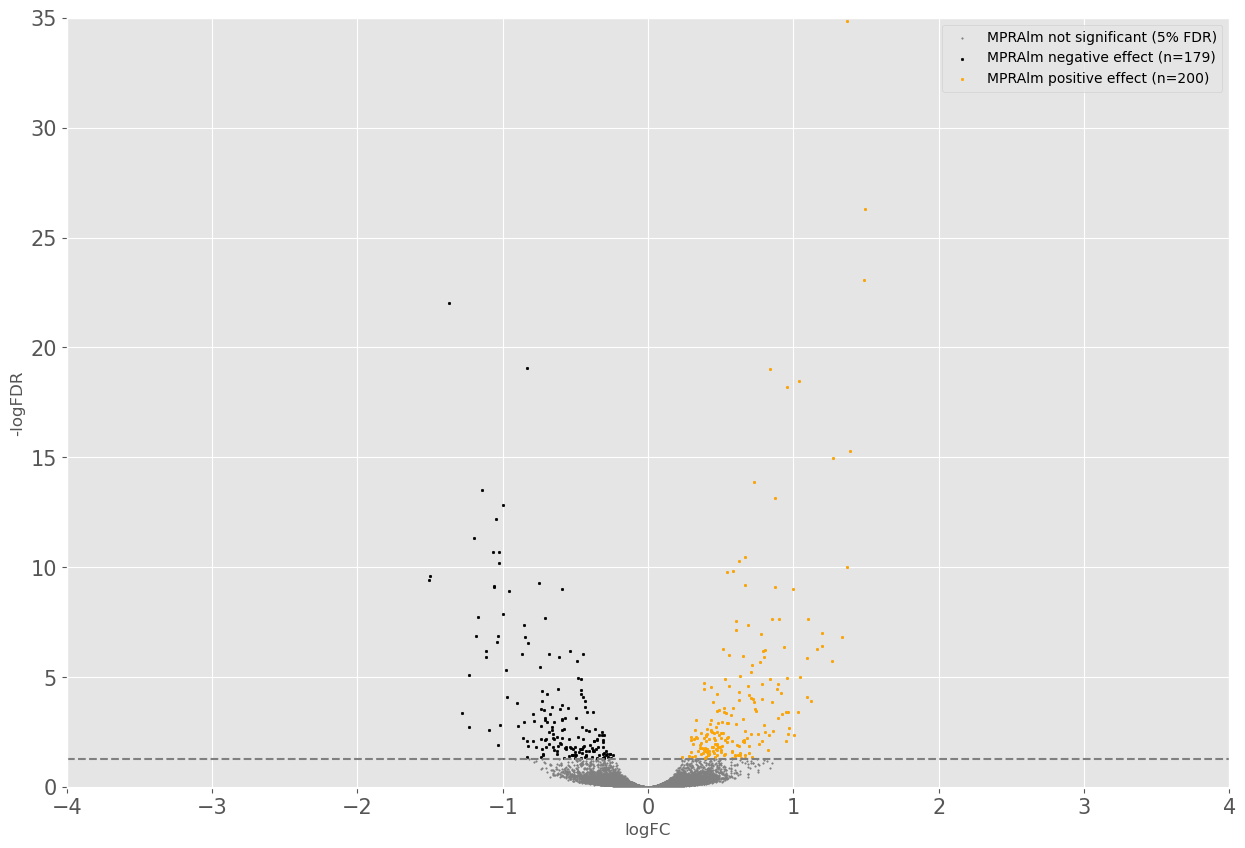

In [21]:
significants_niveau = 0.05
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] > 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table['logFC'] < 0) & (MPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

significant_MPRAlm_table = MPRAlm_table[MPRAlm_table['adj.P.Val'] < significants_niveau]
mpralm_up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
mpralm_down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=mpralm_down['logFC'],y=mpralm_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm negative effect" + " (n=" + str(mpralm_down.shape[0]) + ")",color="black")
plt.scatter(x=mpralm_up['logFC'],y=mpralm_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="MPRAlm positive effect"+ " (n=" + str(mpralm_up.shape[0]) + ")",color="orange")


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
ax = plt.gca()
ax.set_xlim([-4,4])
ax.set_ylim([-0.025,35])
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('mpralm_34K_results.png', transparent=True)


In [22]:
# TODO: fix it, error no ID
# merged_variant_file = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'
# merged_variant_df = pd.read_csv(merged_variant_file, sep='\t')
# merged_variant_df

# # merge with variant information:
# mpralm_merged_variant_table = MPRAlm_table.merge(merged_variant_df, on='ID')

# mpralm_controls = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_control)]
# mpralm_c_liang = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_liang_control)]
# mpralm_c_selvarajan = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_selvarajan_control)]
# mpralm_c_positive_heart_CAD = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_positive_heart_CAD_control)]
# mpralm_c_arial_fib = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_arial_fib_control)]
# mpralm_c_mohlke = MPRAlm_table[MPRAlm_table['variant_id'].apply(is_mohlke_control)]


# # significant_variant_table = significant_bcMPRAlm_table.merge(merged_variant_df, on='ID')
# mpralm_significant_variant_table = mpralm_merged_variant_table[mpralm_merged_variant_table['adj.P.Val'] < significants_niveau]
# mpralm_significant_variant_table[~mpralm_significant_variant_table['gene_type'].isna()].shape[0]
# mpralm_significant_variant_table['abs_logFC'] = mpralm_significant_variant_table['logFC'].abs()

# merged_up = mpralm_merged_variant_table[mpralm_merged_variant_table['mpralm_true'] == 'positive']
# merged_down = mpralm_merged_variant_table[mpralm_merged_variant_table['mpralm_true'] == 'negative']

# common_sig_up = merged_up[merged_up['variant_type'].apply(is_common)]
# ultra_rare_sig_up = merged_up[merged_up['variant_type'] == 'ultra-rare']
# singleton_sig_up = merged_up[merged_up['variant_type'] == 'singleton']
# common_sig_down = merged_down[merged_down['variant_type'].apply(is_common)]
# ultra_rare_sig_down = merged_down[merged_down['variant_type'] == 'ultra-rare']
# singleton_sig_down = merged_down[merged_down['variant_type'] == 'singleton']



In [23]:
# # get size of the variant_type groups:
# variant_type_tables = [common_sig_up, ultra_rare_sig_up, singleton_sig_up, common_sig_down, ultra_rare_sig_down, singleton_sig_down]
# variant_type_table_names = ["common_sig_up", "ultra_rare_sig_up", "singleton_sig_up", "common_sig_down", "ultra_rare_sig_down", "singleton_sig_down"]
# for i in range(len(variant_type_tables)):
#     print(variant_type_table_names[i], variant_type_tables[i].shape[0])

# for data with all variant controls (16.04.2024)
# common_sig_up 16
# ultra_rare_sig_up 20
# singleton_sig_up 22
# common_sig_down 14
# ultra_rare_sig_down 15
# singleton_sig_down 18

##### compare controls

In [24]:
# # make vulcano plot with coloring only controls special
# plt.figure(figsize=(15,10))
# # make background dark for the plot
# # plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
# plt.style.use("ggplot")

# plt.scatter(x=mpralm_merged_variant_table['logFC'],y=mpralm_merged_variant_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode_MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color='white')
# plt.scatter(x=mpralm_significant_variant_table['logFC'],y=mpralm_significant_variant_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"Significant effect variants ({mpralm_significant_variant_table.shape[0]})", color='black')
# # scatter for controls
# control_dot_size = 10
# # plt.scatter(x=mpralm_controls['logFC'],y=mpralm_controls['adj.P.Val'].apply(lambda x:-np.log10(x)),s=2,label="Controls", color='blue')
# # plt.scatter(x=mpralm_c_liang['logFC'],y=mpralm_c_liang['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Liang", color='orange')
# # plt.scatter(x=mpralm_c_selvarajan['logFC'],y=mpralm_c_selvarajan['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Selvarajan", color='orange')
# # plt.scatter(x=mpralm_c_positive_heart_CAD['logFC'],y=mpralm_c_positive_heart_CAD['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_positive_heart_CAD", color='red')
# # plt.scatter(x=mpralm_c_arial_fib['logFC'],y=mpralm_c_arial_fib['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_Arial_fib", color='blue')
# plt.scatter(x=mpralm_c_mohlke['logFC'],y=mpralm_c_mohlke['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"C_Mohlke ({mpralm_c_mohlke.shape[0]})", color='green')

# # modify plot
# ax = plt.gca()
# ax.set_xlim([-4,4])
# ax.set_ylim([-0.025,4])

# # increase font size
# plt.rcParams.update({'font.size': 15})
# # increase font size of labels and ticks
# plt.tick_params(axis='both', which='major', labelsize=15)
# # plt.style.use('dark_background')
# # plt.style.use("Solarize_Light2")
# plt.style.use("ggplot")
# # plt.title("GC_Liang control distribution compared to tested sequences in aggregated MPRAlm")
# plt.title("C_Mohlke control distribution compared to tested sequences in aggregated MPRAlm")
# # plt.title("Variant control distribution compared to tested sequences")
# plt.xlabel("log2FC")
# plt.ylabel("-logFDR")
# plt.axhline(1.3,color="grey",linestyle="--")
# plt.legend()

# plt.show()


##### Investigate different types of variants (unfinished)

In [25]:
# # plot of different types of variants:
# plt.figure(figsize=(15,10))
# # make background dark for the plot
# # plt.style.use('dark_background')
# # plt.style.use("Solarize_Light2")
# plt.style.use("ggplot")
# plt.scatter(x=MPRAlm_table['logFC'],y=MPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
# plt.scatter(x=common_sig_up['logFC'],y=common_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common up (AF>1%): {common_sig_up.shape[0]}",color="limegreen")
# plt.scatter(x=ultra_rare_sig_up['logFC'],y=ultra_rare_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare up (AF<=1%): {ultra_rare_sig_up.shape[0]}",color="violet")
# plt.scatter(x=singleton_sig_up['logFC'],y=singleton_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton up: {singleton_sig_up.shape[0]}",color="deepskyblue")
# plt.scatter(x=common_sig_down['logFC'],y=common_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common down (AF>1%): {common_sig_down.shape[0]}",color="darkgreen")
# plt.scatter(x=ultra_rare_sig_down['logFC'],y=ultra_rare_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare down (AF<=1%): {ultra_rare_sig_down.shape[0]}",color="purple")
# plt.scatter(x=singleton_sig_down['logFC'],y=singleton_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton down: {singleton_sig_down.shape[0]}",color="red")
# # scatter for controls
# # plt.scatter()


# # Keep x-axis between -4, 4
# # keep y-axis between 0, 4
# ax = plt.gca()
# ax.set_xlim([-4,4])
# ax.set_ylim([-0.025,4])
# # increase font size
# plt.rcParams.update({'font.size': 15})
# # increase font size of labels and ticks
# plt.tick_params(axis='both', which='major', labelsize=15)
# # plt.style.use('dark_background')
# # plt.style.use("Solarize_Light2")
# plt.style.use("ggplot")
# plt.xlabel("logFC")
# plt.ylabel("-logFDR")
# plt.axhline(1.3,color="grey",linestyle="--")
# plt.legend()

# plt.savefig('bc_mpralm_41k_results.png', transparent=True)

In [26]:
# log2fc_bcMPRAlm = bcMPRAlm_table[['variant_id', 'adj.P.Val', 'logFC']]

In [27]:
# # correlation between log2fc values of barcode mpralm and aggregated mpralm

# # merge log2fc of barcode mpralm to the mpralm
# MPRAlm_table.merge(log2fc_bcMPRAlm, on='variant_id', how='left')

In [28]:
bcMPRAlm_table[bcMPRAlm_table['adj.P.Val'] < 0.05] # 386 with 10 barcodes; 393 with 10 barcodes with downsampling; final resequencing 601 with 10 barcodes
# MPRAlm_table[MPRAlm_table['adj.P.Val'] < 0.05] # 105 with 10 barcodes; 379  with 10 barcodes with downsampling

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10
0,1.490195,1.896905,19.466523,1.288060e-67,4.758221e-63,141.899179,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,62.322555
1,1.514576,1.002377,13.939829,8.049105e-37,1.486710e-32,71.678281,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,31.827774
2,1.518126,0.932093,13.543783,8.847412e-35,1.089441e-30,67.099942,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,29.962796
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive,28.134743
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive,26.768962
...,...,...,...,...,...,...,...,...,...,...
630,0.324065,-0.518720,3.391425,7.373370e-04,4.624442e-02,-1.042206,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E1723766|14-6855...,positive,1.334941
633,-0.319259,-0.856299,-3.399299,7.158506e-04,4.497319e-02,-1.055239,cardiac_neuro_cava_random:SOS1|ENSG00000115904...,SOS1|ENSG00000115904.15|EH38E3337959|2-3908399...,negative,1.347046
639,0.233415,0.125755,3.427937,6.368129e-04,4.133949e-02,-1.087352,cardiac_neuro_cava_random:SLC22A5|ENSG00000197...,SLC22A5|ENSG00000197375.14|EH38E2408422|5-1323...,positive,1.383635
658,-0.244528,-0.087442,-3.403627,6.947132e-04,4.417108e-02,-1.179647,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E1723158|14-6802...,negative,1.354862


In [29]:
# add label to bcMPRAlm_table
bcMPRAlm_table['label'] = bcMPRAlm_table['variant_id'].apply(get_label)
MPRAlm_table['label'] = MPRAlm_table['variant_id'].apply(get_label)

In [30]:
merged_variant_file = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv'
merged_variant_df = pd.read_csv(merged_variant_file, sep='\t')
merged_variant_df
# significant_variant_table = significant_bcMPRAlm_table.merge(merged_variant_df, on='ID', how='left')

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type
0,chr1,3030162,PRDM16|ENSG00000142611.17|EH38E1312284|1-30301...,T,A,1,PASS,AF=0.247769;AC=37649,cardiac,common
1,chr1,3030855,PRDM16|ENSG00000142611.17|EH38E2779521|1-30308...,G,A,1,PASS,AF=0.0757297;AC=11520,cardiac,common
2,chr1,3033425,PRDM16|ENSG00000142611.17|EH38E1312290|1-30334...,A,C,1,AS_VQSR,AF=0.0564555;AC=4921,cardiac,common
3,chr1,3033673,PRDM16|ENSG00000142611.17|EH38E2779527|1-30336...,G,A,1,PASS,AF=0.170986;AC=25994,cardiac,common
4,chr1,3033770,PRDM16|ENSG00000142611.17|EH38E2779527|1-30337...,G,A,1,PASS,AF=0.171221;AC=26042,cardiac,common
...,...,...,...,...,...,...,...,...,...,...
71405,chr6,26284345,H1-3|ENSG00000124575.7|EH38E3697740|6-26284345...,G,A,1,PASS,AF=6.57903e-06;AC=1,random,singleton
71406,chr2,210478202,CPS1|ENSG00000021826.18|EH38E3397495|2-2104782...,C,T,1,PASS,AF=6.5697e-06;AC=1,random,singleton
71407,chr2,210477975,CPS1|ENSG00000021826.18|EH38E3397495|2-2104779...,G,C,1,PASS,AF=6.57315e-06;AC=1,random,singleton
71408,chr2,210478142,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,T,A,1,PASS,AF=6.56858e-06;AC=1,random,singleton


In [31]:
bcMPRAlm_table
MPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,mpralm_true,nlog10,label
0,1.370678,1.860194,17.560799,4.101053e-40,1.436968e-35,79.906151,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,positive,34.842553,cardiac_neuro_cava_random
1,1.490805,0.707015,14.392835,2.823725e-31,4.947024e-27,59.462699,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,positive,26.305656,cardiac_neuro_cava_random
2,1.486767,0.997721,13.200114,7.044947e-28,8.228263e-24,51.766157,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,positive,23.084692,cardiac_neuro_cava_random
3,-1.371246,0.665880,-12.782335,1.097852e-26,9.616906e-23,49.305826,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,negative,22.016965,cardiac_neuro_cava_random
4,-0.831415,0.761397,-11.708742,1.259688e-23,8.827640e-20,43.029602,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,negative,19.054155,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...
35034,-0.006053,0.047492,-0.097930,9.221028e-01,9.883900e-01,-7.003960,cardiac_neuro_cava_random:TRAK1|ENSG0000018260...,neutral,0.005072,cardiac_neuro_cava_random
35035,-0.012198,0.407752,-0.198848,8.426180e-01,9.771244e-01,-7.004137,cardiac_neuro_cava_random:SOS1|ENSG00000115904...,neutral,0.010050,cardiac_neuro_cava_random
35036,0.000315,0.174039,0.005085,9.959485e-01,9.992342e-01,-7.008937,cardiac_neuro_cava_random:VCL|ENSG00000035403....,neutral,0.000333,cardiac_neuro_cava_random
35037,-0.006273,0.105392,-0.102904,9.181599e-01,9.879948e-01,-7.021133,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,neutral,0.005245,cardiac_neuro_cava_random


In [32]:
significants_niveau = 0.05
bcMPRAlm_table['mpralm_true'] = np.where((bcMPRAlm_table['logFC'] > 0) & (bcMPRAlm_table['adj.P.Val'] < significants_niveau), 'positive', 'neutral')
bcMPRAlm_table['mpralm_true'] = np.where((bcMPRAlm_table['logFC'] < 0) & (bcMPRAlm_table['adj.P.Val'] < significants_niveau), 'negative', bcMPRAlm_table['mpralm_true'])


significant_bcMPRAlm_table = bcMPRAlm_table[bcMPRAlm_table['adj.P.Val'] < significants_niveau]
print(f'Number of significant variants: {significant_bcMPRAlm_table["variant_id"].nunique()}') # 601
up = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] == 'positive']
down = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] == 'negative']
controls = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_control)]
c_liang = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_liang_control)]
c_selvarajan = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_selvarajan_control)]
c_positive_heart_CAD = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_positive_heart_CAD_control)]
c_arial_fib = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_arial_fib_control)]
c_mohlke = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_mohlke_control)]
c_kircher = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_kircher_control)]
c_mendelian = bcMPRAlm_table[bcMPRAlm_table['variant_id'].apply(is_mendelian_control)]

Number of significant variants: 601


In [33]:
print("All Significant variants in bc MPRAlm: ", significant_bcMPRAlm_table.shape[0])
print("All controls in bc MPRAlm: ", controls.shape[0])
# controls['label'].value_counts()
# label
# GC_Selvarajan            150
# GC_Kircher               140
# GC_Mendelian_variants     41
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Mohlke                 13
# GC_Liang                   5

# solved mendelian variants problem
# label
# GC_Selvarajan            150
# GC_Mendelian_variants    147
# GC_Kircher               140
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Mohlke                 13
# GC_Liang                   5

All Significant variants in bc MPRAlm:  601
All controls in bc MPRAlm:  527


In [34]:
# investigate variant_ids of c_liang # only 5 if 10 barcodes
c_liang

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,label
7540,0.257432,0.173875,1.172735,0.242286,0.760084,-5.200953,GC_Liang:rs2125358,rs2125358,neutral,0.119138,GC_Liang
7884,-0.208945,-0.785270,-1.536650,0.125176,0.634218,-5.243933,GC_Liang:rs17603855,rs17603855,neutral,0.197761,GC_Liang
12476,-0.147612,-0.253484,-1.221111,0.222764,0.744111,-5.656516,GC_Liang:rs10939614,rs10939614,neutral,0.128362,GC_Liang
24201,-0.073478,-0.522080,-0.549535,0.582976,0.910765,-6.166535,GC_Liang:rs10502466,rs10502466,neutral,0.040594,GC_Liang
34678,0.005946,0.154889,0.067915,0.945876,0.992574,-6.635274,GC_Liang:rs1036014,rs1036014,neutral,0.003237,GC_Liang


In [35]:
controls.groupby('label').size()
# 10 barcodes
# label
# C_positive_heart_CAD    39
# GC_Atrial_fib           14
# GC_Liang                 5
# GC_Mohlke               10
# GC_Selvarajan           90

# 10 barcodes with downsampling
# label
# C_positive_heart_CAD      39
# GC_Atrial_fib             20
# GC_Kircher               140
# GC_Liang                   5
# GC_Mendelian_variants    147
# GC_Mohlke                 13
# GC_Selvarajan            150

label
C_positive_heart_CAD      39
GC_Atrial_fib             20
GC_Kircher               143
GC_Liang                   5
GC_Mendelian_variants    150
GC_Mohlke                 13
GC_Selvarajan            157
dtype: int64

In [36]:
not_neutral = bcMPRAlm_table[bcMPRAlm_table['mpralm_true'] != 'neutral']
not_neutral_control = not_neutral[not_neutral['variant_id'].apply(is_control)]

In [37]:
not_neutral_control # C_positive_heart_CAD; GC_Selvarajan

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,label
50,-0.762608,0.642613,-7.790481,3.945064e-14,2.802588e-11,21.521649,GC_Selvarajan:rs1680636fwd_tile1-1,rs1680636fwd_tile1-1,negative,10.552441,GC_Selvarajan
429,-0.283948,0.011275,-3.826278,1.399491e-04,1.276508e-02,0.348072,GC_Mendelian_variants:ALT_chr7:156791472C*G|SH...,ALT_chr7,negative,1.893976,GC_Mendelian_variants
446,-0.440205,-0.074561,-3.713665,2.297254e-04,1.907031e-02,0.168636,GC_Mendelian_variants:ALT_chr11:5250053G*A|HBG...,ALT_chr11,negative,1.719642,GC_Mendelian_variants
528,0.460626,0.028876,3.478134,5.718510e-04,3.873028e-02,-0.520795,GC_Mendelian_variants:ALT_chr7:156791257G*A|SH...,ALT_chr7,positive,1.411949,GC_Mendelian_variants
549,0.801415,-0.961465,3.416983,7.748341e-04,4.810613e-02,-0.631229,GC_Mendelian_variants:ALT_chr7:156268812C*T|SH...,ALT_chr7,positive,1.317800,GC_Mendelian_variants


In [38]:
not_neutral

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,label
0,1.490195,1.896905,19.466523,1.288060e-67,4.758221e-63,141.899179,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,62.322555,cardiac_neuro_cava_random
1,1.514576,1.002377,13.939829,8.049105e-37,1.486710e-32,71.678281,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,31.827774,cardiac_neuro_cava_random
2,1.518126,0.932093,13.543783,8.847412e-35,1.089441e-30,67.099942,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,29.962796,cardiac_neuro_cava_random
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive,28.134743,cardiac_neuro_cava_random
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive,26.768962,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...
630,0.324065,-0.518720,3.391425,7.373370e-04,4.624442e-02,-1.042206,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E1723766|14-6855...,positive,1.334941,cardiac_neuro_cava_random
633,-0.319259,-0.856299,-3.399299,7.158506e-04,4.497319e-02,-1.055239,cardiac_neuro_cava_random:SOS1|ENSG00000115904...,SOS1|ENSG00000115904.15|EH38E3337959|2-3908399...,negative,1.347046,cardiac_neuro_cava_random
639,0.233415,0.125755,3.427937,6.368129e-04,4.133949e-02,-1.087352,cardiac_neuro_cava_random:SLC22A5|ENSG00000197...,SLC22A5|ENSG00000197375.14|EH38E2408422|5-1323...,positive,1.383635,cardiac_neuro_cava_random
658,-0.244528,-0.087442,-3.403627,6.947132e-04,4.417108e-02,-1.179647,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,RAD51B|ENSG00000182185.19|EH38E1723158|14-6802...,negative,1.354862,cardiac_neuro_cava_random


In [39]:
not_neutral_control # only one negative control variant is negative (threshold = 0.05)

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,label
50,-0.762608,0.642613,-7.790481,3.945064e-14,2.802588e-11,21.521649,GC_Selvarajan:rs1680636fwd_tile1-1,rs1680636fwd_tile1-1,negative,10.552441,GC_Selvarajan
429,-0.283948,0.011275,-3.826278,1.399491e-04,1.276508e-02,0.348072,GC_Mendelian_variants:ALT_chr7:156791472C*G|SH...,ALT_chr7,negative,1.893976,GC_Mendelian_variants
446,-0.440205,-0.074561,-3.713665,2.297254e-04,1.907031e-02,0.168636,GC_Mendelian_variants:ALT_chr11:5250053G*A|HBG...,ALT_chr11,negative,1.719642,GC_Mendelian_variants
528,0.460626,0.028876,3.478134,5.718510e-04,3.873028e-02,-0.520795,GC_Mendelian_variants:ALT_chr7:156791257G*A|SH...,ALT_chr7,positive,1.411949,GC_Mendelian_variants
549,0.801415,-0.961465,3.416983,7.748341e-04,4.810613e-02,-0.631229,GC_Mendelian_variants:ALT_chr7:156268812C*T|SH...,ALT_chr7,positive,1.317800,GC_Mendelian_variants


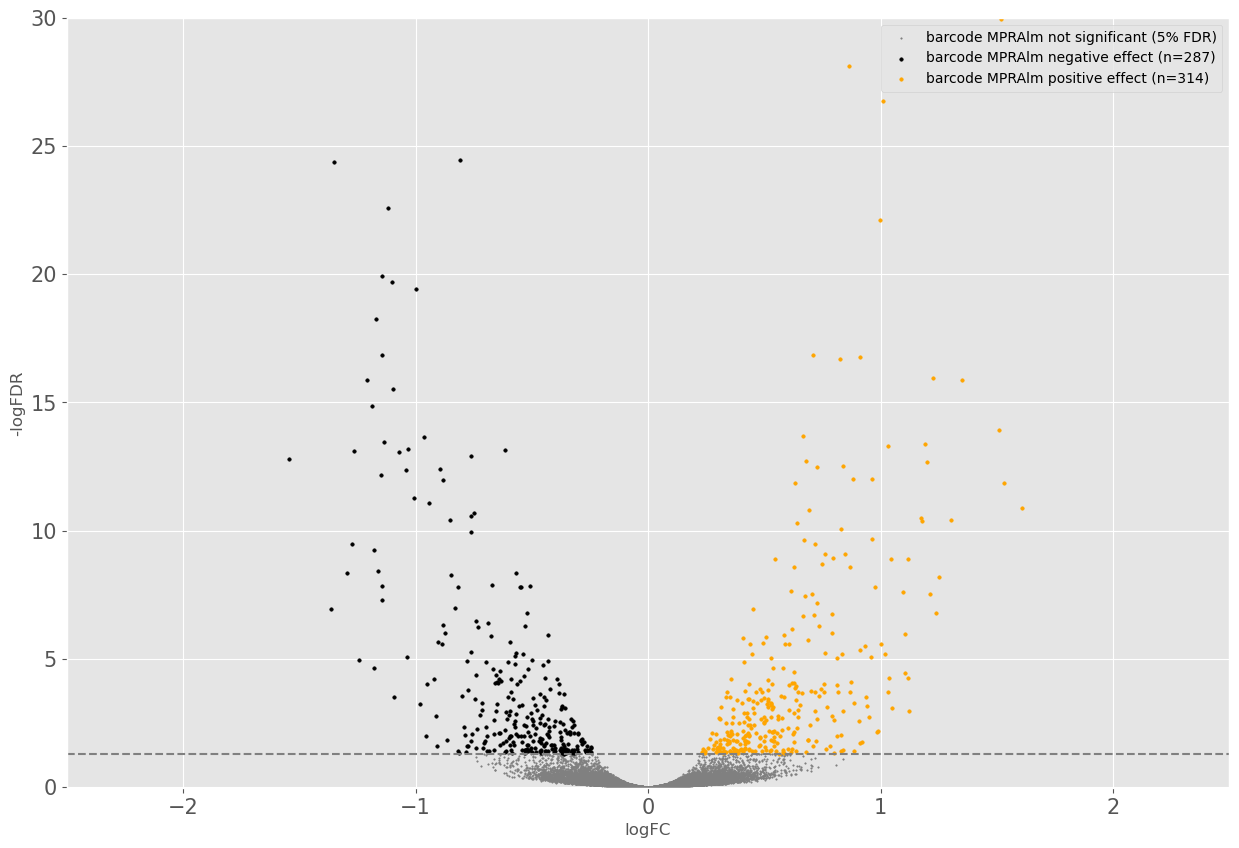

In [40]:
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=6,label="barcode MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=6,label="barcode MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
ax = plt.gca()
ax.set_xlim([-2.5,2.5])
ax.set_ylim([-0.025,30])
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

# plt.savefig('mpralm_41k_results.png', transparent=True)

In [41]:
def is_common(variant_type):
    return variant_type in ['common', 'rare']

In [42]:
merged_variant_df = pd.read_csv(config['files']['creating']['merged_variant_table'], sep='\t')
merged_variant_df

# problem: IDs of one signficant tested variant (cardiac and cava associated) with a "," is not matchable because the ID is not in the merged_prioritized_variants.tsv

# add the two rows of additionally_adding_comma_header_info to merged_variant_df (added these additional columns because significant variant is otherwise not matchable (contains "," (was merged downstream)))
additionally_adding_comma_header_info = pd.read_csv(config['files']['creating']['additionally_variant_info_comma'], sep="\t")
merged_variant_df = merged_variant_df.append(additionally_adding_comma_header_info, ignore_index=True)
merged_variant_df
# merge with variant information:
bc_mpralm_merged_variant_table = bcMPRAlm_table.merge(merged_variant_df, on='ID')

# combine gene type
# aggregate the gene_type:
df_aggregated = bc_mpralm_merged_variant_table.groupby('variant_id')['gene_type'].agg(lambda x: ', '.join(x)).reset_index()
df_aggregated.rename(columns={'gene_type': 'combined_gene_types'}, inplace=True)


# add the combined_gene_types column to the bc_mpralm_merged_variant_table
bc_mpralm_merged_variant_table = bc_mpralm_merged_variant_table.merge(df_aggregated, on='variant_id')

# remove duplicates in ID
bc_mpralm_merged_variant_table = bc_mpralm_merged_variant_table.drop_duplicates(subset='variant_id')

# # bc_mpralm_merged_variant_table
# bcMPRAlm_with_annotation = significant_bcMPRAlm_table.merge(merged_variant_df, on='ID', how='left')
# matchable_bcMPRAlm_with_annotation = bcMPRAlm_with_annotation.loc[~bcMPRAlm_with_annotation['gene_type'].isna()]
# unmatchable_bcMPRA_annotation = bcMPRAlm_with_annotation.loc[bcMPRAlm_with_annotation['gene_type'].isna()]
# problem: control values are not matchable ( we don't care for controls here)

# add this info additionally

significant_variant_table = bc_mpralm_merged_variant_table.loc[bc_mpralm_merged_variant_table['adj.P.Val'] < significants_niveau]
significant_variant_table['variant_id'].nunique() # 596 601 - 5 (controls)
significant_variant_table[~significant_variant_table['gene_type'].isna()].shape[0]
significant_variant_table['abs_logFC'] = significant_variant_table['logFC'].abs()

merged_up = bc_mpralm_merged_variant_table[bc_mpralm_merged_variant_table['mpralm_true'] == 'positive']
merged_down = bc_mpralm_merged_variant_table[bc_mpralm_merged_variant_table['mpralm_true'] == 'negative']

common_sig_up = merged_up[merged_up['variant_type'].apply(is_common)] # 159
ultra_rare_sig_up = merged_up[merged_up['variant_type'] == 'ultra-rare'] # 112
singleton_sig_up = merged_up[merged_up['variant_type'] == 'singleton'] # 130
common_sig_down = merged_down[merged_down['variant_type'].apply(is_common)] # 159
ultra_rare_sig_down = merged_down[merged_down['variant_type'] == 'ultra-rare'] # 112
singleton_sig_down = merged_down[merged_down['variant_type'] == 'singleton'] # 130

/tmp/ipykernel_673798/2389512103.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  merged_variant_df = merged_variant_df.append(additionally_adding_comma_header_info, ignore_index=True)
/tmp/ipykernel_673798/2389512103.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_variant_table['abs_logFC'] = significant_variant_table['logFC'].abs()


In [43]:
# investigate unmatchable:
bcMPRAlm_table.loc[bcMPRAlm_table['adj.P.Val'] < 0.05]['ID'].str.contains(',').sum()
# unmatchable_bcMPRA_annotation['ID'].contains(',')

1

In [44]:
significant_variant_table['variant_id'].nunique()

596

In [45]:
# summary of numbers

# # aggregate the gene_type:
# df_aggregated = significant_variant_table.groupby('ID')['gene_type'].agg(lambda x: ', '.join(x)).reset_index()
# df_aggregated.rename(columns={'gene_type': 'combined_gene_types'}, inplace=True)


# # add the combined_gene_types column to the significant_variant_table
# significant_variant_table = significant_variant_table.merge(df_aggregated, on='ID')

# # remove duplicates in ID
# significant_variant_table = significant_variant_table.drop_duplicates(subset='ID')
# significant_variant_table

# # compute table of ratios of significant variants within each variant type of all significant variants
# significant_variant_table['variant_type'].value_counts()


# significant_variant_table['gene_type'].value_counts()
# significant_variant_table.groupby(['gene_type', 'variant_type']).size()

# Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
#        'ID', 'mpralm_true', 'CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER',
#        'INFO', 'gene_type', 'variant_type', 'abs_logFC'],
#       dtype='object')

In [46]:
191/611 # singleton
# 174/611 # ultra-rare
# 131/611 # common
# 115/611 # rare

0.31260229132569556

In [47]:
significant_variant_table.shape[0]

596

#### Variant numbers: 
- compare all measured variants and the significant variant numbers
- Problem: found out that used methods to assign gene_type is not working => reduces the number

In [48]:
bcMPRAlm_table['variant_id'].nunique()
tested_bcMPRAlm_df = bcMPRAlm_table.loc[bcMPRAlm_table['variant_id'].str.startswith('cardiac_neuro_cava_random')]
tested_bcMPRAlm_df['variant_id'].nunique()

36414

In [49]:
# TODO: fix that the number of variants which we have measures for decreses: New assignement of information
bc_mpralm_merged_variant_table['variant_id'].nunique()

36217

In [50]:
#helpful functions
import os
from collections import defaultdict


# make function which checks which elements are in the gene_type
def is_in_gene_type(gene_type, element):
    # check if element has multiple associations or not
    if "," in gene_type:
        split_gene_type = gene_type.split(", ")
        return element in split_gene_type
    else:
        return gene_type == element

def is_element_of(gene_type, element):
    """
    Returns is element in list of gene types
    @params gene_type: is list of gene types
    @params element: is string which you want to find in gene_type
    """
    return element in gene_type

def get_gene_name_from_variant_id(variant_id):
    """Returns the gene name"""
    # cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G
    return variant_id.split(':')[1].split('|')[0]


def get_gene_lookup_dict(gene_lists):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict


# def split_semicolon_variant_ids(variant_id):
#     """If variant id contains semicolon (;) split the variant_id and return the first part """
#     if ";" in variant_id:
#         return variant_id.split(";")[0]
#     return variant_id


def get_AF(info):
    """
    get AF from INFO: 'AF=0.0126802;AC=1930' => 0.0126802
    """
    return float(info.split('AF=')[1].split(';')[0])


def get_AC(info):
    """
    get AC from INFO: 'AF=0.0126802;AC=1930' => 1930
    """
    return int(info.split('AC=')[1].split(';')[0])


def get_variant_type(AF, AC):
    """
    get ultra-rare, common, singleton from INFO: 'AF=0.0126802;AC=1930' => common
    """
    if AF > 0.05:
        return 'common'
    elif AF > 0.01:
        return 'rare'
    elif AC == 1:
        return 'singleton'
    else:
        return 'ultra-rare'

#### All measured variants numbers: 
- composition between gene_types


In [51]:
# bc_mpralm_merged_variant_table['is_neuro'] = bc_mpralm_merged_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'neuro'))
# bc_mpralm_merged_variant_table['is_cardiac'] = bc_mpralm_merged_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'cardiac'))
# bc_mpralm_merged_variant_table['is_cava'] = bc_mpralm_merged_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'cava'))
# bc_mpralm_merged_variant_table['is_random'] = bc_mpralm_merged_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'random'))
# overall_total = bc_mpralm_merged_variant_table.shape[0]
# gene_type_table_all_measured_vars = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [bc_mpralm_merged_variant_table['is_neuro'].sum(), bc_mpralm_merged_variant_table['is_cardiac'].sum(), bc_mpralm_merged_variant_table['is_cava'].sum(), bc_mpralm_merged_variant_table['is_random'].sum()], "proportion": [bc_mpralm_merged_variant_table['is_neuro'].sum() / overall_total, bc_mpralm_merged_variant_table['is_cardiac'].sum() / overall_total, bc_mpralm_merged_variant_table['is_cava'].sum() / overall_total, bc_mpralm_merged_variant_table['is_random'].sum() / overall_total]})
# gene_type_table_all_measured_vars

In [52]:
tested_bcMPRAlm_df['gene_name'] = tested_bcMPRAlm_df['variant_id'].apply(get_gene_name_from_variant_id)

# look the gene name up and find the associated gene sets
# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = os.listdir(gene_list_dir)

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists)

# add gene_set annotation
tested_bcMPRAlm_df['combined_gene_type'] = tested_bcMPRAlm_df['gene_name'].apply(lambda gene: gene_lookup_dict[gene])
tested_bcMPRAlm_df['combined_gene_type'].value_counts()
# [neuro]             15108
# [cardiac]           10227
# [cava]               5771
# [random]             3483
# [neuro, cardiac]     1012
# [neuro, cava]         411
# [cava, cardiac]       402
# neuro_number= 15108 + 1012 + 411
# cardiac_number= 10227 + 1012 + 402
# cava_number= 5771 + 411 + 402
# random_number= 3483

# add variant info from variant.vcf to MPRAlm results (AF and AC => variant type)
# General vcf (final_design -> vcf_file has ids with ";" but is missing AC (vcf info of 45737 but some IDs (third column ";"))
vcf_file = pd.read_csv(config['files']['final_design']['vcf_file_only_tested'], sep="\t", comment="#", header=None)
vcf_file.columns = ['#CHROM', 'POS', 'vcf_ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
# found not matchable ids with ";" in the header  (mpralm results have 'cardiac_neuro_cava_random:BRCA2|ENSG00000139618.18|EH38E1665846|13-32424473-T-G' and variant.vcf has "cardiac_neuro_cava_random:BRCA2|ENSG00000139618.18|EH38E1665846|13-32424473-T-G;GC_Selvarajan:rs499966")
# vcf_file['semicolon_split_variant_id'] = vcf_file['ID'].apply(split_semicolon_variant_ids)

# tested_vcf_file = vcf_file.loc[vcf_file['semicolon_split_variant_id'].str.startswith('cardiac_neuro_cava_random')]
# add columns AC and AF from Info
vcf_file['AF'] = vcf_file['INFO'].apply(get_AF)
vcf_file['AC'] = vcf_file['INFO'].apply(get_AC)
# add variant type information
vcf_file['variant_type'] = vcf_file.apply(lambda x: get_variant_type(x['AF'], x['AC']), axis=1)
# merge bcMPRAlm and variant info vcf using "variant_id" (left join)
tested_bcMPRAlm_df_metainfo = tested_bcMPRAlm_df.merge(vcf_file[['vcf_ID', 'AF', 'AC', 'variant_type']], left_on='variant_id', right_on='vcf_ID', how='left')
tested_bcMPRAlm_df_metainfo['variant_id'].nunique() # 36414

# # make sure everything could be matched
# tested_bcMPRAlm_df_metainfo_matched = tested_bcMPRAlm_df_metainfo.loc[~tested_bcMPRAlm_df_metainfo['variant_type'].isna()]
# tested_bcMPRAlm_df_metainfo_matched['variant_id'].nunique() # 36414 => everything matched

/tmp/ipykernel_673798/3546166118.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_df['gene_name'] = tested_bcMPRAlm_df['variant_id'].apply(get_gene_name_from_variant_id)
/tmp/ipykernel_673798/3546166118.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_df['combined_gene_type'] = tested_bcMPRAlm_df['gene_name'].apply(lambda gene: gene_lookup_dict[gene])


36414

In [53]:
tested_bcMPRAlm_df_metainfo['combined_gene_type'].value_counts()

[neuro]             15108
[cardiac]           10227
[cava]               5771
[random]             3483
[neuro, cardiac]     1012
[neuro, cava]         411
[cava, cardiac]       402
Name: combined_gene_type, dtype: int64

In [58]:
# add column is_neuro, is_cardiac, ... which gets result of is_element_of
tested_bcMPRAlm_df_metainfo['is_neuro'] = tested_bcMPRAlm_df_metainfo['combined_gene_type'].apply(lambda x: is_element_of(x, 'neuro'))
tested_bcMPRAlm_df_metainfo['is_cardiac'] = tested_bcMPRAlm_df_metainfo['combined_gene_type'].apply(lambda x: is_element_of(x, 'cardiac'))
tested_bcMPRAlm_df_metainfo['is_cava'] = tested_bcMPRAlm_df_metainfo['combined_gene_type'].apply(lambda x: is_element_of(x, 'cava'))
tested_bcMPRAlm_df_metainfo['is_random'] = tested_bcMPRAlm_df_metainfo['combined_gene_type'].apply(lambda x: is_element_of(x, 'random'))

In [59]:
tested_bcMPRAlm_df_metainfo.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'ID', 'mpralm_true', 'nlog10', 'label', 'gene_name',
       'combined_gene_type', 'vcf_ID', 'AF', 'AC', 'variant_type', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random'],
      dtype='object')

In [60]:
def check_variant_type_numbers_per_gene_set(gene_set, df):
    """
    Check and print the numbers of variant types for the given gene set
    """
    print(gene_set)
    current_gene_set_df = df.loc[df['combined_gene_type'].apply(lambda x: is_element_of(x, gene_set))]
    current_gene_set_df

    # 2. calculate the groupby of variant_type
    print(current_gene_set_df.groupby('variant_type').size())

    # 3. calculate the number of different gene names per group
    current_gene_set_df.groupby('variant_type')['gene_name'].nunique()
    print(f"Number of genes: {current_gene_set_df['gene_name'].nunique()}")

In [61]:
# for each [neuro, cardiac, cava, random] do:
# 1. get the subtable
# 2. calculate the groupby of variant_type
# 3. calculate the number of different gene names per group
for gene_set in ['neuro', 'cardiac', 'cava', 'random']:
    check_variant_type_numbers_per_gene_set(gene_set, tested_bcMPRAlm_df_metainfo)
# current_gene_set = "neuro"
# print(current_gene_set)
# current_gene_set_df = tested_bcMPRAlm_df_metainfo.loc[tested_bcMPRAlm_df_metainfo['combined_gene_type'].apply(lambda x: is_element_of(x, current_gene_set))]
# current_gene_set_df

# # 2. calculate the groupby of variant_type
# print(current_gene_set_df.groupby('variant_type').size())

# # 3. calculate the number of different gene names per group
# current_gene_set_df.groupby('variant_type')['gene_name'].nunique()
# print(f'Number of genes: {current_gene_set_df['gene_name'].nunique()}')


neuro
variant_type
common        5528
rare          4564
singleton     3251
ultra-rare    3188
dtype: int64
Number of genes: 305
cardiac
variant_type
common        3211
rare          2543
singleton     2952
ultra-rare    2935
dtype: int64
Number of genes: 161
cava
variant_type
common         705
rare           503
singleton     2710
ultra-rare    2666
dtype: int64
Number of genes: 47
random
variant_type
common         297
rare           243
singleton     1479
ultra-rare    1464
dtype: int64
Number of genes: 25


In [62]:
variants_to_be_tested = {
    'gene_set': ['neuro', 'cardiac', 'cava', 'random'],
    'gene_number': [306,164, 48, 25],
    'common': [11591, 6460, 1422, 509],
    'rare': [9562, 5283, 1136, 447],
    'ultra-rare': [5000, 5000, 5000, 5000],
    'singleton':  [5000, 5000, 5000, 5000],
}

variants_measured = {
    'gene_set': ['neuro', 'cardiac', 'cava', 'random'],
    'gene_number': [305, 161, 47, 25],
    'common': [5528, 3211, 705, 297],
    'rare': [4564, 2543, 503, 243],
    'ultra-rare': [3188, 2935, 2666, 1464],
    'singleton':  [3251, 2952, 2710, 1479],
}

# iterate both dicts and create dict of proportions of variants to be tested and actually measured
variant_proportions = {}
for key in variants_to_be_tested.keys():
    if key == 'gene_set':
        variant_proportions[key] = variants_to_be_tested[key]
        continue
    variant_proportions[key] = [variants_measured[key][i] / variants_to_be_tested[key][i] for i in range(len(variants_to_be_tested[key]))]

pd.DataFrame(variant_proportions)


,gene_set,gene_number,common,rare,ultra-rare,singleton
0,neuro,0.996732,0.476922,0.477306,0.6376,0.6502
1,cardiac,0.981707,0.497059,0.481355,0.5870,0.5904
2,cava,0.979167,0.495781,0.442782,0.5332,0.5420
3,random,1.000000,0.583497,0.543624,0.2928,0.2958


In [63]:
## get number of all commons, rare, ultra rare, singleton
all_variant_type_table = tested_bcMPRAlm_df_metainfo.groupby('variant_type').size().reset_index(name='counts')
all_variant_type_table
# tested_bcMPRAlm_df_metainfo['variant_type'].value_counts()

,variant_type,counts
0,common,9446
1,rare,7588
2,singleton,9740
3,ultra-rare,9640


In [64]:
tested_bcMPRAlm_df.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,label,gene_name,combined_gene_type
0,1.490195,1.896905,19.466523,1.288060e-67,4.758221e-63,141.899179,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,62.322555,cardiac_neuro_cava_random,TRIO,[neuro]
1,1.514576,1.002377,13.939829,8.049105e-37,1.486710e-32,71.678281,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,31.827774,cardiac_neuro_cava_random,TRIO,[neuro]
2,1.518126,0.932093,13.543783,8.847412e-35,1.089441e-30,67.099942,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,29.962796,cardiac_neuro_cava_random,ANKZF1,[random]
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive,28.134743,cardiac_neuro_cava_random,ATR,[cava]
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive,26.768962,cardiac_neuro_cava_random,CDH1,[cava]


In [65]:
# merge them

In [66]:
neuro_number= 15108 + 1012 + 411
cardiac_number= 10227 + 1012 + 402
cava_number= 5771 + 411 + 402
random_number= 3483

# make df with column gene set, measured variants
gene_type_table_measured_vars = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [neuro_number, cardiac_number, cava_number, random_number]})
gene_type_table_measured_vars

,gene_type,count
0,neuro,16531
1,cardiac,11641
2,cava,6584
3,random,3483


#### Significant numbers
- all significant
  - variant_type
  - gene_type
- common
  - gene_type
- neuro
  - variant_type

In [67]:
# get only significants
significant_variant_table = tested_bcMPRAlm_df_metainfo.loc[tested_bcMPRAlm_df_metainfo['adj.P.Val'] < 0.05]

# all variants: variant_type number and proportion:
print(significant_variant_table['variant_id'].nunique())
# dataframe of groupby variant type
variant_type_table = significant_variant_table.groupby('variant_type').size().reset_index(name='counts')
variant_type_table['proportion'] = variant_type_table['counts'] / significant_variant_table.shape[0]
variant_type_table

596


,variant_type,counts,proportion
0,common,127,0.213087
1,rare,111,0.186242
2,singleton,187,0.313758
3,ultra-rare,171,0.286913


In [68]:
127/9446


0.013444844378572941

In [69]:
# compute the proportion of significant to all measured variants
variant_type_table['proportion_measured'] = variant_type_table['counts'] / all_variant_type_table['counts']
variant_type_table['proportion_significant'] =  variant_type_table['counts'] / variant_type_table['counts'].sum()
variant_type_table

,variant_type,counts,proportion,proportion_measured,proportion_significant
0,common,127,0.213087,0.013445,0.213087
1,rare,111,0.186242,0.014628,0.186242
2,singleton,187,0.313758,0.019199,0.313758
3,ultra-rare,171,0.286913,0.017739,0.286913


In [70]:
significant_variant_table['combined_gene_type'].value_counts()
# [neuro]             257
# [cardiac]           145
# [cava]              105
# [random]             61
# [neuro, cardiac]     17
# [neuro, cava]         6
# [cava, cardiac]       5

neuro_sig_number = 257 + 17 + 6
cardiac_sig_number = 145 + 17 + 5
cava_sig_number = 105 + 6 + 5
random_sig_number = 61

significant_gene_type_table_measured_vars = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [neuro_sig_number, cardiac_sig_number, cava_sig_number, random_sig_number]})
significant_gene_type_table_measured_vars


,gene_type,count
0,neuro,280
1,cardiac,167
2,cava,116
3,random,61


In [71]:
# berechne % von to be tested variants
significant_gene_type_table_measured_vars['proportion_measured'] = significant_gene_type_table_measured_vars['count'] / gene_type_table_measured_vars['count']
significant_gene_type_table_measured_vars['proportion_significant'] = significant_gene_type_table_measured_vars['count'] / significant_gene_type_table_measured_vars['count'].sum()
significant_gene_type_table_measured_vars

,gene_type,count,proportion_measured,proportion_significant
0,neuro,280,0.016938,0.448718
1,cardiac,167,0.014346,0.267628
2,cava,116,0.017618,0.185897
3,random,61,0.017514,0.097756


In [72]:

significant_variant_table.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'ID', 'mpralm_true', 'nlog10', 'label', 'gene_name',
       'combined_gene_type', 'vcf_ID', 'AF', 'AC', 'variant_type', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random'],
      dtype='object')

In [73]:
# # Print the number of elements associated to the gene_types for all significant variants
# all_gene_types = ['neuro', 'cardiac', 'cava', 'random']
# cardiac = significant_variant_table.loc[significant_variant_table['combined_gene_type'].apply(lambda x: is_in_gene_type(x, 'cardiac'))]
# cardiac.loc[cardiac['ID'] == 'MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G,MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G']
# cava = significant_variant_table.loc[significant_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'cava'))]
# cava.loc[cava['ID'] == 'MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G,MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G']
# # significant_variant_table.loc[significant_variant_table['ID'] == 'MYH6|ENSG00000197616.13|EH38E1703093|14-23399820-A-G,MYH7|ENSG00000092054.13|EH38E1703093|14-23399820-A-G']


In [74]:
significant_variant_table.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,...,gene_name,combined_gene_type,vcf_ID,AF,AC,variant_type,is_neuro,is_cardiac,is_cava,is_random
0,1.490195,1.896905,19.466523,1.288060e-67,4.758221e-63,141.899179,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,positive,62.322555,...,TRIO,[neuro],cardiac_neuro_cava_random:TRIO|ENSG00000038382...,0.000007,1,singleton,True,False,False,False
1,1.514576,1.002377,13.939829,8.049105e-37,1.486710e-32,71.678281,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,positive,31.827774,...,TRIO,[neuro],cardiac_neuro_cava_random:TRIO|ENSG00000038382...,0.016828,2558,rare,True,False,False,False
2,1.518126,0.932093,13.543783,8.847412e-35,1.089441e-30,67.099942,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,positive,29.962796,...,ANKZF1,[random],cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,0.000007,1,singleton,False,False,False,True
3,0.863942,0.977534,12.433226,7.939775e-33,7.332580e-29,63.640162,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,positive,28.134743,...,ATR,[cava],cardiac_neuro_cava_random:ATR|ENSG00000175054....,0.000046,7,ultra-rare,False,False,True,False
4,1.009257,1.167232,12.338300,2.304092e-31,1.702309e-27,60.138008,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,CDH1|ENSG00000039068.20|EH38E3187943|16-687843...,positive,26.768962,...,CDH1,[cava],cardiac_neuro_cava_random:CDH1|ENSG00000039068...,0.000007,1,singleton,False,False,True,False


In [75]:
# all variants: gene_type
# dataframe of groupby gene type
# variant_type_table = significant_variant_table.groupby('gene_type').size().reset_index(name='counts')
# variant_type_table = significant_variant_table.groupby('combined_gene_types').size().reset_index(name='counts')
# variant_type_table['ratio'] = variant_type_table['counts'] / significant_variant_table.shape[0]
variant_type_table

# # add column is_neuro, is_cardiac, ... which gets result of is_in_gene_type and followed by counting the numbers of these columns but compute ratios based on the total numbers of True values in these columns
# significant_variant_table['is_neuro'] = significant_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'neuro'))
# significant_variant_table['is_cardiac'] = significant_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'cardiac'))
# significant_variant_table['is_cava'] = significant_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'cava'))
# significant_variant_table['is_random'] = significant_variant_table['combined_gene_types'].apply(lambda x: is_in_gene_type(x, 'random'))

# # add column is_neuro, is_cardiac, ... which gets result of is_in_gene_type and followed by counting the numbers of these columns but compute ratios based on the total numbers of True values in these columns
# significant_variant_table['is_neuro'] = significant_variant_table['combined_gene_type'].apply(lambda x: is_element_of(x, 'neuro'))
# significant_variant_table['is_cardiac'] = significant_variant_table['combined_gene_type'].apply(lambda x: is_element_of(x, 'cardiac'))
# significant_variant_table['is_cava'] = significant_variant_table['combined_gene_type'].apply(lambda x: is_element_of(x, 'cava'))
# significant_variant_table['is_random'] = significant_variant_table['combined_gene_type'].apply(lambda x: is_element_of(x, 'random'))

overall_total = 0
# count true values among all columns starting with "is_"
for gene_type in ['neuro', 'cardiac', 'cava', 'random']:
    overall_total += significant_variant_table[f'is_{gene_type}'].sum()
    # print(significant_variant_table[f'is_{gene_type}'].sum())
# print(overall_total)
significant_variant_table.groupby('is_neuro').size()
# create dataframe of "count": [significant_variant_table['is_neuro'].sum(), significant_variant_table['is_cardiac'].sum(), significant_variant_table['is_cava'].sum(), significant_variant_table['is_random'].sum()], "ratio": [significant_variant_table['is_neuro'].sum() / overall_total, significant_variant_table['is_cardiac'].sum() / overall_total, significant_variant_table['is_cava'].sum() / overall_total, significant_variant_table['is_random'].sum() / overall_total]
gene_type_table_all_variants = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [significant_variant_table['is_neuro'].sum(), significant_variant_table['is_cardiac'].sum(), significant_variant_table['is_cava'].sum(), significant_variant_table['is_random'].sum()], "ratio": [significant_variant_table['is_neuro'].sum() / overall_total, significant_variant_table['is_cardiac'].sum() / overall_total, significant_variant_table['is_cava'].sum() / overall_total, significant_variant_table['is_random'].sum() / overall_total]})
print(gene_type_table_all_variants)
# print(significant_variant_table[significant_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 1][['is_neuro', 'is_cardiac', 'is_cava', 'is_random']])

# same for common variants
print('common')
common_variant_table = significant_variant_table[significant_variant_table['variant_type'].apply(is_only_common)]
common_overall_total = 0
for gene_type in ['neuro', 'cardiac', 'cava', 'random']:
    common_overall_total += common_variant_table[f'is_{gene_type}'].sum()
common_overall_total = common_variant_table.shape[0]
print(common_overall_total)

gene_type_table_common_variants = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [common_variant_table['is_neuro'].sum(), common_variant_table['is_cardiac'].sum(), common_variant_table['is_cava'].sum(), common_variant_table['is_random'].sum()], "ratio": [common_variant_table['is_neuro'].sum() / common_overall_total, common_variant_table['is_cardiac'].sum() / common_overall_total, common_variant_table['is_cava'].sum() / common_overall_total, common_variant_table['is_random'].sum() / common_overall_total]})
print(gene_type_table_common_variants)
# print rows with more than one True value in "is_x" and print the name of the columns which have True values
print(common_variant_table[common_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 1][['is_neuro', 'is_cardiac', 'is_cava', 'is_random']])

# same for rare variants
print('rare')
rare_variant_table = significant_variant_table[significant_variant_table['variant_type'].apply(is_rare)]
rare_overall_total = 0
for gene_type in ['neuro', 'cardiac', 'cava', 'random']:
    rare_overall_total += rare_variant_table[f'is_{gene_type}'].sum()
rare_overall_total = rare_variant_table.shape[0]
print(rare_overall_total)

gene_type_table_rare_variants = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [rare_variant_table['is_neuro'].sum(), rare_variant_table['is_cardiac'].sum(), rare_variant_table['is_cava'].sum(), rare_variant_table['is_random'].sum()], "ratio": [rare_variant_table['is_neuro'].sum() / rare_overall_total, rare_variant_table['is_cardiac'].sum() / rare_overall_total, rare_variant_table['is_cava'].sum() / rare_overall_total, rare_variant_table['is_random'].sum() / rare_overall_total]})
print(gene_type_table_rare_variants)
print(rare_variant_table[rare_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 1][['is_neuro', 'is_cardiac', 'is_cava', 'is_random']])


# same for ultra rare variants
print('ultra-rare')
ultra_rare_variant_table = significant_variant_table[significant_variant_table['variant_type'].apply(is_ultra_rare)]
ultra_rare_overall_total = 0
for gene_type in ['neuro', 'cardiac', 'cava', 'random']:
    ultra_rare_overall_total += ultra_rare_variant_table[f'is_{gene_type}'].sum()

ultra_rare_overall_total = ultra_rare_variant_table.shape[0]
print(ultra_rare_overall_total)

gene_type_table_ultra_rare_variants = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [ultra_rare_variant_table['is_neuro'].sum(), ultra_rare_variant_table['is_cardiac'].sum(), ultra_rare_variant_table['is_cava'].sum(), ultra_rare_variant_table['is_random'].sum()], "ratio": [ultra_rare_variant_table['is_neuro'].sum() / ultra_rare_overall_total, ultra_rare_variant_table['is_cardiac'].sum() / ultra_rare_overall_total, ultra_rare_variant_table['is_cava'].sum() / ultra_rare_overall_total, ultra_rare_variant_table['is_random'].sum() / ultra_rare_overall_total]})
print(gene_type_table_ultra_rare_variants)

# same for ultra rare variants
print('singleton')
singleton_variant_table = significant_variant_table[significant_variant_table['variant_type'].apply(is_singleton)]
singleton_overall_total = 0
for gene_type in ['neuro', 'cardiac', 'cava', 'random']:
    singleton_overall_total += singleton_variant_table[f'is_{gene_type}'].sum()

singleton_overall_total = singleton_variant_table.shape[0]
print(singleton_overall_total)

gene_type_table_singleton_variants = pd.DataFrame({"gene_type": ['neuro', 'cardiac', 'cava', 'random'], "count": [singleton_variant_table['is_neuro'].sum(), singleton_variant_table['is_cardiac'].sum(), singleton_variant_table['is_cava'].sum(), singleton_variant_table['is_random'].sum()], "ratio": [singleton_variant_table['is_neuro'].sum() / singleton_overall_total, singleton_variant_table['is_cardiac'].sum() / singleton_overall_total, singleton_variant_table['is_cava'].sum() / singleton_overall_total, singleton_variant_table['is_random'].sum() / singleton_overall_total]})
print(gene_type_table_singleton_variants)


  gene_type  count     ratio
0     neuro    280  0.448718
1   cardiac    167  0.267628
2      cava    116  0.185897
3    random     61  0.097756
common
127
  gene_type  count     ratio
0     neuro     80  0.629921
1   cardiac     37  0.291339
2      cava     10  0.078740
3    random      5  0.039370
     is_neuro  is_cardiac  is_cava  is_random
109     False        True     True      False
165      True        True    False      False
216      True        True    False      False
535      True        True    False      False
550      True        True    False      False
rare
111
  gene_type  count     ratio
0     neuro     71  0.639640
1   cardiac     31  0.279279
2      cava      9  0.081081
3    random      4  0.036036
     is_neuro  is_cardiac  is_cava  is_random
225      True        True    False      False
260      True        True    False      False
450      True        True    False      False
468      True        True    False      False
ultra-rare
171
  gene_type  count     r

In [134]:
# number of significant variants with > 1 association to gene_type (17 with second resequencing)
print('Number of significant variants with multiple assignments: (And the table underneath)', significant_variant_table[significant_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 1][['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].shape[0])
significant_variant_table[significant_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 1][['is_neuro', 'is_cardiac', 'is_cava', 'is_random']]
# significant_variant_table[significant_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 2][['is_neuro', 'is_cardiac', 'is_cava', 'is_random']] # no variants associated to 3 gene sets
# cardiac, cava = 5
# neuro, cardiac = 12
# new: 28
# neuro and cardiac: 17
# neuro and cava: 6
# cardiac and cava: 5

Number of significant variants with multiple assignments: (And the table underneath) 28


,is_neuro,is_cardiac,is_cava,is_random
19,False,True,True,False
40,True,False,True,False
54,False,True,True,False
109,False,True,True,False
127,True,False,True,False
165,True,True,False,False
169,True,True,False,False
177,True,True,False,False
216,True,True,False,False
221,True,False,True,False


In [132]:
# count the number of rows which have True values for is_neuro, is_cardiac; or for is_neuro, is_cava; or for is_cardiac, is_cava
significant_variant_table[significant_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 2][['is_neuro', 'is_cardiac', 'is_cava', 'is_random']]
significant_variant_table[significant_variant_table[['is_neuro', 'is_cardiac', 'is_cava', 'is_random']].sum(axis=1) > 1].shape[0]
print(f"Number of multiple assignments between neuro and cardiac: {significant_variant_table[significant_variant_table[['is_neuro', 'is_cardiac']].sum(axis=1) > 1].shape[0]}")
print(f"Number of multiple assignments between neuro and cava: {significant_variant_table[significant_variant_table[['is_neuro', 'is_cava']].sum(axis=1) > 1].shape[0]}")
print(f"Number of multiple assignments between cardiac and cava: {significant_variant_table[significant_variant_table[['is_cardiac', 'is_cava']].sum(axis=1) > 1].shape[0]}")


Number of multiple assignments between neuro and cardiac: 17
Number of multiple assignments between neuro and cava: 6
Number of multiple assignments between cardiac and cava: 5


In [77]:
# number of significant variants (counting overlaps)
269 + 166 + 117 + 61

613

In [78]:
# common variants: variant_type number and ratio
common_variant_table = significant_variant_table[significant_variant_table['variant_type'].apply(is_common)]
common_variant_table['variant_id'].nunique()

# dataframe of groupby variant type
common_variant_type_table = common_variant_table.groupby('variant_type').size().reset_index(name='counts')
common_variant_type_table['ratio'] = common_variant_type_table['counts'] / common_variant_table.shape[0]

In [79]:
# common_significant_variants = significant_variant_table.loc[significant_variant_table['variant_type'] == 'common']
# # print(common_significant_variants.shape[0])
# common_significant_variants['gene_type'].value_counts()

# # ratio of common variants
# # 80/131 # neuro
# # 36/131 # cardiac
# # 10/131 # cava
# # 5/131 # random



In [80]:
significant_variant_table.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'ID', 'mpralm_true', 'nlog10', 'label', 'gene_name',
       'combined_gene_type', 'vcf_ID', 'AF', 'AC', 'variant_type', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random'],
      dtype='object')

In [81]:
# neuro specific variant type composition
neuro_significant_variants = significant_variant_table.loc[significant_variant_table['is_neuro']]
neuro_specific_total = neuro_significant_variants.shape[0]
print('Number of neuro specific variants: ', neuro_specific_total)
# neuro_singleton_variant_table = neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_singleton)].shape[0]
# neuro_ultra_rare_variant_table = neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_ultra_rare)].shape[0]
# neuro_rare_variant_table = neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_rare)].shape[0]
# neuro_common_variant_table = neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_common)].shape[0]
# print(type(neuro_common_variant_table))
# print(neuro_common_variant_table)
# neuro_significant_variants.head()

neuro_significant_variants['variant_type'].value_counts()
# dataframe of groupby variant type
neuro_significant_variant_type_table = neuro_significant_variants.groupby('variant_type').size().reset_index(name='counts')
neuro_significant_variant_type_table['ratio'] = neuro_significant_variant_type_table['counts'] / neuro_specific_total
neuro_significant_variant_type_table
neuro_specific_variant_type = pd.DataFrame({"variant_type": ['Common', 'Rare', 'Ultra-rare', 'singleton'], "count": [neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_only_common)].shape[0], neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_rare)].shape[0], neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_ultra_rare)].shape[0], neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_singleton)].shape[0]], "ratio": [neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_only_common)].shape[0] / neuro_specific_total, neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_rare)].shape[0] / neuro_specific_total, neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_ultra_rare)].shape[0] / neuro_specific_total, neuro_significant_variants[neuro_significant_variants['variant_type'].apply(is_singleton)].shape[0] / neuro_specific_total]})
neuro_specific_variant_type

Number of neuro specific variants:  280


,variant_type,count,ratio
0,Common,80,0.285714
1,Rare,71,0.253571
2,Ultra-rare,67,0.239286
3,singleton,62,0.221429


In [82]:
# Make lists of all common variants

# Make lists of all rare variants

#

In [84]:
# significant_variant_table['gene_type'].value_counts()
# significant_variant_table['ID'].value_counts()

In [85]:
# get size of the variant_type groups:
variant_type_tables = [common_sig_up, ultra_rare_sig_up, singleton_sig_up, common_sig_down, ultra_rare_sig_down, singleton_sig_down]
variant_type_table_names = ["common_sig_up", "ultra_rare_sig_up", "singleton_sig_up", "common_sig_down", "ultra_rare_sig_down", "singleton_sig_down"]
for i in range(len(variant_type_tables)):
    print(variant_type_table_names[i], variant_type_tables[i].shape[0])

# bc MPRAlm with 10 barcodes and all variant controls
# common_sig_up 75
# ultra_rare_sig_up 63
# singleton_sig_up 75
# common_sig_down 80
# ultra_rare_sig_down 51
# singleton_sig_down 53

common_sig_up 116
ultra_rare_sig_up 93
singleton_sig_up 103
common_sig_down 122
ultra_rare_sig_down 78
singleton_sig_down 84


#### Investigate regions open in H1 neuron

In [86]:
def get_region_id(variant_id):
    """
    Return the SCREEN id
    cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G => EH38E3187943

    """
    return variant_id.split(':')[1].split('|')[2]



In [87]:
h1_non_low_dnase_bed = pd.read_csv(config['files']['creating']['non_low_Dnase_h1_neuro_bed'], sep="\t", header=None) # 135131
h1_non_low_dnase_bed.columns = ['h1_chr', 'h1_start', 'h1_end', 'h1_region', 'h1_score', 'h1_strand', 'h1_another_start', 'h1_another_end', 'h1_annotation', 'h1_info_type', 'data_missing']

interesting_h1_df = h1_non_low_dnase_bed[['h1_region', 'h1_annotation', 'h1_info_type']]
interesting_h1_df['h1_open'] = True
# find all region ids from the variant headers
tested_bcMPRAlm_df_metainfo['region_id'] = tested_bcMPRAlm_df_metainfo['variant_id'].apply(get_region_id)

# match with the headers from the bed file
tested_bcMPRAlm_df_metainfo_open_h1 = tested_bcMPRAlm_df_metainfo.merge(interesting_h1_df[['h1_region', 'h1_open']], left_on='region_id', right_on="h1_region", how='left')
# tested_bcMPRAlm_df_metainfo_open_h1 = tested_bcMPRAlm_df_metainfo.merge(interesting_h1_df, left_on='region_id', right_on="h1_region", how='inner')
print(tested_bcMPRAlm_df_metainfo.shape[0])
# how many unique hits => number of regions open in neurons
tested_bcMPRAlm_df_metainfo_open_h1.shape[0] # 1789
tested_bcMPRAlm_df_metainfo_open_h1.loc[~tested_bcMPRAlm_df_metainfo_open_h1['h1_open'].isna()].shape[0] #1789
tested_bcMPRAlm_df_metainfo_open_h1['h1_open'].value_counts()


# significant:
significant_bcMPRAlm_df = tested_bcMPRAlm_df_metainfo_open_h1.loc[tested_bcMPRAlm_df_metainfo_open_h1['adj.P.Val'] < 0.05]
n_significant_vars_open = significant_bcMPRAlm_df.loc[significant_bcMPRAlm_df['h1_open'] == True].shape[0] # 45
n_significant_vars = tested_bcMPRAlm_df_metainfo_open_h1.loc[tested_bcMPRAlm_df_metainfo_open_h1['adj.P.Val'] < 0.05].shape[0] # 596
# 45/596 # 0.0755
print(f"Proportion of significant effects in regions open in neuron: {round(n_significant_vars_open/n_significant_vars * 100,2)}%")
# => 7.55 % der significanten varianten effecte sind in offenen bereichen eines neuro progenitor (H1)


36414
Proportion of significant effects in regions open in neuron: 7.55%


/tmp/ipykernel_673798/727973275.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  interesting_h1_df['h1_open'] = True


In [127]:
# How much of the open chromatin regions do we have within our design
h1_matched_tested_bcMPRAlm = interesting_h1_df.merge(tested_bcMPRAlm_df_metainfo[['region_id', 'adj.P.Val', 'combined_gene_type', 'variant_type']], left_on='h1_region', right_on='region_id', how='inner')
h1_matched_tested_bcMPRAlm.shape[0] # 1789
h1_matched_tested_bcMPRAlm['combined_gene_type'].value_counts()
# [cardiac]           586
# [neuro]             542
# [random]            320
# [cava]              225
# [neuro, cardiac]     46
# [neuro, cava]        35
# [cava, cardiac]      35
print("Mostly cardiac overlap, second highest number is from neuro but neuro group is highest")
h1_matched_tested_bcMPRAlm['variant_type'].value_counts()
# singleton     563
# ultra-rare    532
# common        367
# rare          327

Mostly cardiac overlap, second highest number is from neuro but neuro group is highest


singleton     563
ultra-rare    532
common        367
rare          327
Name: variant_type, dtype: int64

In [121]:
# investigate if all regions are matchable: If a region is not matching the open regions does this mean it is not open according to the data set
h1_bed = pd.read_csv(config['files']['creating']['h1_neuro_bed'], sep="\t", header=None) # 135131
h1_bed.columns = ['h1_chr', 'h1_start', 'h1_end', 'h1_region', 'h1_score', 'h1_strand', 'h1_another_start', 'h1_another_end', 'h1_annotation', 'h1_info_type', 'data_missing']
interesting_h1_bed = h1_bed[['h1_region', 'h1_annotation', 'h1_info_type']]
tested_bcMPRAlm_df_metainfo_h1_regions = tested_bcMPRAlm_df_metainfo.merge(interesting_h1_bed[['h1_region', 'h1_annotation']], left_on='region_id', right_on="h1_region", how='left')

print(tested_bcMPRAlm_df_metainfo.shape[0])
tested_bcMPRAlm_df_metainfo_h1_regions_matchable = tested_bcMPRAlm_df_metainfo_h1_regions.loc[~tested_bcMPRAlm_df_metainfo_h1_regions['h1_annotation'].isna()]
print(tested_bcMPRAlm_df_metainfo_h1_regions_matchable.shape[0]) # 36414 (Same length => all matchable)
print("Same length => all matchable => if a region is not matchable with the non low DNase it is not open according to the data set")

36414
36414
Same length => all matchable


In [92]:
tested_bcMPRAlm_df_metainfo_open_h1.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'ID', 'mpralm_true', 'nlog10', 'label', 'gene_name',
       'combined_gene_type', 'vcf_ID', 'AF', 'AC', 'variant_type', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random', 'region_id', 'h1_region',
       'h1_open'],
      dtype='object')

In [114]:
tested_bcMPRAlm_df_metainfo_open_h1.shape[0]

36414

In [113]:
tested_bcMPRAlm_df_metainfo_open_h1.loc[tested_bcMPRAlm_df_metainfo_open_h1['h1_open'] == True] # 1789

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,mpralm_true,nlog10,...,AF,AC,variant_type,is_neuro,is_cardiac,is_cava,is_random,region_id,h1_region,h1_open
17,1.227138,1.066441,9.738981,5.550559e-20,1.139129e-16,34.199325,cardiac_neuro_cava_random:H1-3|ENSG00000124575...,H1-3|ENSG00000124575.7|EH38E3697725|6-26269112...,positive,15.943427,...,0.000007,1,singleton,False,False,False,True,EH38E3697725,EH38E3697725,True
24,1.508395,1.151236,9.296124,7.578334e-18,1.217179e-14,28.791935,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,GATA4|ENSG00000136574.19|EH38E2610941|8-116424...,positive,13.914645,...,0.199174,30227,common,False,True,False,False,EH38E2610941,EH38E2610941,True
34,-1.544636,0.913410,-8.824097,1.464236e-16,1.590893e-13,26.280503,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,NOS1AP|ENSG00000198929.13|EH38E2844159|1-16214...,negative,12.798359,...,0.000007,1,singleton,False,True,False,False,EH38E2844159,EH38E2844159,True
40,-1.146498,-0.429540,-8.460655,7.832917e-16,7.057458e-13,24.981575,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,AHDC1|ENSG00000126705.15|EH38E1331682|1-276509...,negative,12.151352,...,0.000007,1,singleton,True,False,True,False,EH38E1331682,EH38E1331682,True
62,-1.179239,1.004139,-7.473140,9.620625e-13,5.553055e-10,18.209772,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,NOS1AP|ENSG00000198929.13|EH38E2844159|1-16214...,negative,9.255468,...,0.000046,7,ultra-rare,False,True,False,False,EH38E2844159,EH38E2844159,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35892,0.008289,0.077791,0.112264,9.106426e-01,9.864568e-01,-6.805904,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997175|2-501234...,neutral,0.005922,...,0.013519,2056,rare,True,False,False,False,EH38E1997175,EH38E1997175,True
35931,0.014299,0.007119,0.198770,8.424926e-01,9.752438e-01,-6.811454,cardiac_neuro_cava_random:KANSL1|ENSG000001200...,KANSL1|ENSG00000120071.15|EH38E3227102|17-4614...,neutral,0.010887,...,0.115913,17415,common,True,False,False,False,EH38E3227102,EH38E3227102,True
35982,-0.005642,-0.107472,-0.071587,9.429485e-01,9.919127e-01,-6.821306,cardiac_neuro_cava_random:RERE|ENSG00000142599...,RERE|ENSG00000142599.20|EH38E1316082|1-8420134...,neutral,0.003527,...,0.024226,3684,rare,True,False,False,False,EH38E1316082,EH38E1316082,True
36009,0.005786,0.047968,0.081293,9.352288e-01,9.901250e-01,-6.824961,cardiac_neuro_cava_random:HAND2|ENSG0000016410...,HAND2|ENSG00000164107.9|EH38E3616136|4-1735266...,neutral,0.004310,...,0.000046,7,ultra-rare,False,True,False,False,EH38E3616136,EH38E3616136,True


In [115]:
1789 / 36414

0.04912945570385017

In [111]:
def print_proportion_of_open_h1_region(df, current_gene_set):
    """
    Prints for the given gene set the proportion of open regions in the h1 neural progenitor
    Assumptions:
    h1_open is a column with True if the variant is in a open region of h1 neural progenitor
    """
    # filter the df down with is_{current_gene_set}
    gene_set_specific_df = df.loc[df[f"is_{current_gene_set}"]] # 16531

    # count and compute proportion
    n_gene_set_specific_vars = gene_set_specific_df.loc[gene_set_specific_df['h1_open'] == True].shape[0]
    print(f"Number of {current_gene_set} variants in open regions of h1: {n_gene_set_specific_vars}")
    print(f"Proportion of {current_gene_set} variants within open regions of neural progenitor: {round(n_gene_set_specific_vars/gene_set_specific_df.shape[0] * 100,2)}%")
    return round(n_gene_set_specific_vars/gene_set_specific_df.shape[0] * 100,2)


Proportion of neuro variants within open regions of neural progenitor: 3.77%
Number of neuro variants in open regions of h1: 623
Proportion of neuro variants within open regions of neural progenitor: 3.77%
Number of cardiac variants in open regions of h1: 667
Proportion of cardiac variants within open regions of neural progenitor: 5.73%
Number of cava variants in open regions of h1: 295
Proportion of cava variants within open regions of neural progenitor: 4.48%
Number of random variants in open regions of h1: 320
Proportion of random variants within open regions of neural progenitor: 9.19%


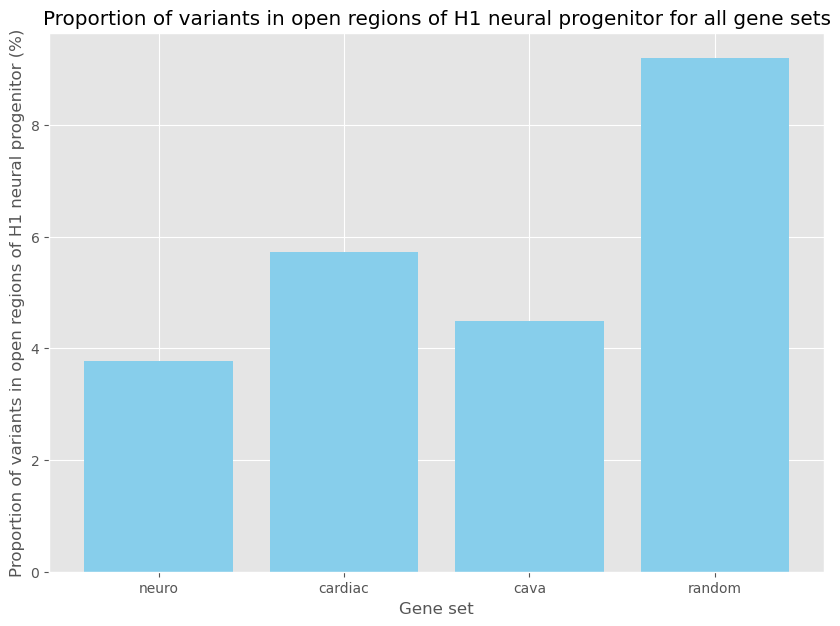

In [112]:
# check proportion of open regions for neuro specific
current_gene_set = "neuro"
neuro_specific_variants = tested_bcMPRAlm_df_metainfo_open_h1.loc[tested_bcMPRAlm_df_metainfo_open_h1['is_neuro']] # 16531
neuro_specific_variants.loc[neuro_specific_variants['h1_open'] == True].shape[0] # 623
print(f"Proportion of {current_gene_set} variants within open regions of neural progenitor: {round(neuro_specific_variants.loc[neuro_specific_variants['h1_open'] == True].shape[0]/neuro_specific_variants.shape[0] * 100,2)}%")
proportion_list = []
gene_set_list = ['neuro', 'cardiac', 'cava', 'random']
for gene_set in gene_set_list:
    proportion_list.append(print_proportion_of_open_h1_region(tested_bcMPRAlm_df_metainfo_open_h1, gene_set))

# proportion_list
# plot the proportion of open regions for all gene sets in percent
plt.figure(figsize=(10,7))
# change color to light blue
plt.bar(gene_set_list, proportion_list, color='skyblue')
plt.ylabel('Proportion of variants in open regions of H1 neural progenitor (%)')
plt.xlabel('Gene set')
plt.title('Proportion of variants in open regions of H1 neural progenitor for all gene sets')
plt.show()

In [124]:
623 + 667 + 295 + 320

1905

In [90]:
# check proportion of open regions for neuro specific significant effects

# find all region ids from the variant headers
neuro_significant_variants['region_id'] = neuro_significant_variants['variant_id'].apply(get_region_id)

neuro_significant_variants_h1 = neuro_significant_variants.merge(interesting_h1_df[['h1_region', 'h1_open']], left_on='region_id', right_on="h1_region", how='left')
print(f"Number of neuro specific significant variants: {neuro_significant_variants_h1.shape[0]}")
neuro_significant_variants_h1_open = neuro_significant_variants_h1.loc[~neuro_significant_variants_h1['h1_open'].isna()]
neuro_significant_variants_h1_open.shape[0]
print(f"Number of neuro specific significant variants which are open in H1 neuroal progenitor cells: {neuro_significant_variants_h1_open.shape[0]}")

print(f"Proportion of significant effects in regions open in neuron: {round(neuro_significant_variants_h1_open.shape[0]/neuro_significant_variants_h1.shape[0] * 100,2)}%")


/tmp/ipykernel_673798/1765421502.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuro_significant_variants['region_id'] = neuro_significant_variants['variant_id'].apply(get_region_id)


Number of neuro specific significant variants: 280
Number of neuro specific significant variants which are open in H1 neuroal progenitor cells: 17
Proportion of significant effects in regions open in neuron: 6.07%


In [ ]:
asdf breakpoint asdfasdf

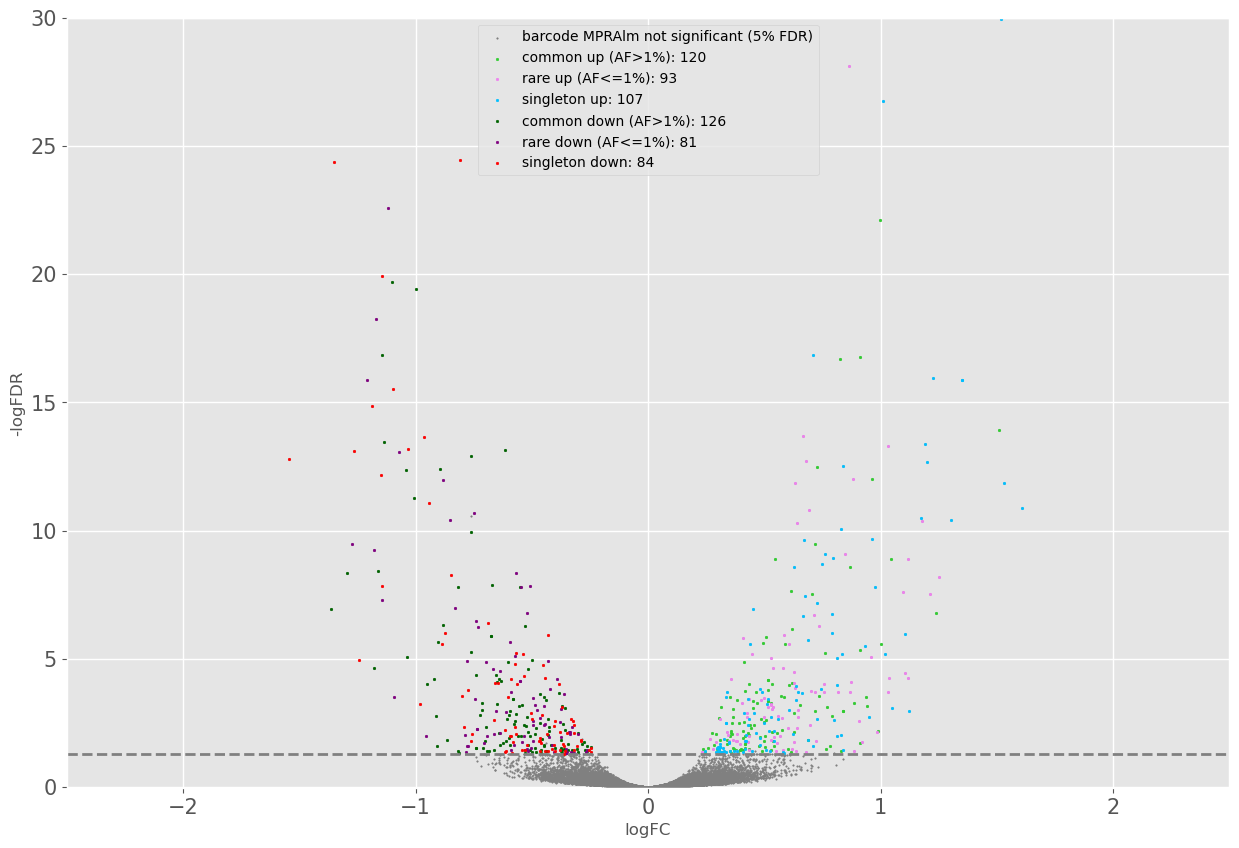

In [ ]:
# plot of different types of variants:
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=common_sig_up['logFC'],y=common_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common up (AF>1%): {common_sig_up.shape[0]}",color="limegreen")
plt.scatter(x=ultra_rare_sig_up['logFC'],y=ultra_rare_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare up (AF<=1%): {ultra_rare_sig_up.shape[0]}",color="violet")
plt.scatter(x=singleton_sig_up['logFC'],y=singleton_sig_up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton up: {singleton_sig_up.shape[0]}",color="deepskyblue")
plt.scatter(x=common_sig_down['logFC'],y=common_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"common down (AF>1%): {common_sig_down.shape[0]}",color="darkgreen")
plt.scatter(x=ultra_rare_sig_down['logFC'],y=ultra_rare_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"rare down (AF<=1%): {ultra_rare_sig_down.shape[0]}",color="purple")
plt.scatter(x=singleton_sig_down['logFC'],y=singleton_sig_down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"singleton down: {singleton_sig_down.shape[0]}",color="red")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
# plt.xlim(-4,4)
# plt.ylim(-0.025,4)
plt.xlim(-2.5,2.5)
plt.ylim(-0.025,30)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('bc_mpralm_41k_results.png', transparent=True)

In [ ]:
significant_variant_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,...,CHROM,POS,REF,ALT,QUAL,FILTER,INFO,gene_type,variant_type,abs_logFC
0,1.457088,1.858231,16.882487,1.903278e-54,6.668897e-50,111.743634,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,49.175946,positive,...,chr5,14408059,A,G,1,PASS,AF=6.57117e-06;AC=1,neuro,singleton,1.457088
1,1.606057,0.965378,12.629730,6.066106e-32,1.062751e-27,60.343637,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.973568,positive,...,chr2,219267001,T,C,1,PASS,AF=6.57566e-06;AC=1,random,singleton,1.606057
2,1.533407,0.920228,12.224316,2.321415e-30,2.711335e-26,56.886221,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.566817,positive,...,chr5,14259916,C,T,1,PASS,AF=0.0168281;AC=2558,neuro,rare,1.533407
3,0.861337,0.989619,11.188733,2.500592e-27,2.190456e-23,51.127418,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,22.659465,positive,...,chr3,142578095,C,G,1,PASS,AF=4.60054e-05;AC=7,cava,ultra-rare,0.861337
4,-1.407245,0.845364,-10.644525,6.085755e-24,4.264775e-20,42.725159,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.370104,negative,...,chr22,42115774,T,C,1,PASS,AF=6.57281e-06;AC=1,cava,singleton,1.407245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,0.346784,-0.160274,3.469248,5.556839e-04,4.966992e-02,-0.659838,cardiac_neuro_cava_random:MED13L|ENSG000001230...,MED13L|ENSG00000123066.9|EH38E3043648|12-11616...,1.303907,positive,...,chr12,116160435,C,T,1,PASS,AF=2.6295e-05;AC=4,cardiac,ultra-rare,0.346784
407,0.346784,-0.160274,3.469248,5.556839e-04,4.966992e-02,-0.659838,cardiac_neuro_cava_random:MED13L|ENSG000001230...,MED13L|ENSG00000123066.9|EH38E3043648|12-11616...,1.303907,positive,...,chr12,116160435,C,T,1,PASS,AF=2.6295e-05;AC=4,neuro,ultra-rare,0.346784
410,0.358435,-0.316231,3.470095,5.509918e-04,4.963034e-02,-0.670543,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,IRF4|ENSG00000137265.16|EH38E2438412|6-405889-C-T,1.304253,positive,...,chr6,405889,C,T,1,PASS,AF=0.0192788;AC=2934,cava,rare,0.358435
419,-0.297921,-0.059217,-3.477754,5.314980e-04,4.849781e-02,-0.758377,cardiac_neuro_cava_random:CUL3|ENSG00000036257...,CUL3|ENSG00000036257.14|EH38E2079109|2-2245462...,1.314278,negative,...,chr2,224546256,A,T,1,PASS,AF=0.746252;AC=113387,neuro,common,0.297921


In [ ]:
neuro = significant_variant_table[significant_variant_table['gene_type'] == 'neuro'] # 159
cardiac = significant_variant_table[significant_variant_table['gene_type'] == 'cardiac'] # 159
cava = significant_variant_table[significant_variant_table['gene_type'] == 'cava'] # 159
random = significant_variant_table[significant_variant_table['gene_type'] == 'random'] # 159
# neuro = merged_up[merged_up['gene_type'] == 'neuro'] # 159
# cardiac = merged_up[merged_up['gene_type'] == 'cardiac'] # 159
# cava = merged_up[merged_up['gene_type'] == 'cava'] # 159
# random = merged_up[merged_up['gene_type'] == 'random'] # 159
# ultra_rare_sig_up = merged_up[merged_up['variant_type'] == 'ultra-rare'] # 112
# singleton_sig_up = merged_up[merged_up['variant_type'] == 'singleton'] # 130
# common_sig_down = merged_down[merged_down['variant_type'].apply(is_common)] # 159
# ultra_rare_sig_down = merged_down[merged_down['variant_type'] == 'ultra-rare'] # 112
# singleton_sig_down = merged_down[merged_down['variant_type'] == 'singleton'] # 130

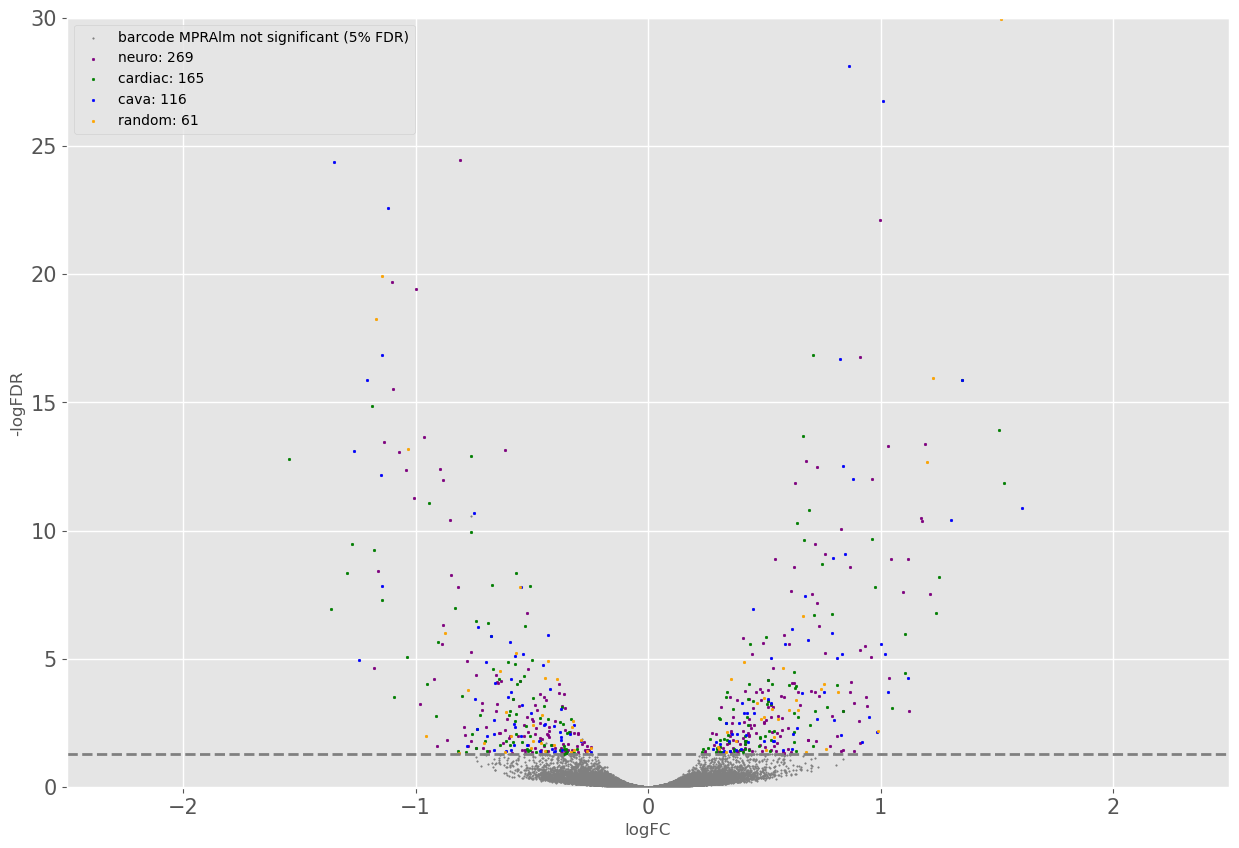

In [ ]:
# plot of different types of variants: cardiac neuro random
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
plt.scatter(x=neuro['logFC'],y=neuro['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"neuro: {neuro.shape[0]}",color="purple")
plt.scatter(x=cardiac['logFC'],y=cardiac['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"cardiac: {cardiac.shape[0]}",color="green")
plt.scatter(x=cava['logFC'],y=cava['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"cava: {cava.shape[0]}",color="blue")
plt.scatter(x=random['logFC'],y=random['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label=f"random: {random.shape[0]}",color="orange")
# scatter for controls
# plt.scatter()


# Keep x-axis between -4, 4
# keep y-axis between 0, 4
plt.xlim(-4,4)
plt.ylim(-0.025,4)
plt.xlim(-2.5,2.5)
plt.ylim(-0.025,30)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.savefig('mpralm_41k_results.png', transparent=True)

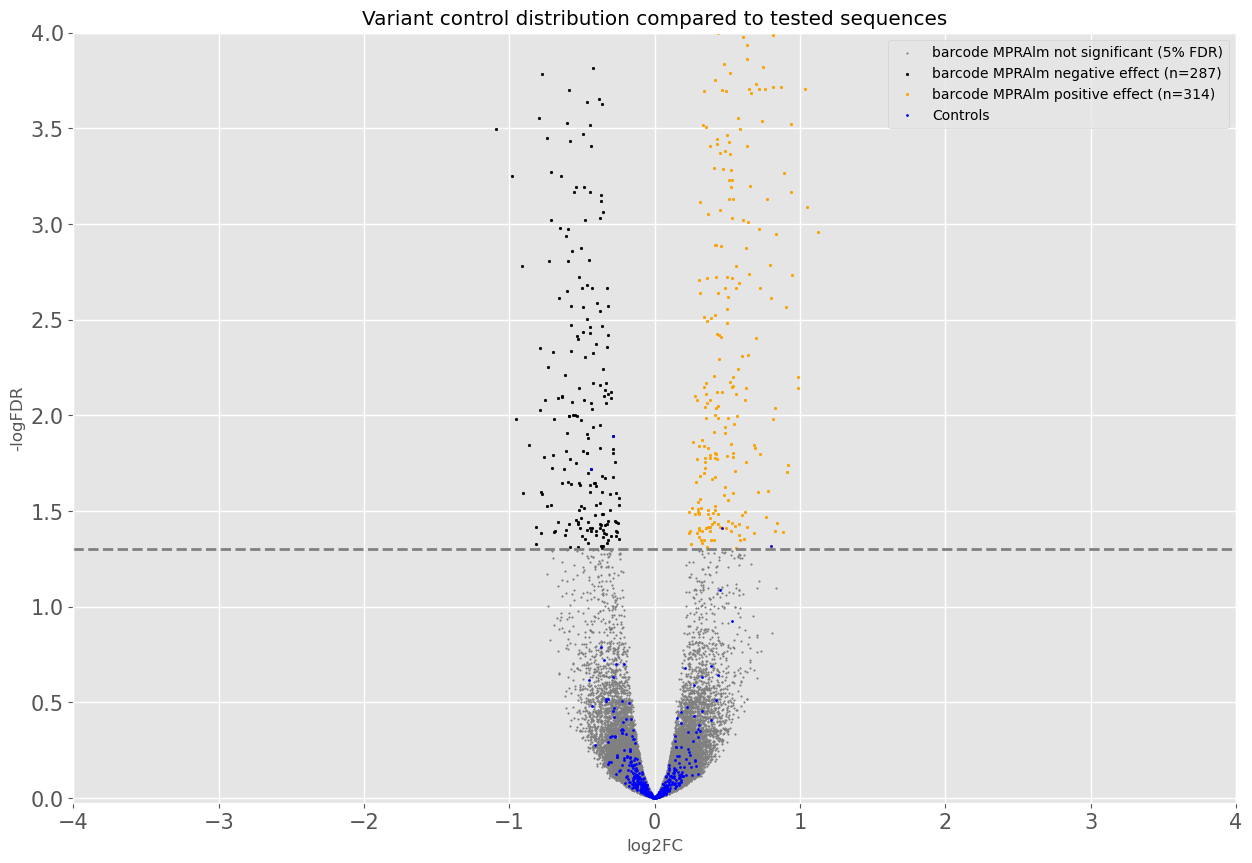

In [ ]:
# make vulcano plot with coloring only controls special
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
# plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant (>{int(round(significants_niveau*100, 2))}% FDR)", color='red')
plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color='gray')
plt.scatter(x=down['logFC'],y=down['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="barcode MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
plt.scatter(x=up['logFC'],y=up['adj.P.Val'].apply(lambda x:-np.log10(x)),s=3,label="barcode MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
# scatter for controls
plt.scatter(x=controls['logFC'],y=controls['adj.P.Val'].apply(lambda x:-np.log10(x)),s=2,label="Controls", color='blue')


# modify plot
plt.xlim(-4,4)
plt.ylim(-0.025,4)
# plt.xlim(-2.5,2.5)
# plt.ylim(-0.025,30)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.title("Variant control distribution compared to tested sequences")
plt.xlabel("log2FC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.show()

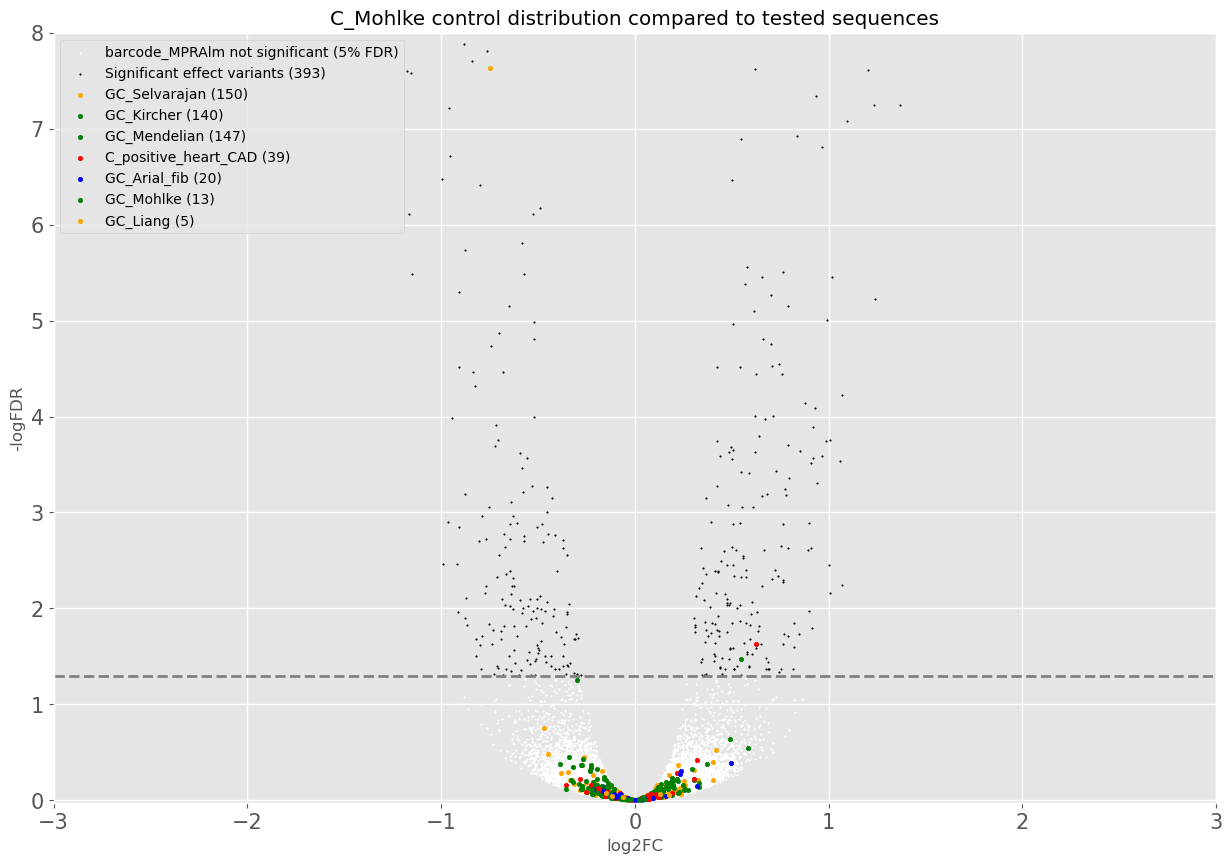

In [ ]:
# make vulcano plot with coloring only controls special
plt.figure(figsize=(15,10))
# make background dark for the plot
# plt.style.use('dark_background')
plt.style.use("Solarize_Light2")
plt.style.use("ggplot")

plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"barcode_MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color='white')
plt.scatter(x=significant_bcMPRAlm_table['logFC'],y=significant_bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,label=f"Significant effect variants ({significant_bcMPRAlm_table.shape[0]})", color='black')
# scatter for controls
control_dot_size = 10
# plt.scatter(x=controls['logFC'],y=controls['adj.P.Val'].apply(lambda x:-np.log10(x)),s=2,label=f"Controls ({controls.shape[0]})", color='blue')
# plt.scatter(x=c_liang['logFC'],y=c_liang['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Liang", color='orange')
# plt.scatter(x=c_selvarajan['logFC'],y=c_selvarajan['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="GC_Selvarajan", color='orange')
# plt.scatter(x=c_positive_heart_CAD['logFC'],y=c_positive_heart_CAD['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_positive_heart_CAD", color='red')
# plt.scatter(x=c_arial_fib['logFC'],y=c_arial_fib['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_Arial_fib", color='blue')
# plt.scatter(x=c_mohlke['logFC'],y=c_mohlke['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label="C_Mohlke", color='green')
plt.scatter(x=c_selvarajan['logFC'],y=c_selvarajan['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Selvarajan ({c_selvarajan.shape[0]})", color='orange')
plt.scatter(x=c_kircher['logFC'],y=c_kircher['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Kircher ({c_kircher.shape[0]})", color='green')
plt.scatter(x=c_mendelian['logFC'],y=c_mendelian['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Mendelian ({c_mendelian.shape[0]})", color='green')
plt.scatter(x=c_positive_heart_CAD['logFC'],y=c_positive_heart_CAD['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"C_positive_heart_CAD ({c_positive_heart_CAD.shape[0]})", color='red')
plt.scatter(x=c_arial_fib['logFC'],y=c_arial_fib['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Arial_fib ({c_arial_fib.shape[0]})", color='blue')
plt.scatter(x=c_mohlke['logFC'],y=c_mohlke['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Mohlke ({c_mohlke.shape[0]})", color='green')
plt.scatter(x=c_liang['logFC'],y=c_liang['adj.P.Val'].apply(lambda x:-np.log10(x)),s=control_dot_size,label=f"GC_Liang ({c_liang.shape[0]})", color='orange')

# modify plot
# plt.xlim(-4,4)
# plt.ylim(-0.025,4)
plt.xlim(-3,3)
plt.ylim(-0.025,8)
# increase font size
plt.rcParams.update({'font.size': 15})
# increase font size of labels and ticks
plt.tick_params(axis='both', which='major', labelsize=15)
# plt.style.use('dark_background')
# plt.style.use("Solarize_Light2")
plt.style.use("ggplot")
plt.title("C_Mohlke control distribution compared to tested sequences")
# plt.title("Variant control distribution compared to tested sequences")
plt.xlabel("log2FC")
plt.ylabel("-logFDR")
plt.axhline(1.3,color="grey",linestyle="--")
plt.legend()

plt.show()


#### Controls
- investigate log2ratios of RNA/DNA for all sequences (not yet summarized over replicates)
- control list with counts:
  - MK                                     6568
  - C_positive_heart_AB                    2184
  - GC_Selvarajan                          1062
  - GC_Vista                                708
  - C_negative_heart_MK                     696
  - GC_Mendelian_variants                   612
  - C_negative_neuron_MK                    607
  - GC_Cort_Chengyu                         555
  - GC_Kircher                              547
  - C_SLEA                                  532
  - C_negative_neuron_NP                    507
  - C_positive_neuron_MK                    288
  - C_positive_neuron_NP                    283
  - C_positive_heart_CAD                    273
  - C_positive_heart_MK                     271
  - C_positive_neuron_CD                    261
  - GC_GABA_Chengyu                         214
  - GC_DNase_positive_shuffeled             159
  - GC_Atrial_fib                           135
  - GC_DNase_positive                       123
  - GC_Glut_Chengyu                          96
  - GC_Mohlke                                93
  - GC_DNase_negative_blood_shuffeled        54
  - GC_DNase_negative_brain_shuffeled        48
  - GC_Liang                                 48
  - GC_DNase_negative_blood                  45
  - GC_DNase_negative_brain                  45
  - GC_Hon                                   18

In [ ]:
# investigate number of variant controls
controls_variant_map_path = config['files']['final_design']['variant_region_map_controls']
controls_variant_map = pd.read_csv(controls_variant_map_path, sep="\t")
controls_variant_map['label'] = controls_variant_map['Variant'].apply(get_label)
pd.DataFrame(controls_variant_map.groupby('label').size(), columns=['count']).reset_index()

,label,count
0,C_positive_heart_CAD,49
1,GC_Atrial_fib,23
2,GC_Kircher,198
3,GC_Liang,8
4,GC_Mendelian_variants,174
5,GC_Mohlke,20
6,GC_Selvarajan,198


In [ ]:
config

{'files': {'output': {'plotting': '/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/80K_MPRA/plots/'},
  'creating': {'name_header_match': '/home/kisa/coding/80K_MPRA/80K-Analysis/05_variant_region_list/resources/id_matching_table.tsv',
   'metadata_table': '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/05_variant_region_list/resources/IGVF_metadata_table.tsv',
   'old_metadata_table': '/home/kisa/coding/80K_MPRA/80K-Analysis/05_variant_region_list/metadata_example_1903.tsv',
   'bc_MPRAlm': '/home/kisa/coding/80K_MPRA/server_results/bc_MPRAlm/toptable_GC_Selvarajan_standardNGN2.tsv',
   'control_allele_barcode_table': '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/standard_with_controls_NGN2_filtered_counts_sequences.tsv.gz',
   'toptable_bcMPRAlm': '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_MPRAlm/test_controls_concat/toptable_standard_with_variant_controls_no_downsamplingNGN2.

In [ ]:
# investigate number after filtering based on barcodes of allels (alt/ref)
control_allele_barcodes = config['files']['creating']['allele_barcode_table']
# control config['files']['creating']['control_allele_barcode_table']
c_allele_barcode_table = pd.read_csv(control_allele_barcodes, sep="\t")
c_allele_barcode_table['label'] = c_allele_barcode_table['variant_id'].apply(get_label)
pd.DataFrame(c_allele_barcode_table.groupby('label').size(), columns=['count']).reset_index()

KeyError: 'allele_barcode_table'

In [ ]:
log_ratio_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_merged.tsv.gz"
log_ratio = pd.read_csv(log_ratio_path, sep="\t")
log_ratio['tmp_label'] = log_ratio['name'].apply(get_label)
log_ratio['tmp_is_control'] = log_ratio['name'].apply(is_control)
# remove no_BC row
log_ratio = log_ratio[log_ratio['name'] != 'no_BC']
log_ratio # 224010

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,tmp_label,tmp_is_control
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.044034,0.062169,106,C_SLEA,True
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.330882,1.220876,99,C_SLEA,True
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.137747,0.186180,68,C_SLEA,True
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.221316,0.288437,89,C_SLEA,True
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.018761,0.026816,54,C_SLEA,True
...,...,...,...,...,...,...,...,...,...,...,...,...
224007,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,29,24,0.087365,0.032066,0.384755,-1.377988,12,cardiac_neuro_cava_random,False
224008,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.073894,1.052342,75,cardiac_neuro_cava_random,False
224009,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.370895,0.455118,26,cardiac_neuro_cava_random,False
224010,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.673786,-0.569638,29,cardiac_neuro_cava_random,False


In [ ]:
log_ratio_controls = log_ratio[log_ratio['tmp_is_control']]
tested_seqs_log_ratio = log_ratio[~log_ratio['tmp_is_control']]
# groups of controls:
all_control_groups = log_ratio_controls['tmp_label'].unique()
all_control_groups
# all controls with DNase in the name used wrong coordinates in this design
wrong_coordinates_groups = [x for x in all_control_groups if "DNase" in x]
# positive controls (should show activity) (TODO: verify with MPRAlm if other controls could be used as positive controls)
# simple filter: all have "positive_neuron" in name
positive_control_groups = [x for x in all_control_groups if "positive_neuron" in x]

# negative controls (should not show activity) (negative neuron)
negative_control_groups = [x for x in all_control_groups if "negative_neuron" in x]
negative_control_groups
# #all controls with variants
# variant_control_groups = ['C_positive_heart_CAD', 'GC_Atrial_fib', 'GC_Kircher', 'GC_Liang', 'GC_Mendelian_variants', 'GC_Mohlke', 'GC_Selvarajan']

shuffled_control_groups = [x for x in all_control_groups if "shuffeled" in x]

# IGVF controls:
igvf_controls = [x for x in all_control_groups if 'GC_' in x]
igvf_controls

other_controls = [x for x in all_control_groups if x not in igvf_controls and x not in positive_control_groups and x not in negative_control_groups]
other_controls
# interesting because relevant to neural or results of previous work
# interesting_controls = ['C_SLEA', 'C_positive_neuron_CD', 'GC_Atrial_fib', 'GC_Kircher', 'GC_Liang', 'GC_Mendelian_variants', 'GC_Mohlke', 'GC_Selvarajan']

['C_SLEA',
 'C_negative_heart_MK',
 'C_positive_heart_AB',
 'C_positive_heart_CAD',
 'C_positive_heart_MK',
 'MK']

In [ ]:
log_ratio['tmp_label'].value_counts()

tmp_label
cardiac_neuro_cava_random            206978
MK                                     6568
C_positive_heart_AB                    2184
GC_Selvarajan                          1062
GC_Vista                                708
C_negative_heart_MK                     696
GC_Mendelian_variants                   612
C_negative_neuron_MK                    607
GC_Cort_Chengyu                         555
GC_Kircher                              547
C_SLEA                                  532
C_negative_neuron_NP                    507
C_positive_neuron_MK                    288
C_positive_neuron_NP                    283
C_positive_heart_CAD                    273
C_positive_heart_MK                     271
C_positive_neuron_CD                    261
GC_GABA_Chengyu                         214
GC_DNase_positive_shuffeled             159
GC_Atrial_fib                           135
GC_DNase_positive                       123
GC_Glut_Chengyu                          96
GC_Mohlke             

In [ ]:
positive_control_groups = ['C_positive_neuron_NP', 'C_positive_neuron_MK', 'C_positive_neuron_CD']
synthetic_control_groups = ['C_SLEA']
wrong_coordinates_groups = [group for group in all_control_groups if "dnase" in group.lower()] # add information that these used wrong coordinates

other_control_groups = [group for group in all_control_groups if not group in positive_control_groups]

##### Mohan normalization: take for the group you are interested the median

In [ ]:
log_ratio

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,tmp_label,tmp_is_control
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.044034,0.062169,106,C_SLEA,True
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.330882,1.220876,99,C_SLEA,True
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.137747,0.186180,68,C_SLEA,True
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.221316,0.288437,89,C_SLEA,True
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.018761,0.026816,54,C_SLEA,True
...,...,...,...,...,...,...,...,...,...,...,...,...
224007,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,29,24,0.087365,0.032066,0.384755,-1.377988,12,cardiac_neuro_cava_random,False
224008,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.073894,1.052342,75,cardiac_neuro_cava_random,False
224009,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.370895,0.455118,26,cardiac_neuro_cava_random,False
224010,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.673786,-0.569638,29,cardiac_neuro_cava_random,False


##### positive controls:

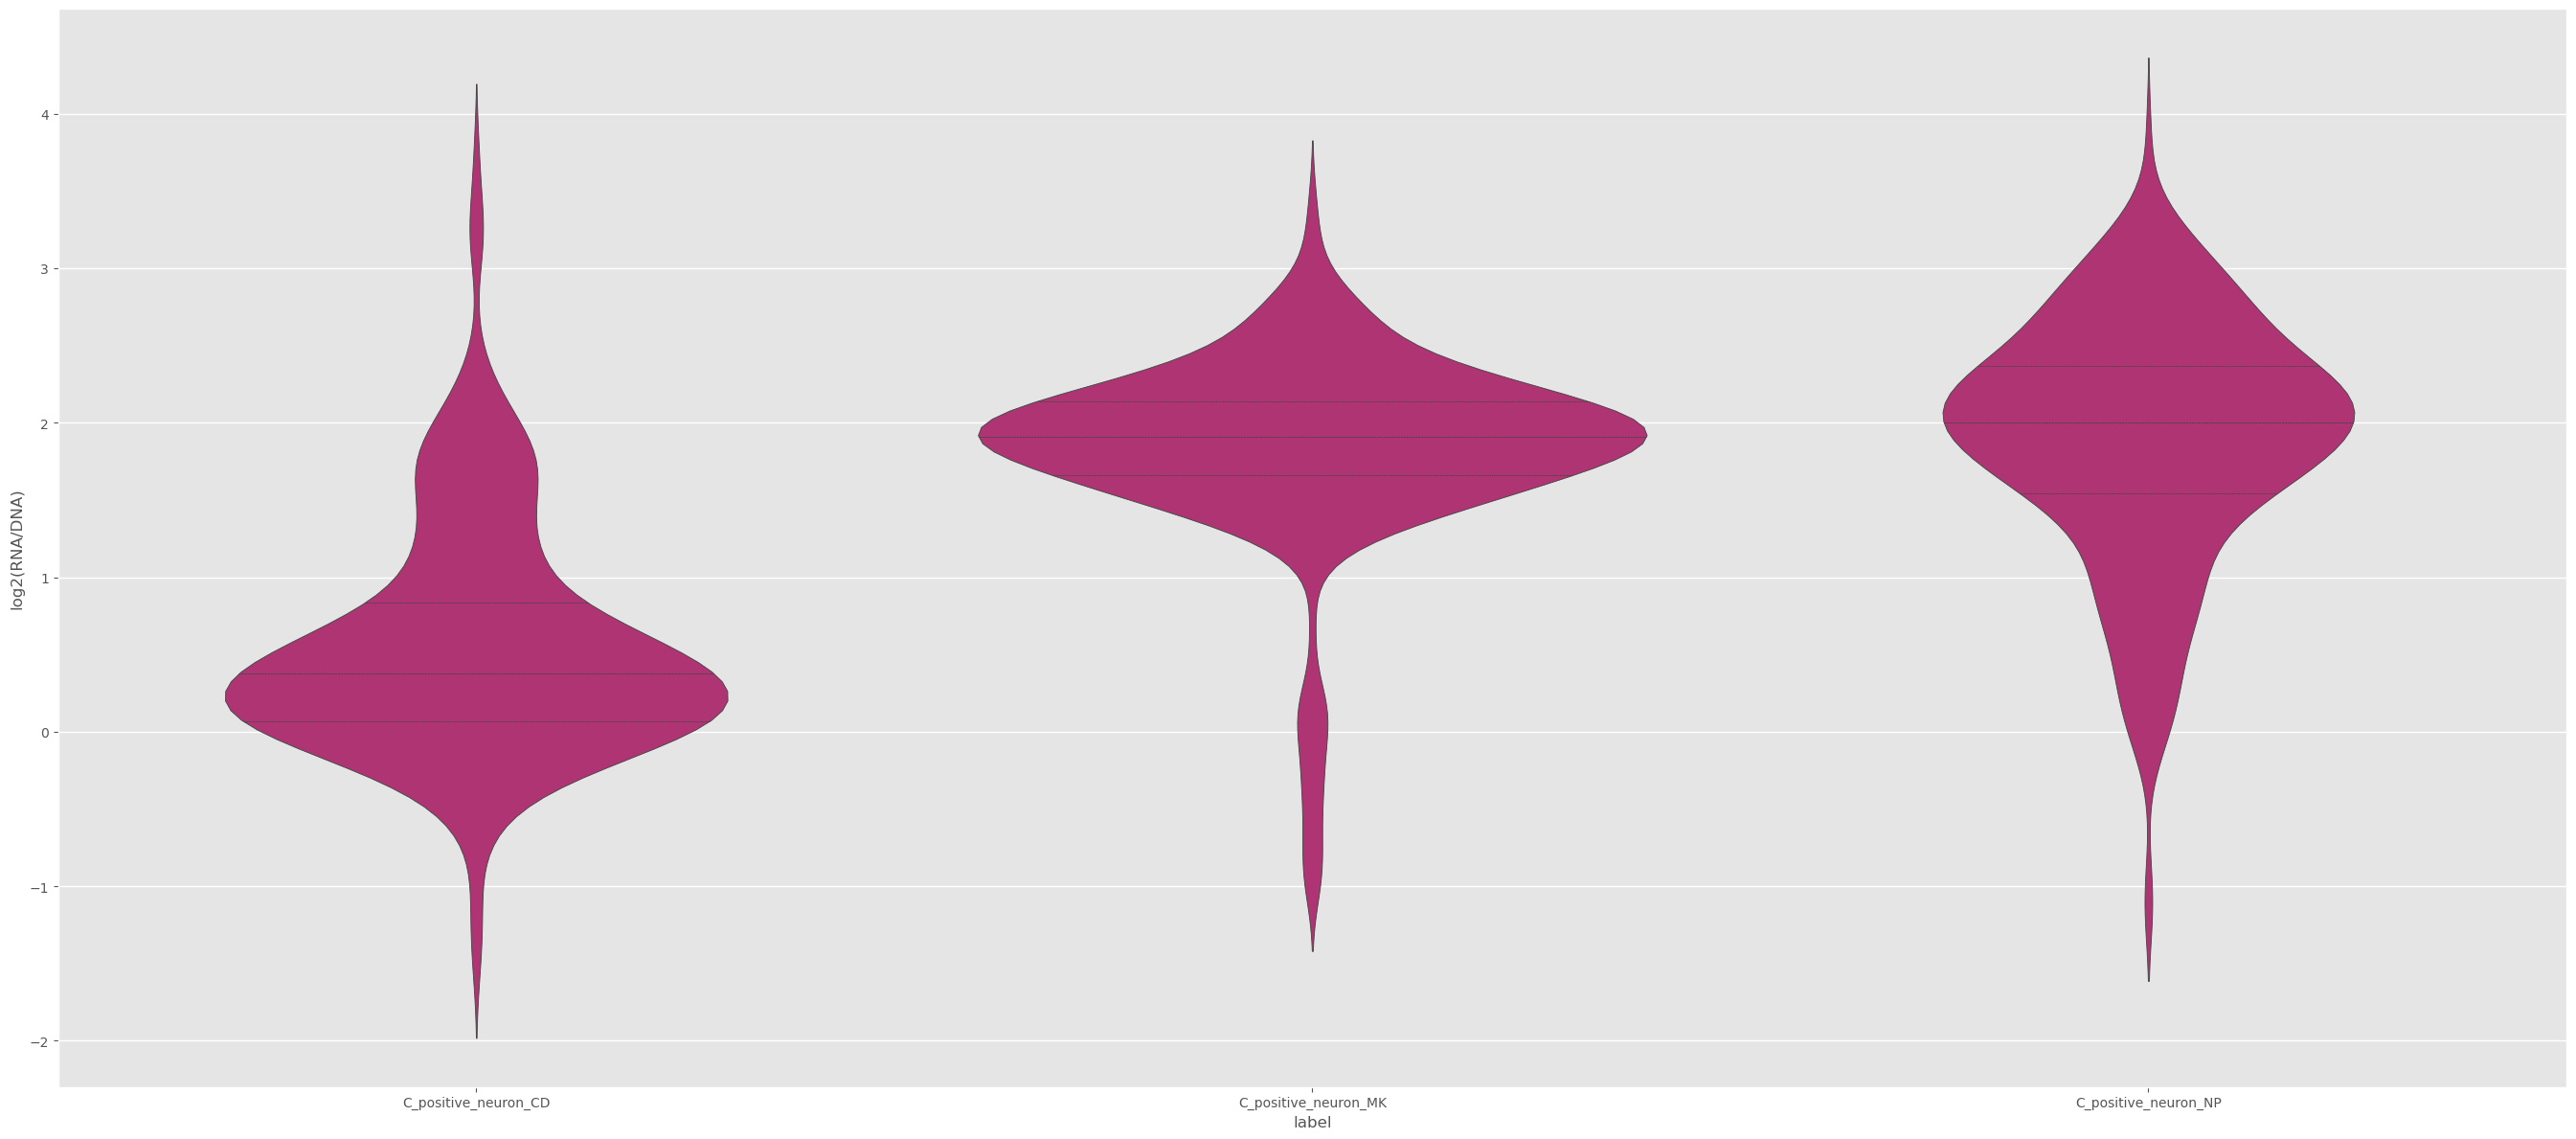

In [ ]:
violin_log2_data = log_ratio[log_ratio['tmp_label'].isin(positive_control_groups)][['tmp_label', 'log2']]
# violin plot (of log2 of controls)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='tmp_label', y='log2', data=violin_log2_data, ax=ax, color='#c22075', inner='quartile')
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('log2(RNA/DNA)')

# ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
# plt.savefig('violinplot_normalized.png', dpi=600)
plt.show()

##### negative controls

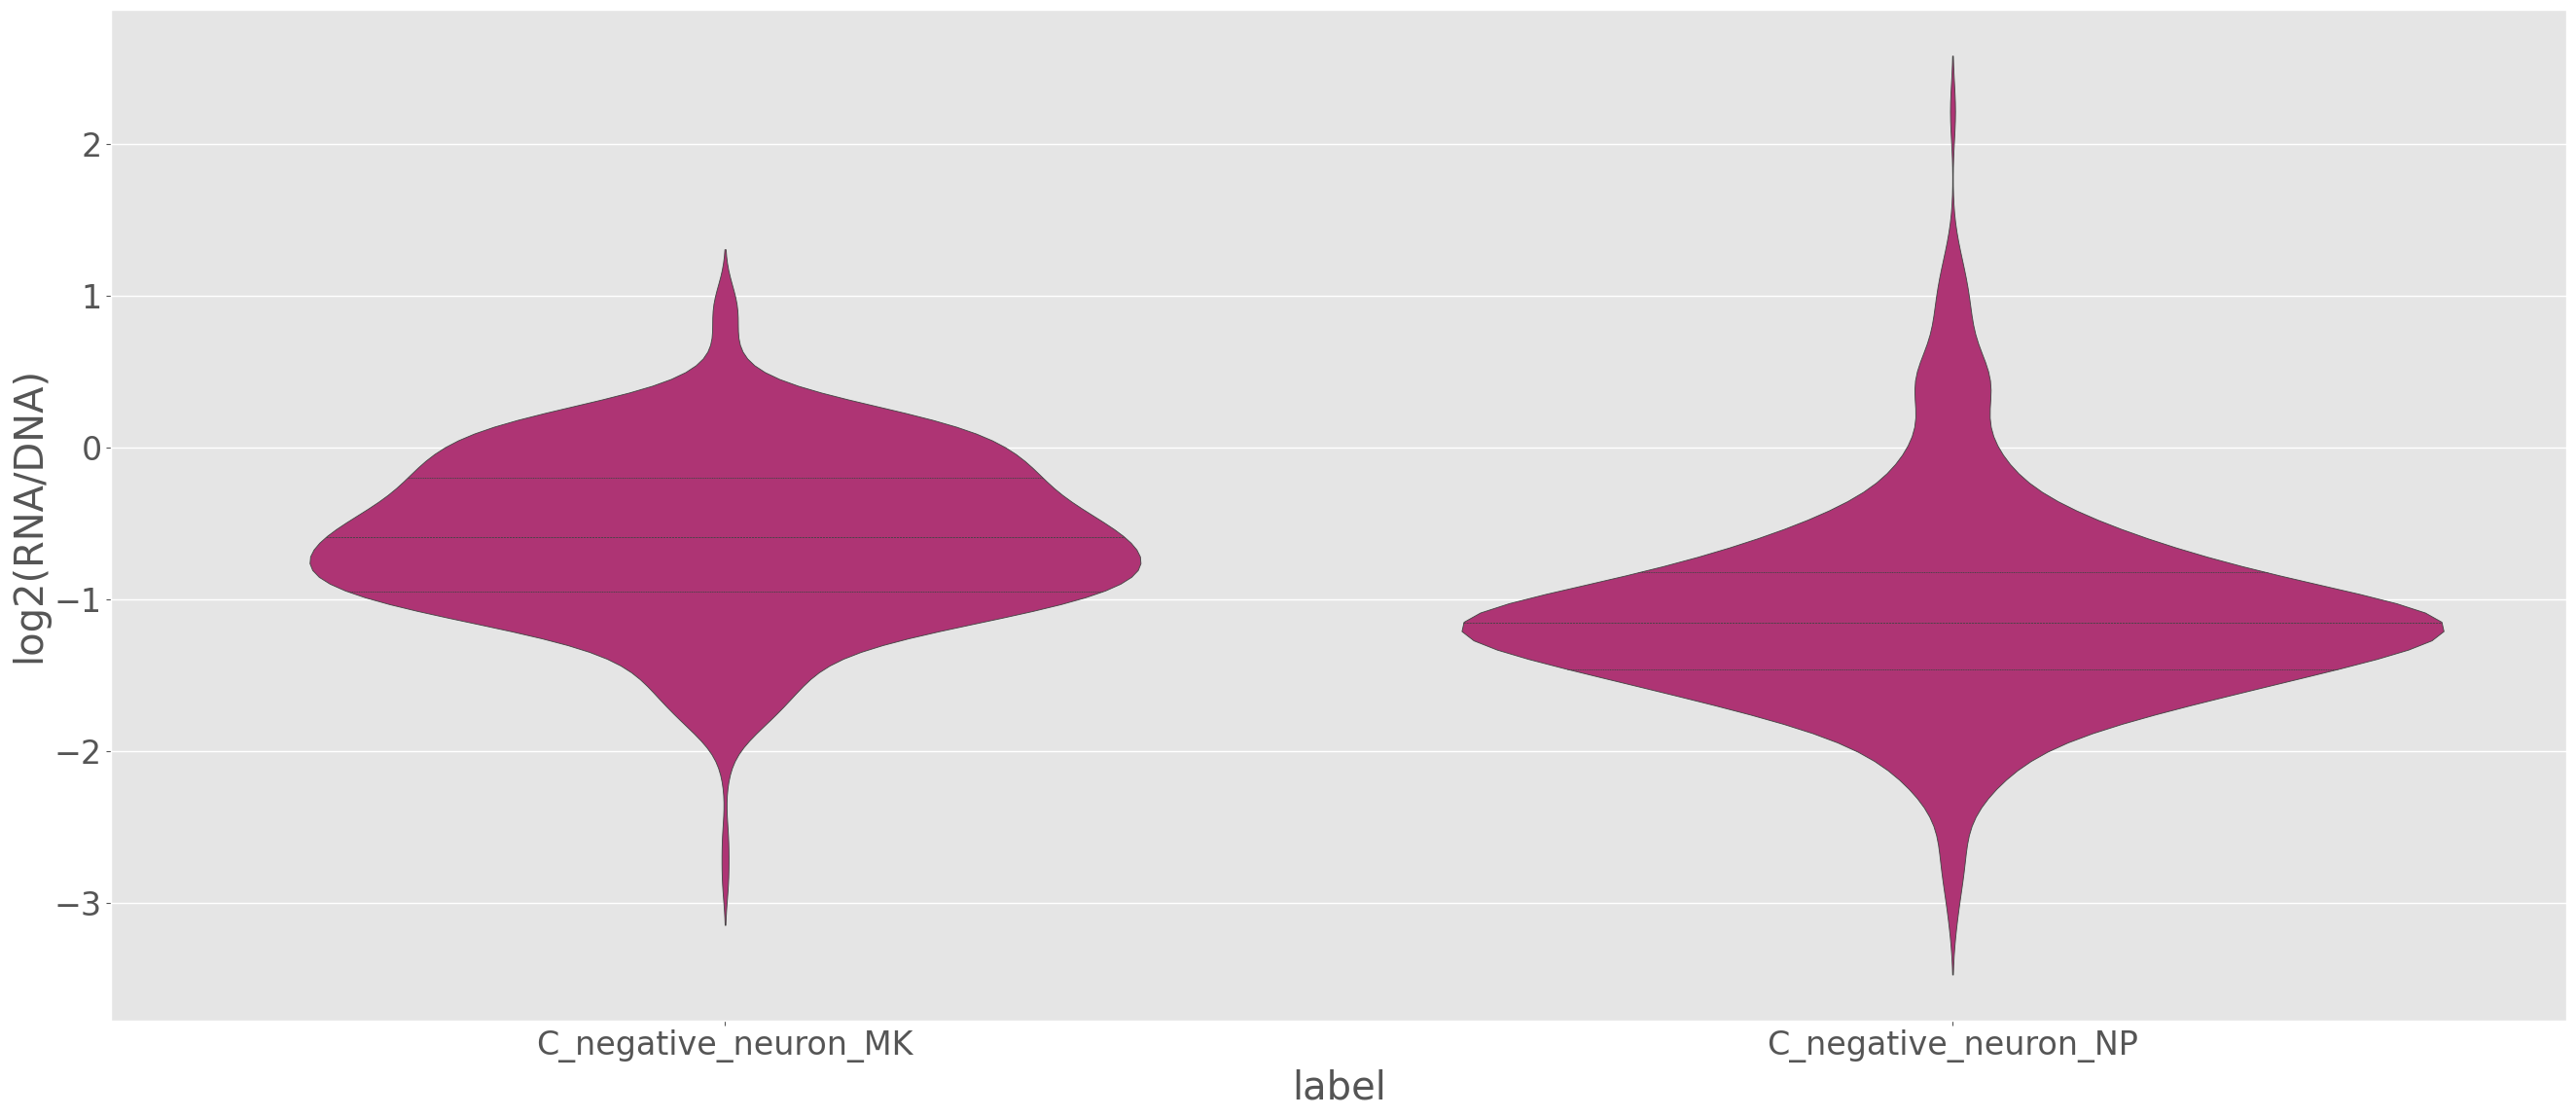

In [ ]:
violin_log2_data = log_ratio[log_ratio['tmp_label'].isin(negative_control_groups)][['tmp_label', 'log2']]
# violin plot (of log2 of controls)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='tmp_label', y='log2', data=violin_log2_data, ax=ax, color='#c22075', inner='quartile')
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('log2(RNA/DNA)')
# ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
# plt.savefig('violinplot_normalized.png', dpi=600)
plt.show()

##### comparing

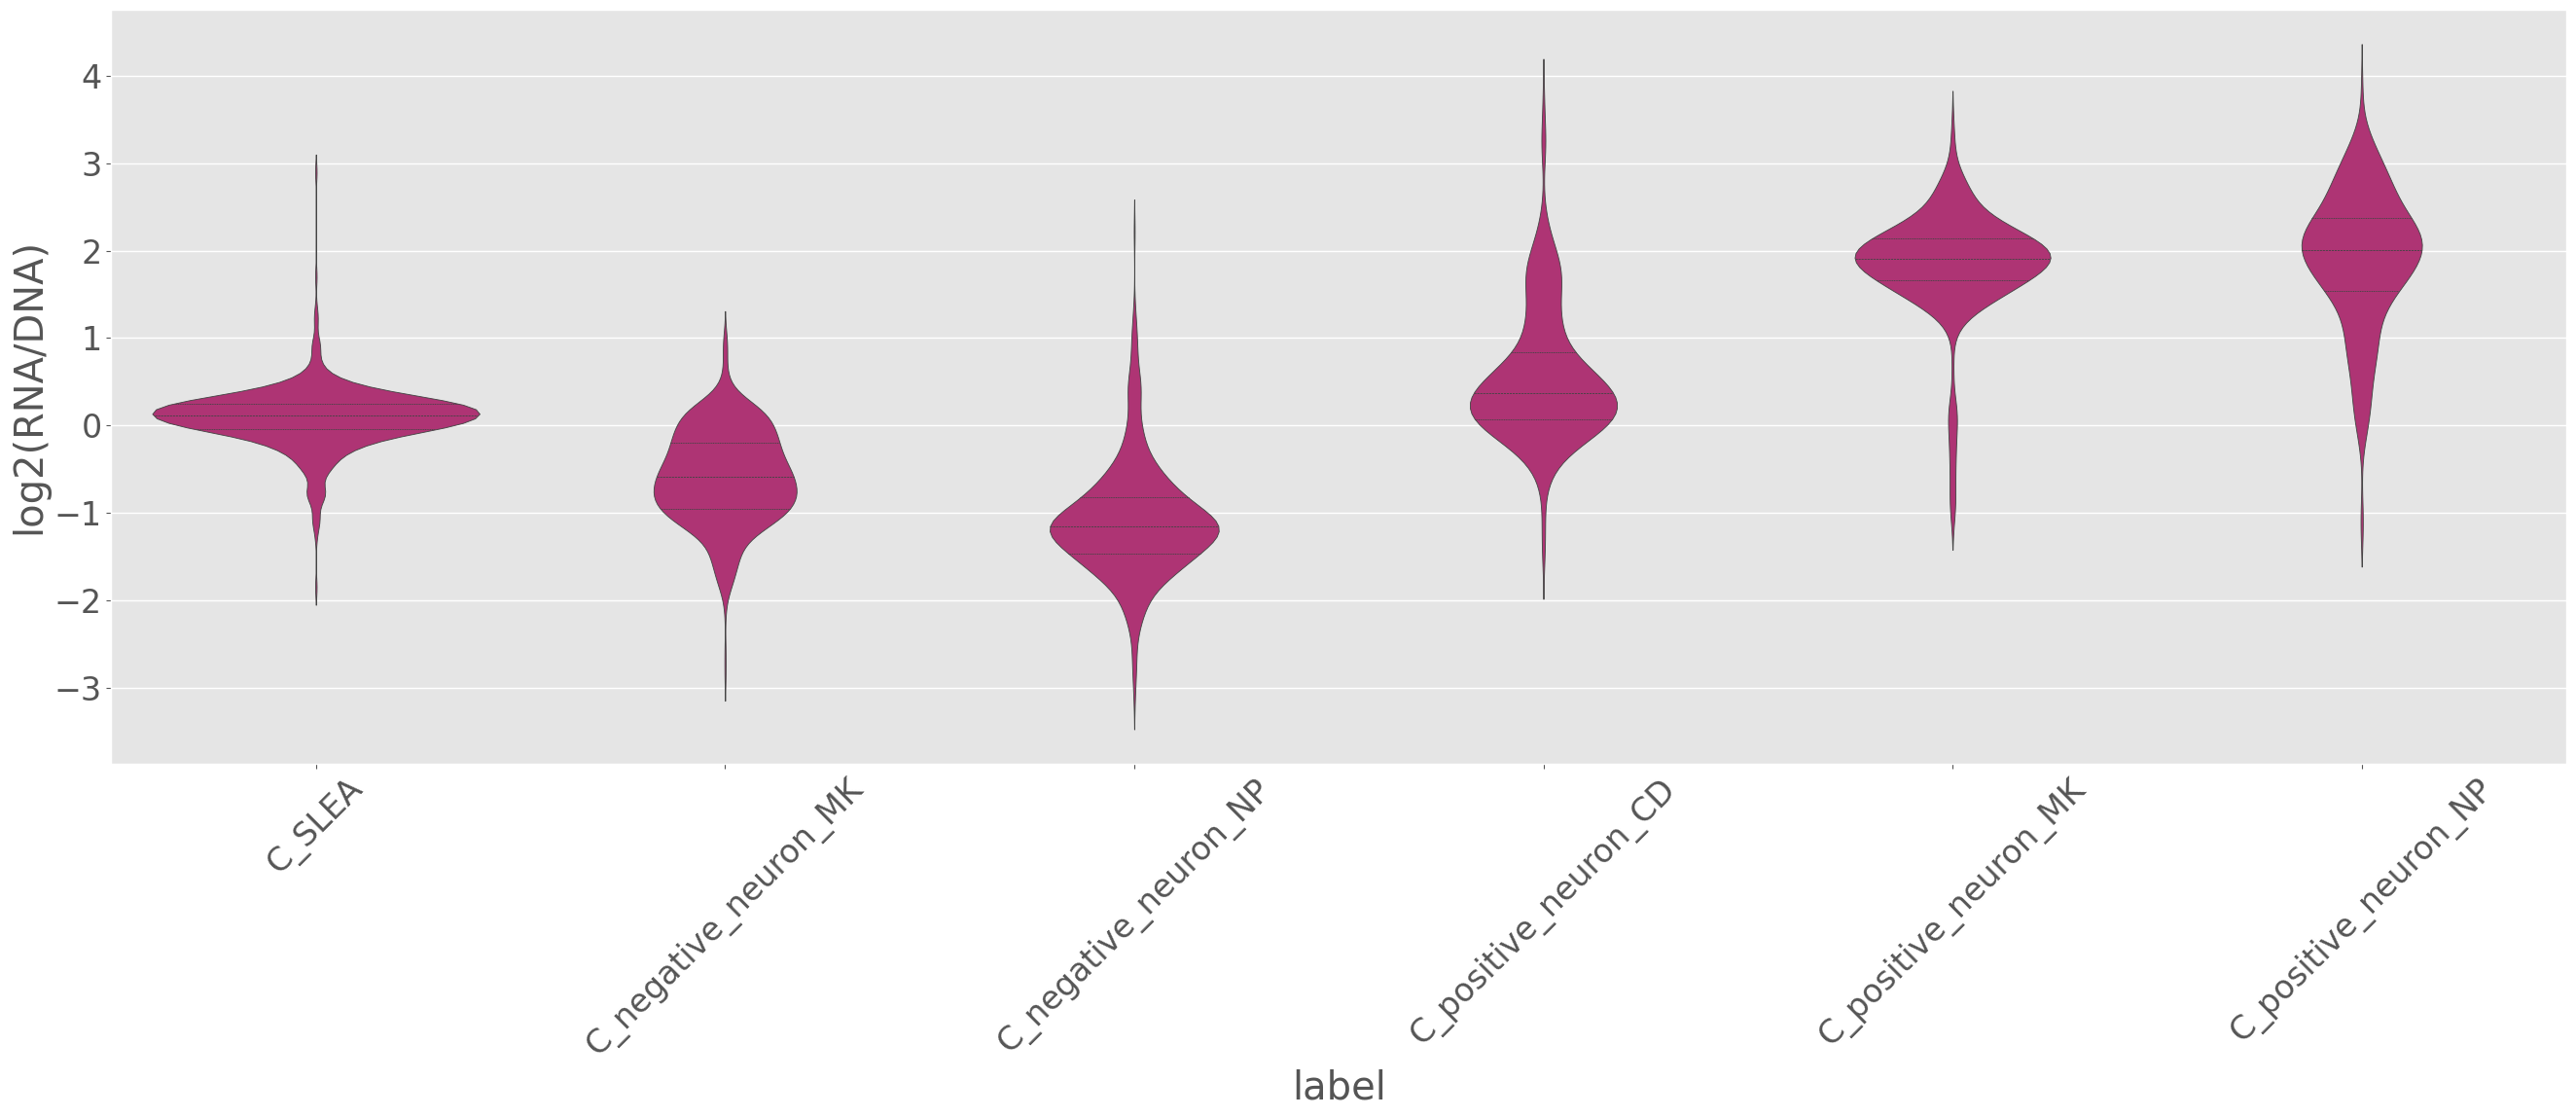

In [ ]:
violin_log2_data = log_ratio[log_ratio['tmp_label'].isin(positive_control_groups + negative_control_groups + ['C_SLEA'])][['tmp_label', 'log2']]
# violin plot (of log2 of controls)
fig, ax = plt.subplots(figsize=(27,12))
sns.violinplot(x='tmp_label', y='log2', data=violin_log2_data, ax=ax, color='#c22075', inner='quartile')
# axis labels
ax.set_xlabel('label')
ax.set_ylabel('log2(RNA/DNA)')
# ax.set_ylabel('normalized log2(RNA/DNA)')
plt.xticks(rotation=45)
plt.tight_layout()

# increase font size
plt.rcParams.update({'font.size': 24})
# save plot as png, 600dpi
# plt.savefig('violinplot_normalized.png', dpi=600)
plt.show()


In [ ]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,48.957326,interesting_high_log2fc,#377eb8
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.717150,interesting_high_log2fc,#377eb8
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.271528,interesting_high_log2fc,#377eb8
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,23.511906,interesting_low_pvalue,#377eb8
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.160623,interesting_high_log2fc,#377eb8
...,...,...,...,...,...,...,...,...,...,...,...
41459,0.001067,0.148021,0.013399,9.893122e-01,9.985585e-01,-6.737826,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997228|2-503360...,0.000627,uninteresting_low_log2fc,#377eb8
41460,-0.000931,0.030328,-0.011657,9.907019e-01,9.986675e-01,-6.737838,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...,0.000579,uninteresting_low_log2fc,#377eb8
41461,-0.000932,0.096385,-0.011486,9.908387e-01,9.986675e-01,-6.737840,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542473-T-C,0.000579,uninteresting_low_log2fc,#377eb8
41462,-0.000303,0.242820,-0.003851,9.969282e-01,9.996025e-01,-6.737858,cardiac_neuro_cava_random:DAOA|ENSG00000182346...,DAOA|ENSG00000182346.22|EH38E3079721|13-105499...,0.000173,uninteresting_low_log2fc,#377eb8


In [ ]:
bcMPRAlm_table['is_control'] = bcMPRAlm_table.apply(is_control, axis=1)

In [ ]:
bcbcMPRAlm_table_control = bcMPRAlm_table[bcMPRAlm_table["is_control"]]
bcbcMPRAlm_table_control

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,mpralm_true,is_control
38,-0.746661,0.617270,-6.789215,2.815750e-11,2.993647e-08,15.192563,GC_Selvarajan:rs1680636_tile1,rs1680636_tile1,7.523799,negative,True
693,0.844633,-0.033200,2.938038,3.589229e-03,1.955635e-01,-1.923092,GC_Selvarajan:rs1965983_tile1,rs1965983_tile1,0.708712,neutral,True
839,0.783773,-0.013252,2.769258,5.988302e-03,2.549270e-01,-2.321256,GC_Selvarajan:rs11084922_tile1,rs11084922_tile1,0.593584,neutral,True
849,-0.344149,-0.477969,-2.911165,3.738219e-03,1.989866e-01,-2.338997,GC_Selvarajan:rs12444333,rs12444333,0.701176,neutral,True
1208,0.422771,-0.190643,2.604528,9.552587e-03,3.151062e-01,-2.892135,GC_Selvarajan:rs2250645,rs2250645,0.501543,neutral,True
...,...,...,...,...,...,...,...,...,...,...,...
40548,-0.013047,0.149248,-0.142518,8.867091e-01,9.878068e-01,-6.621531,GC_Selvarajan:rs4846913_tile1,rs4846913_tile1,0.005328,neutral,True
41046,0.017453,-0.010929,0.211467,8.325746e-01,9.798133e-01,-6.685977,GC_Selvarajan:rs11674226_tile1,rs11674226_tile1,0.008857,neutral,True
41300,0.009792,0.080754,0.126151,8.996421e-01,9.897256e-01,-6.725342,GC_Selvarajan:rs2625259_tile2,rs2625259_tile2,0.004485,neutral,True
41335,0.010403,0.119036,0.132052,8.949741e-01,9.889736e-01,-6.728980,GC_Selvarajan:rs2625259_tile3,rs2625259_tile3,0.004815,neutral,True


In [ ]:
bcMPRAlm_table['color'] = bcMPRAlm_table[['logFC', 'variant_id', 'nlog10']].apply(map_color_precise, axis=1)
bcMPRAlm_table['color'].value_counts()

# more precise split (interesting: abs(log2fc) >= 1 and nlog10 >= 2
# uninteresting_low_log2fc    40930
# interesting_low_pvalue        191
# interesting_high_log2fc       163

# normal split (interesting: abs(log2fc) >= 1 or nlog10 >= 2)
# color
# uninteresting    40930
# interesting        354

# interesting: abs(log2fc) >= 0.5 or nlog10 >= 2
# color
# uninteresting_low_log2fc    39428
# interesting_high_log2fc      1816
# interesting_low_pvalue         40

# => interesing 1856 variants

#
# http://localhost:8888/tree?token=2c5277b673e1069ca905260d17529bb763643def53e8ed56 228

color
uninteresting_low_log2fc    41111
interesting_low_pvalue        191
interesting_high_log2fc       162
Name: count, dtype: int64

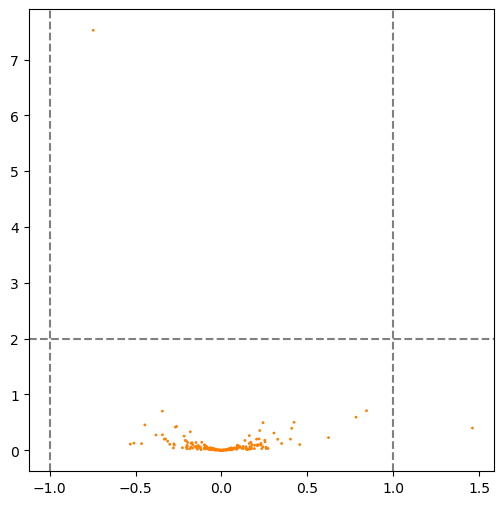

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(x=bcbcMPRAlm_table_control['logFC'],y=bcbcMPRAlm_table_control['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,color=bcbcMPRAlm_table_control['is_control'])

# plt.scatter(x=bcMPRAlm_table['logFC'],y=bcMPRAlm_table['adj.P.Val'].apply(lambda x:-np.log10(x)),s=1,color=bcMPRAlm_table['is_control'])
# ax = sns.scatterplot(data=bcMPRAlm_table, x="logFC", y="nlog10", hue="is_control")
# # y-axis label: -log10(adjusted_p-value)
# ax.set(xlabel="log2FC", ylabel="−log10(adjusted p-value)")
# highlight down- or up- regulated genes
# down = bcMPRAlm_table[(bcMPRAlm_table['logFC']<=-2)&(bcMPRAlm_table['adj.P.Val']<=0.01)]
# up = bcMPRAlm_table[(bcMPRAlm_table['logFC']>=2)&(bcMPRAlm_table['adj.P.Val']<=0.01)]



plt.axvline(1,color="grey",linestyle="--")
plt.axvline(-1,color="grey",linestyle="--")
plt.axhline(2,color="grey",linestyle="--")

# ax.axhline(2, zorder = 0, c='k', ls = '--')
# ax.axvline(1, zorder = 0, c='k', ls = '--')
# ax.axvline(-1, zorder = 0, c='k', ls = '--')

In [ ]:
### better control correlation using

In [ ]:
file_path = '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/05_variant_region_list/controll_header.tsv'
control_header = pd.read_csv(file_path, sep="\t")
control_header['label'] = control_header['header'].apply(get_label)

In [ ]:
def get_ratio(header):
    """'C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A::chr4:155359187-155359457-mean_ratio2.42' => 2.42"""
    return float(header.split('mean_ratio')[-1])

In [ ]:
log_ratio_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_merged.tsv.gz"
log_ratio = pd.read_csv(log_ratio_path, sep="\t")
log_ratio

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,352,882,0.124860,0.125379,1.044034,0.062169,106
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,340,1902,0.129131,0.289492,2.330882,1.220876,99
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,219,598,0.121094,0.132511,1.137747,0.186180,68
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,276,809,0.116602,0.136968,1.221316,0.288437,89
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,191,467,0.132993,0.130312,1.018761,0.026816,54
...,...,...,...,...,...,...,...,...,...,...
224008,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,968,0.104597,0.206934,2.073894,1.052342,75
224009,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,78,230,0.108453,0.141832,1.370895,0.455118,26
224010,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,69,100,0.086015,0.055287,0.673786,-0.569638,29
224011,NGN2,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,342,655,0.118881,0.100978,0.890402,-0.167471,104


In [ ]:
pos_neuro_cd

,header,label,given_ratio,name,ratio
0,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.750000
1,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,1.507842
2,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,2.42,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,1.782164
3,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,2.34,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,3.090278
4,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,2.34,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,2.095457
...,...,...,...,...,...
256,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,1.271118
257,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,1.439994
258,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,1.875000
259,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,1.83,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,0.465657


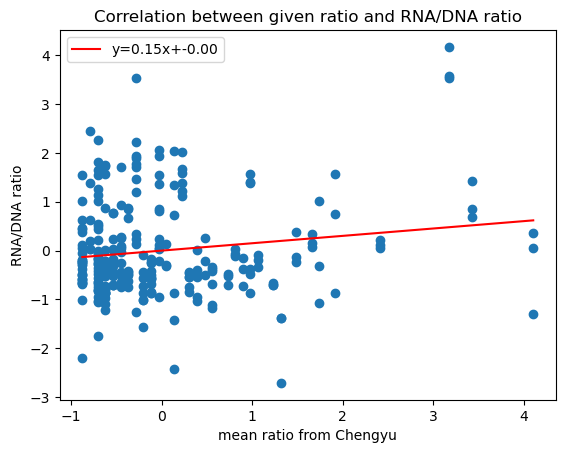

In [ ]:
# pos_neuro_cd = control_header[control_header['label'] == 'C_positive_neuron_CD']
# pos_neuro_cd['given_ratio'] = pos_neuro_cd['header'].apply(get_ratio)
# pos_neuro_cd = pos_neuro_cd.merge(log_ratio[['name', 'log2']], left_on="header", right_on="name", how='left')
# correlation plot between given ratio and log2 ratio
import matplotlib.pyplot as plt
plt.scatter(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2'])
plt.xlabel("mean ratio from Chengyu")
plt.ylabel("RNA/DNA ratio")
# fit line
import numpy as np
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2'])
line = slope*pos_neuro_cd['given_ratio']+intercept
plt.plot(pos_neuro_cd['given_ratio'], line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept))
plt.legend()
plt.title("Correlation between given ratio and RNA/DNA ratio")
plt.show()



In [ ]:
# median normalize the log2 column
log_ratio['log2'] = log_ratio['log2'] - log_ratio['log2'].median()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pos_neuro_cd['log2'] = scaler.fit_transform(pos_neuro_cd['log2'])

# StandardScaler().fit_transform(pos_neuro_cd[['given_ratio', '']])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
pos_neuro_cd

,header,label,given_ratio,name,log2
0,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,-1.287817
1,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.049655
2,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,C_positive_neuron_CD,4.101950,C_positive_neuron_CD:p1_rs6813360_A_C_ref_50_A...,0.369771
3,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,3.427285,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,1.423937
4,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,C_positive_neuron_CD,3.427285,C_positive_neuron_CD:p1_rs55985730_T_G_alt_50_...,0.679918
...,...,...,...,...,...
256,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,-0.277421
257,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:p2_rs9926320_G_A_ref_25_A...,-0.038520
258,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,0.467024
259,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,C_positive_neuron_CD,-0.873704,C_positive_neuron_CD:n1_rs7214382_G_C_alt_50::...,-2.200627


In [ ]:
print(stats.pearsonr(pos_neuro_cd['given_ratio'], pos_neuro_cd['log2']))

PearsonRResult(statistic=0.1510785243371385, pvalue=0.014562828313939583)


In [ ]:
bcMPRAlm_table

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,ID,nlog10,color,is_control
0,1.456812,1.860281,16.887425,2.660743e-54,1.103250e-49,111.530180,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E2358394|5-1440805...,48.957326,interesting_high_log2fc,#377eb8
1,1.606197,0.969005,12.616945,9.251426e-32,1.918006e-27,60.057828,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,ANKZF1|ENSG00000163516.14|EH38E2076021|2-21926...,26.717150,interesting_high_log2fc,#377eb8
2,1.531276,0.923153,12.197297,3.871885e-30,5.351462e-26,56.506252,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,TRIO|ENSG00000038382.23|EH38E3627037|5-1425991...,25.271528,interesting_high_log2fc,#377eb8
3,0.907774,0.994476,11.422970,2.968129e-28,3.076763e-24,53.219004,cardiac_neuro_cava_random:ATR|ENSG00000175054....,ATR|ENSG00000175054.16|EH38E3544406|3-14257809...,23.511906,interesting_low_pvalue,#377eb8
4,-1.406837,0.849172,-10.628519,8.330598e-24,6.908398e-20,42.509871,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,CYP2D6|ENSG00000100197.23|EH38E3484163|22-4211...,19.160623,interesting_high_log2fc,#377eb8
...,...,...,...,...,...,...,...,...,...,...,...
41459,0.001067,0.148021,0.013399,9.893122e-01,9.985585e-01,-6.737826,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,NRXN1|ENSG00000179915.25|EH38E1997228|2-503360...,0.000627,uninteresting_low_log2fc,#377eb8
41460,-0.000931,0.030328,-0.011657,9.907019e-01,9.986675e-01,-6.737838,cardiac_neuro_cava_random:PHACTR1|ENSG00000112...,PHACTR1|ENSG00000112137.19|EH38E2447179|6-1316...,0.000579,uninteresting_low_log2fc,#377eb8
41461,-0.000932,0.096385,-0.011486,9.908387e-01,9.986675e-01,-6.737840,cardiac_neuro_cava_random:FH|ENSG00000091483.8...,FH|ENSG00000091483.8|EH38E2877415|1-241542473-T-C,0.000579,uninteresting_low_log2fc,#377eb8
41462,-0.000303,0.242820,-0.003851,9.969282e-01,9.996025e-01,-6.737858,cardiac_neuro_cava_random:DAOA|ENSG00000182346...,DAOA|ENSG00000182346.22|EH38E3079721|13-105499...,0.000173,uninteresting_low_log2fc,#377eb8


In [ ]:
# investigate significant results
bcMPRAlm_table[bcMPRAlm_table['adj.P.Val'] < 0.05] # 390
bcMPRAlm_table[bcMPRAlm_table['logFC'] > 1.4].shape # 11

(11, 11)

Looking into the results of the experiment:
- standard vs lowConfig: 
- correlation of DNA and RNA counts per replicate: (problem with plotting in MPRAsnakeflow)
   - DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_DNA_pairwise_minThreshold.png`
   - Ratio: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_Ratio_pairwise_minThreshold.png`
   - RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_RNA_pairwise_minThreshold.png`
- barcode: assigned counts vs all counts: correlation among replicates and count per insert distribution 
   - assigned counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - assigned counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count: DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_DNA_perBarcode.png`
   - count: RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_standardConfig_RNA_perBarcode.png`
   - all counts DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_DNA_pairwise.png`
   - all counts RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_barcode_RNA_pairwise.png`
   - count distri DNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_RNA_perBarcode.png`
   - count distri RNA: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/statistic/barcode/counts/NGN2_standardConfig_DNA_perBarcode.png`


- correlation_lowconfig: `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/statistic/barcode/assigned_counts/assignmentFixDuplicates/NGN2_lowConfig_barcode_RNA_pairwise.png`
   - Check up with Martin (check the exact numbers (how many are significant, how many are over log2FC))

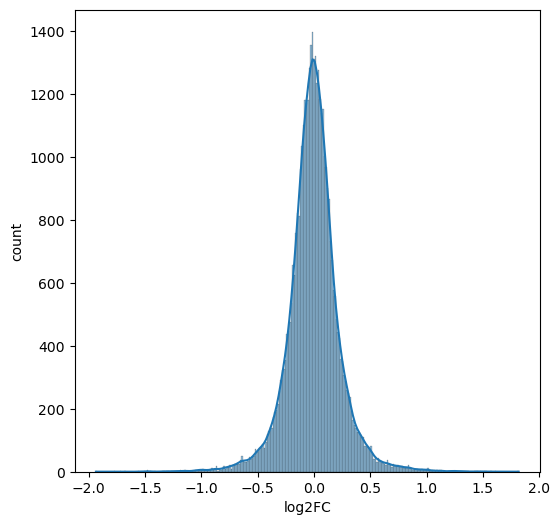

In [ ]:
## log2fc distribution of our variants
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=bcMPRAlm_table, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Investigate outliers (high log2FC) and not significant
- expectation: only a few barcodes

In [ ]:
# filter for high log2fc and not significant
non_sig_high_log2fc = bcMPRAlm_table[(abs(bcMPRAlm_table["logFC"]) >= 1) & (bcMPRAlm_table["adj.P.Val"] > 0.05)] # 1: 101; 0.5: 1524
len(non_sig_high_log2fc)

101

In [ ]:
# number of significant variants
sig_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < 0.05]
print(len(sig_variants)) # 398

low_log2fc = bcMPRAlm_table[abs(bcMPRAlm_table["logFC"]) < 0.5]
print(len(low_log2fc)) # 39468

398
39468


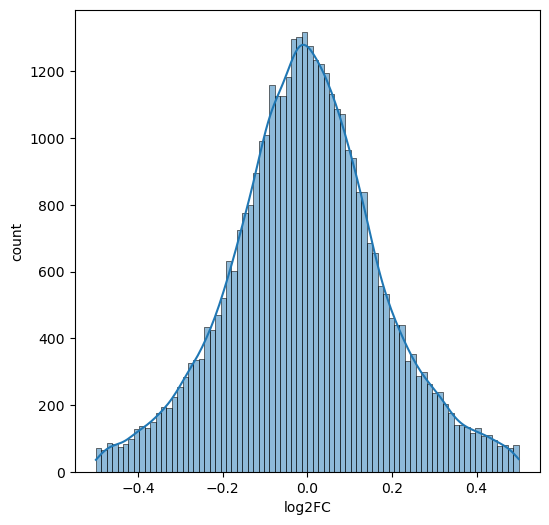

In [ ]:
## log2fc distribution
plt.figure(figsize=(6, 6))
ax = sns.histplot(data=low_log2fc, x="logFC", kde=True)
ax.set(xlabel="log2FC", ylabel="count")
plt.show()

### Connect MPRA results 
- Allel Frequency (AF), Allele Count (AC)
- enformer class (high_effect, low_effect, random) 
- Gene_set (neuro, cardiac, cava, random)

In [ ]:
# TODO: add connection between bc_MPRAlm_table and enformer tables
# bcMPRAlm_table
# match one enformer to the bcMPRAlm_table
# define a function for it
# does it for all enformer tables
enformer_cardiac_singleton = pd.read_csv(config["files"]["enformer_cardiac_single"], sep="\t")

In [ ]:
bcMPRAlm_table.variant_id.tolist()[:10]

['cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G',
 'cardiac_neuro_cava_random:ANKZF1|ENSG00000163516.14|EH38E2076021|2-219267001-T-C',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T',
 'cardiac_neuro_cava_random:ATR|ENSG00000175054.16|EH38E3544406|3-142578095-C-G',
 'cardiac_neuro_cava_random:CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115774-T-C',
 'cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G',
 'cardiac_neuro_cava_random:SLC1A2|ENSG00000110436.13|EH38E1532674|11-35289966-C-T',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408083-G-T',
 'cardiac_neuro_cava_random:H1-3|ENSG00000124575.7|EH38E3697725|6-26269112-G-T',
 'cardiac_neuro_cava_random:DISC1|ENSG00000162946.23|EH38E2873486|1-231734633-A-G']

In [ ]:
enformer_cardiac_singleton.head()

,#CHROM,POS,ID,REF,ALT,DNase_max,INDEX_max,QUAL,FILTER,INFO,gene_set,variant_type,enformer_class
0,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,4254.3410,392_DNASE:CD14-positive,1,PASS,AF=6.57168e-06;AC=1,cardiac,singleton,enformer_high
1,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,4022.5996,"177_DNASE:CD8-positive,",1,PASS,AF=6.56866e-06;AC=1,cardiac,singleton,enformer_high
2,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,3591.8310,392_DNASE:CD14-positive,1,PASS,AF=6.57618e-06;AC=1,cardiac,singleton,enformer_high
3,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,2754.7705,401_DNASE:common myeloid,1,PASS,AF=6.56763e-06;AC=1,cardiac,singleton,enformer_high
4,chr7,151848098,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,2746.3271,392_DNASE:CD14-positive,1,PASS,AF=6.56978e-06;AC=1,cardiac,singleton,enformer_high


### Positive and Negative numbers
- Overall: 
    - standard: 41284
    - lowConfig: 42137
- Number of significant results
    - standard: 398 
    - lowConfig: 53 
    - TODO: Why do I only find 53 with p-value < 0.05?
- Plot of log2FC distribution
- Plot p-value distribution
- Table of positive and negative log2FC
- Plot of p-value distribution (adjusted p value)

In [ ]:
def plot_distribution(df, value_column, n_bins=100, output_path="", title="", x_lable=None, y_lable=None):
    """Plot the distribution of the given column and store the plot in given directory"""
    plt.hist(df[value_column], bins=n_bins)
    if title != "":
        plt.title(title)
    if x_lable:
        plt.xlabel(xlabel=x_lable)
    if y_lable:
        plt.ylabel(ylabel=y_lable)
    if output_path != "":
        plt.savefig(config["plots"]["log2_p_sig_hist"])
    plt.show()
    plt.clf()

398 significant variants


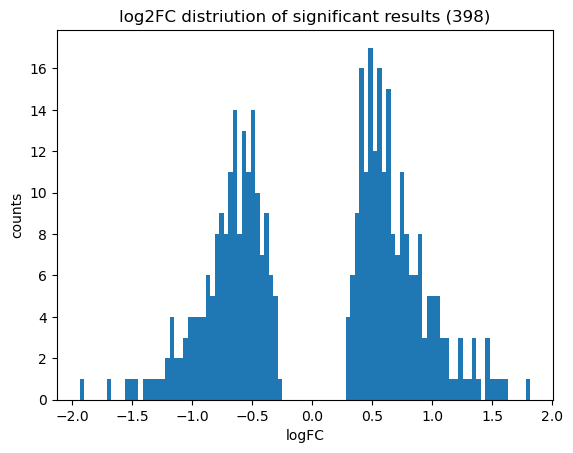

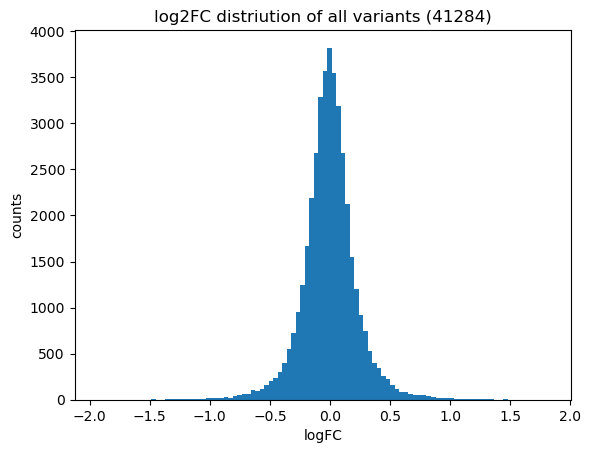

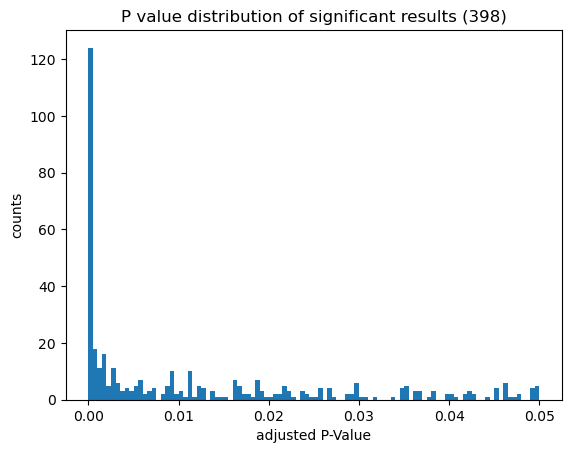

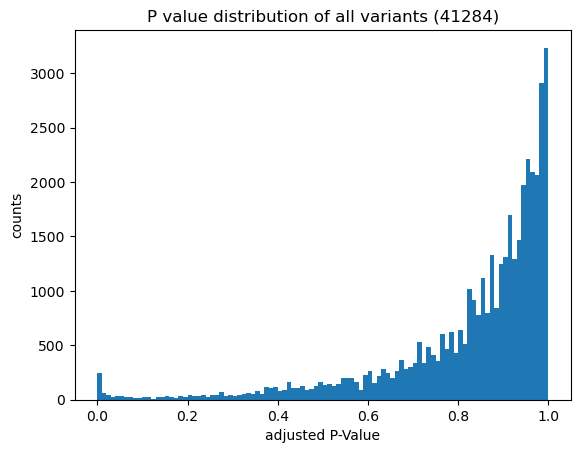

<Figure size 640x480 with 0 Axes>

In [ ]:
sig_niveau = 0.05
significant_variants = bcMPRAlm_table[bcMPRAlm_table["adj.P.Val"] < sig_niveau]
print("%s significant variants"%(significant_variants.shape[0]))

# plot log2FC distribution
title = "log2FC distriution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_p_sig_hist"], title=title, x_lable="logFC", y_lable="counts")
title = "log2FC distriution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="logFC", n_bins=100, output_path=config["plots"]["log2_all_hist"], title=title, x_lable="logFC", y_lable="counts")

# P value distribution
title = "P value distribution of significant results (%s)"%(significant_variants.shape[0])
plot_distribution(df=significant_variants, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["sig_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")
title = "P value distribution of all variants (%s)"%(bcMPRAlm_table.shape[0])
plot_distribution(df=bcMPRAlm_table, value_column="adj.P.Val", n_bins=100, output_path=config["plots"]["all_adj_p_hist"], title=title, x_lable="adjusted P-Value", y_lable="counts")



### Positive and negative effects
- In all variants
  - Found 20113 (0.487) positive results
  - Found 21171 (0.513) negative results
- Significant (reverse pattern => more positive than negative)
  - Found 214 (0.538) positive results
  - Found 184 (0.462) negative results

In [ ]:
# number of positive negative numbers
def split_into_common_rare(df_with_AF_column,  common_threshold=0.05, column="AF"):
    """Splits df into rare and common at threshold"""
    common_vars = df_with_AF_column[df_with_AF_column[column] >= common_threshold]
    rare_vars = df_with_AF_column[df_with_AF_column[column] < common_threshold]
    print(f"Found {len(common_vars)} ({len(common_vars)/len(df_with_AF_column)}) common variants and {len(rare_vars)} ({len(rare_vars)/len(df_with_AF_column)}) rare variants with the common threshold {common_threshold}")
    ultra_rare = df_with_AF_column[df_with_AF_column[column] < 0.01]
    ultra_rare = ultra_rare[ultra_rare["AC"] != 1]
    print(f"Found {len(ultra_rare)} ultra-rare variants")
    print(f"Found {len(df_with_AF_column[df_with_AF_column['AC'] == 1])} singleton variants")
    return common_vars, rare_vars

def split_df_in_pos_neg(df_with_logFC_column, column="logFC", rounding_precision=3):
    """Splits a given data frame based on the logFC into positive and negative values"""
    positive_set = df_with_logFC_column[df_with_logFC_column[column] > 0]
    negative_set = df_with_logFC_column[df_with_logFC_column[column] < 0]
    print(f"Found {len(positive_set)} ({round(len(positive_set)/len(df_with_logFC_column),rounding_precision)}) positive results\nFound {len(negative_set)} ({round(len(negative_set)/len(df_with_logFC_column), rounding_precision)}) negative results")
    return positive_set, negative_set

In [ ]:
print("In all variants")
bcMPRAlm_table_positive, bcMPRAlm_table_negative = split_df_in_pos_neg(bcMPRAlm_table)
print("Significant")
sig_positive, sig_negative = split_df_in_pos_neg(significant_variants)

In all variants
Found 20113 (0.487) positive results
Found 21171 (0.513) negative results
Significant
Found 214 (0.538) positive results
Found 184 (0.462) negative results


### Allele frequency (common: AF>1%, rare: AF=<1%, singleton: AC=0)

In [ ]:
# common rare